In [1]:
import numpy as np
from scipy.optimize import brentq, minimize_scalar
import matplotlib.pyplot as plt
from astropy import constants as const
from astropy import units as u
import os
import sys
import astropy.io.fits as fits
from datetime import datetime
import pandas as pd
import matplotlib as mpl
from matplotlib.font_manager import FontProperties
import matplotlib.ticker as ticker
from src.utils.calculations_v3 import *
from src.utils.plotting_utils import *
import seaborn as sns
from scipy.stats import gaussian_kde
import pandas as pd
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap, Normalize
from matplotlib.cm import ScalarMappable
plt.rcParams['text.usetex'] = True
plt.rcParams.update({'font.family': 'serif', 'font.size': 12, 'axes.labelsize': 12, 'axes.titlesize': 12,
                     'legend.fontsize': 9, 'xtick.labelsize': 10, 'ytick.labelsize': 10})
# plt.rcParams["axes.formatter.use_mathtext"]
c = datetime.now()
# Displays Time
current_time = c.strftime('%H%M')
print("current time :", current_time)
path = '/data/a.saricaoglu/repo/captus'

# # Import COMPAS specific scripts
compasRootDir = os.environ['COMPAS_ROOT_DIR']
sys.path.append(compasRootDir + '/postProcessing/PythonScripts')
print(sys.path)

pathToData = '/data/a.saricaoglu/repo/COMPAS/Files/bhvscomp.fits'


current time : 1441
['/grad/a.saricaoglu/.conda/envs/captus/lib/python312.zip', '/grad/a.saricaoglu/.conda/envs/captus/lib/python3.12', '/grad/a.saricaoglu/.conda/envs/captus/lib/python3.12/lib-dynload', '', '/grad/a.saricaoglu/.conda/envs/captus/lib/python3.12/site-packages', '/data/a.saricaoglu/repo/captus', '/data/a.saricaoglu/repo/luxetenebrae/COMPAS/postProcessing/PythonScripts']


In [2]:
print(const.c)

  Name   = Speed of light in vacuum
  Value  = 299792458.0
  Uncertainty  = 0.0
  Unit  = m / s
  Reference = CODATA 2018


In [2]:
limit_in_m = 1e7 * u.au.to(u.m)
print(f'Limit in meters: {limit_in_m}')

Limit in meters: 1.495978707e+18


## Functions

In [36]:
mu = (m_pbh_values[-1] * M_star) / (m_pbh_values[-1] + M_star)
print(f"Reduced mass (mu): {mu:.3e} kg")
print(m_pbh_values[-1] )

Reduced mass (mu): 2.442e+30 kg
1.988409870698051e+31


### FINALIZED 

In [3]:

def galactic_dm_maxwell_dist(v, r=8):
    if v <= 550:
        f_vinf = v_pbh_pdf(v, r=r)
        return f_vinf.value

    else:
        f_vinf = 0
        return f_vinf
    
def neq_r_f(Mpbh, Neq, ri=None, rf=8):
    n = get_Neq_at_r_f(Mpbh, Neq, ri=ri, rf=rf, num_points=1)
    return n

def coalescence_time_v3(b, M_pbh, M_star, a, e): # Maggiore 2007
    omega_0 = np.sqrt(G * (M_pbh + M_star) / a**3)
    T0 = 2 * np.pi / omega_0
    mu = (M_pbh * M_star) / (M_pbh + M_star)
    tau0 = (5/256) * (const.c.value**5 * a**4) / (G**3 * mu *(M_pbh + M_star)**2)
    # R0 = b * np.sqrt(-(e**2 - 1))
    # T0 = R0 * (2*np.pi)/np.sqrt(G*(M_pbh + M_star))
    F = (768/425) * (1-e**2)**(7/2)
    # return ((9.829)*u.Myr).to(u.s).value * ((T0/3600)**(8/3)) * ((const.M_sun.value/(M_pbh + M_star))**2/3) * (const.M_sun.value/mu) * F
    return tau0 * F

def coalescence_time_v4(a0, e0, M_pbh, M_star): #Peters 1964

    beta = (64/5) * (G**3 * M_pbh * M_star * (M_pbh + M_star)) / (const.c.value**5)
    Tc = a0**4 / (4 * beta)
    T = (768/425) * Tc * (1-e0**2)**(7/2)
    # T = (768/425) * (np.pi/v_inf**3) * (M_pbh + M_star) * np.sqrt((b/limit_in_m)**21 / (1 - (b/limit_in_m)**7))
    return T

def coalescence_time_v5(v_inf, b, M_pbh, M_star, R_star, E, a0, e0): #Caiozzo et al. 2024

    v_star = np.sqrt(G * M_star / R_star) / const.c.value
    v_inf = v_inf / const.c.value
    T_decay = 3.53 * 10**(-2) * (v_inf * b)**7 * const.c.value**5 / np.sqrt(G**5 * M_pbh * M_star**3 * R_star**7 *v_star**14 * (-2*E))
    # T_decay = (3/85) * (v_inf * b)**7 * const.c.value**5  / np.sqrt(G**12 * M_pbh * M_star**10  * (-2*E))
    # F = (768/425) * (1-e0**2)**(7/2)
    # T_decay = (const.c.value**5/G**6) * (15/(304 * M_pbh * M_star**2)) * ((a0 * (1-e0**2))/1.135)**4 * F
    return T_decay

def coalescence_time_v6(v_inf, b, b_max, M_pbh, M_star): #Radial 2025
    # b_prop = b/b_max
    # # M_pbh = M_pbh * G / const.c.value**2
    # # M_star = M_star * G / const.c.value**2
    Msun = const.M_sun.value 
    # # v_inf = v_inf / const.c.value
    # mu = (M_pbh * M_star) / (M_pbh + M_star)
    # nu = mu / (M_pbh + M_star)
    # b_max = (19*np.pi*(nu)/3)**(1/7) * (G * (M_pbh + M_star)/v_inf**2) * (const.c.value/v_inf)**(5/7) # * const.G.value**(2/7) * const.c.value**(-5/7)
    # b = b_prop * b_max
    T = (1.08*u.day).to(u.s).value * ((M_pbh + M_star)/Msun) * ((v_inf/1e5)**-3) * np.sqrt((b/b_max)**21 / (1 - (b/b_max)**7))
    M_total = M_pbh + M_star
    # return (19*np.pi/85) * (G * M_total) / (v_inf**3) * \
    #        np.sqrt((b/b_max)**21 / (1 - (b/b_max)**7))
    return T

def coalescence_time_v7(v_inf, b, b_max, M_pbh, M_star, R_star): #Genolini 2020
    v_star = np.sqrt(G * M_star / R_star)
    v_star_in_lightspeed = v_star / const.c.value
    bc = R_star * np.sqrt(1 + (2  * v_star**2/v_inf**2))
    T =  16 *(M_pbh/1e19)**(-3/2) * (b/bc)**(21/2) * (v_star_in_lightspeed/0.44)**(-19) * (u.Myr).to(u.s)
    return T

def orbital_energy(M_pbh, M_star, v_inf, b, e):
    mu = (M_pbh * M_star) / (M_pbh + M_star)

    L, r = orbital_momentum(e, mu, b, v_inf)

    KE = 0.5 * mu * v_inf**2
    LE = 0.5 * (L**2) / (mu * r**2)
    PE = - G * mu * (M_star + M_pbh) / r
    return KE + PE + LE

def orbital_momentum(e, mu, b, v_inf):
    phi = np.arccos(-1/e)
    R = b * np.sqrt((e**2 - 1))
    # print('R:', R)
    r = R / (1 + e * np.cos(phi))
    if r == np.inf:
        return 0, r
    L = mu * b * v_inf
    print('L:', L, 'r:', r)
    return L, r

def r_minimum(M_star, M_pbh, v_inf, e):
    return G * (M_star + M_pbh) * (e-1) / (v_inf**2)

def b_minimum(M_star, M_pbh, R_star, v_inf):
    return np.sqrt(R_star**2 + (2 * G *(M_star + M_pbh) * R_star) / v_inf**2)

def p_e(e):
    return ((e + 1)**-3.5) * ((np.arccos(-1/e) * (24 + 73*e**2 + ((37/4)*e**4))) + (602 + 673*e**2) * np.sqrt(e**2 - 1)/12)

# def eccentricity(b, M_pbh, M_star, v_inf):
#     return 1 + 1e-9 * (b/(1e5))**2 * (v_inf/(2.2e5))**4 * (M_star/const.M_sun.value)**-2

def eccentricity_original(b, M_pbh, M_star, v_inf): # Hyperbolic orbit eccentricity pre GW emission
    return np.sqrt(1 + (b**2 * v_inf**4) / (G**2 * (M_star + M_pbh)**2))

def eccentricity_v2(E, L, M_pbh, M_star): # Bound orbit eccentricity post capture
    mu = (M_pbh * M_star) / (M_pbh + M_star)
    GM = G * (M_pbh + M_star)
    val = 1.0 + (2.0 * E * L**2) / (mu**3 * GM**2)
    # numerical safety
    return np.sqrt(np.clip(val, 0.0, None))

def delta_E_GW(e, b, M_pbh, M_star, v_inf):

    pre_factor = ((8/15)  * (M_pbh**2 * M_star**2)) / ((M_star+ M_pbh)**3 * const.c.value**5)
    # print('pre factor:', pre_factor)
    return pre_factor * (p_e(e) / (e - 1)**3.5) * v_inf**7

def equation(b, M_pbh, M_star, v_inf):
    # Returns positive when GW loss < KE (no capture)
    # Returns negative when GW loss > KE (capture possible)
    e = eccentricity_original(b, M_pbh, M_star, v_inf) 
    # return -delta_E_GW(e, b, M_pbh, M_star, v_inf) + orbital_energy(M_pbh, M_star, v_inf, b, e)
    # E_initial = 0.5 * (M_pbh * M_star) / (M_pbh + M_star) * v_inf**2
    mu = (M_pbh * M_star) / (M_pbh + M_star)
    E_initial = 0.5 * mu * v_inf**2
    return -delta_E_GW(e, b, M_pbh, M_star, v_inf) + orbital_energy(M_pbh, M_star, v_inf, b, e)

def compute_b_max(M_pbh, M_star, v_inf, b_min):
    """
    Find maximum b where |GW energy loss| ≥ kinetic energy
    
    At b_min: GW loss is very large (close encounter) → equation < 0
    As b increases: GW loss decreases → equation approaches 0 then becomes positive
    
    We want the b where equation = 0 (transition point)
    """
    e = eccentricity_original(b_min, M_pbh, M_star, v_inf)
    # Check if capture is possible at b_min
    eq_at_bmin = equation(b_min, M_pbh, M_star, v_inf)
    
    if eq_at_bmin > 0:
        # Even at closest approach, GW loss < KE → no capture possible
        return b_min
    
    # Find where equation crosses zero (GW loss = KE)
    b_guess_max = b_min  # Start with 10x b_min
    
    # Expand search until we bracket the root
    while b_guess_max < limit_in_m:
        eq_at_bmax = equation(b_guess_max, M_pbh, M_star, v_inf)
        # print(f'bmax guess: {b_guess_max}, equation: {eq_at_bmax}')
        if eq_at_bmax >= 0:
            # Found sign change! equation(b_min) < 0, equation(b_max) > 0
            try:
                b_max = brentq(equation, b_min, b_guess_max,
                              args=(M_pbh, M_star, v_inf),
                              xtol=1e-5, rtol=1e-5)
                # print(f'bmax found: {b_max}')
                return b_max
            except ValueError:
                return 0
        
        # Still negative - need larger b
        b_guess_max += b_min/100
        

    
    return 0

def compute_capture_crossec(b_min, b_max):
    if b_max <= b_min:
        return 0
    else:
        return np.pi * (b_max**2 - b_min**2)
    
def compute_semimajor_axis(b_ave, M_pbh, M_star, v_inf):
    E = equation(b_ave, M_pbh, M_star, v_inf)  # this must be the *post-loss* orbital energy
    mu = (M_pbh * M_star) / (M_pbh + M_star)

    if not np.isfinite(E) or E >= 0:   # not bound
        return np.nan, np.nan

    a = -G * (M_pbh + M_star) * mu / (2.0 * E)

    # your choice of angular momentum model:
    L = mu * b_ave * v_inf
    e = eccentricity_v2(E, L, M_pbh, M_star)

    return a, e

def orbital_period(m1, m2, semimajax):
    # G =  39.4769264 # gravitational constant in AU^3 / (year^2 x Msun) 
    # M = (np.asarray(m1) + np.asarray(m2))
    # A = np.asarray(semimajax)
    # orbitalPeriod = (np.sqrt((4 * np.pi**2 * A**3)) / np.sqrt(G * M)) * 365.25
    G = const.G # units of m^3 kg^-1 s^-2
    # m1 = m1 * const.M_sun # units of kg
    m1 = m1*(u.kg)
    # m2 = m2 * const.M_sun # units of kg
    m2 = m2*(u.kg)
    A = semimajax * u.au # units of m
    A = A.to(u.m)
    orbitalPeriod = (np.sqrt((4 * np.pi**2 * A**3)) / np.sqrt(G * (m1 + m2))) # units of s
    orbitalPeriod = orbitalPeriod.to(u.yr).value
    # print('max orbital period in hours:', np.max(orbitalPeriod))
    # orbitalPeriod = orbitalPeriod / 24 # units of days
    # print('max orbital period in days:', np.max(orbitalPeriod))

    return orbitalPeriod


In [ ]:
# # LEGACY 3/21
# # print(R_star)
# # print(R_star.to(u.au))
# def galactic_dm_maxwell_dist(v, v_disp=220e3, vesc=550e3):
#     f_vinf = (np.sqrt(2/np.pi)) * (v**2 / (v_disp**3)) * np.exp(- (v)**2/(2*v_disp**2)) * np.heaviside(vesc-v, 0)
#     return f_vinf

# # def coalescence_time(b, M_pbh, M_star, v_inf):
# #     # omega_0 = np.sqrt(G * (M_pbh + M_star) / a**3)
# #     # T_0 = 2 * np.pi / omega_0
# #     e = eccentricity_original(b, M_pbh, M_star, v_inf)
# #     mu = (M_pbh * M_star) / (M_pbh + M_star)
# #     R0 = b * np.sqrt((e**2 - 1))
# #     return (5/256) * (const.c.value**5 * R0**4) / (G**3 * mu *(M_pbh + M_star)**2)

# # def coalescence_time_v2(b, bmax, M_pbh, M_star, v_inf):
# #     mu = (M_pbh * M_star) / (M_pbh + M_star)
# #     return (19/85) * (np.pi/v_inf**3) * (M_pbh + M_star) * np.sqrt((b/bmax)**21 / (1 - (b/bmax)**7))

# def coalescence_time_v3(b, M_pbh, M_star, a, e): # Maggiore 2007
#     omega_0 = np.sqrt(G * (M_pbh + M_star) / a**3)
#     T0 = 2 * np.pi / omega_0
#     mu = (M_pbh * M_star) / (M_pbh + M_star)
#     tau0 = (5/256) * (const.c.value**5 * a**4) / (G**3 * mu *(M_pbh + M_star)**2)
#     # R0 = b * np.sqrt(-(e**2 - 1))
#     # T0 = R0 * (2*np.pi)/np.sqrt(G*(M_pbh + M_star))
#     F = (768/425) * (1-e**2)**(7/2)
#     # return ((9.829)*u.Myr).to(u.s).value * ((T0/3600)**(8/3)) * ((const.M_sun.value/(M_pbh + M_star))**2/3) * (const.M_sun.value/mu) * F
#     return tau0 * F

# def coalescence_time_v4(a0, e0, M_pbh, M_star): #Peters 1964

#     beta = (64/5) * (G**3 * M_pbh * M_star * (M_pbh + M_star)) / (const.c.value**5)
#     Tc = a0**4 / (4 * beta)
#     T = (768/425) * Tc * (1-e0**2)**(7/2)
#     # T = (768/425) * (np.pi/v_inf**3) * (M_pbh + M_star) * np.sqrt((b/limit_in_m)**21 / (1 - (b/limit_in_m)**7))
#     return T

# def coalescence_time_v5(v_inf, b, M_pbh, M_star, R_star, E, a0, e0): #Caiozzo et al. 2024

#     v_star = np.sqrt(G * M_star / R_star) / const.c.value
#     v_inf = v_inf / const.c.value
#     T_decay = 3.53 * 10**(-2) * (v_inf * b)**7 * const.c.value**5 / np.sqrt(G**5 * M_pbh * M_star**3 * R_star**7 *v_star**14 * (-2*E))
#     # T_decay = (3/85) * (v_inf * b)**7 * const.c.value**5  / np.sqrt(G**12 * M_pbh * M_star**10  * (-2*E))
#     # F = (768/425) * (1-e0**2)**(7/2)
#     # T_decay = (const.c.value**5/G**6) * (15/(304 * M_pbh * M_star**2)) * ((a0 * (1-e0**2))/1.135)**4 * F
#     return T_decay

# def coalescence_time_v6(v_inf, b, b_max, M_pbh, M_star): #Radial 2025
#     M_pbh = M_pbh * G / const.c.value**2
#     M_star = M_star * G / const.c.value**2
#     v_inf = v_inf / const.c.value
#     mu = (M_pbh * M_star) / (M_pbh + M_star)
#     nu = mu / (M_pbh + M_star)
#     b_max = (19*np.pi*(nu)/3)**(1/7) * (M_pbh + M_star) * v_inf**(-9/7) # * const.G.value**(2/7) * const.c.value**(-5/7)
#     T = (1*u.day).to(u.s).value * (M_pbh + M_star)/const.M_sun.value * ((v_inf/1e5)**-3) * np.sqrt((b/b_max)**21 / (1 - (b/b_max)**7))
#     return T

# def coalescence_time_v7(v_inf, b, b_max, M_pbh, M_star, R_star): #Genolini 2020
#     v_star = np.sqrt(G * M_star / R_star)
#     v_star_in_lightspeed = v_star / const.c.value
#     bc = R_star * np.sqrt(1 + (2  * v_star**2/v_inf**2))
#     T =  16 *(M_pbh/1e19)**(-3/2) * (b/bc)**(21/2) * (v_star_in_lightspeed/0.44)**(-19) * (u.Myr).to(u.s)
#     return T

# def orbital_energy(M_pbh, M_star, v_inf, b, e):
#     mu = (M_pbh * M_star) / (M_pbh + M_star)

#     L, r = orbital_momentum(M_pbh, M_star, e, mu, b)

#     KE = 0.5 * mu * v_inf**2
#     LE = 0.5 * (L**2) / (mu * r**2)
#     PE = - G * mu * (M_star + M_pbh) / r
#     return KE + PE + LE
# # def orbital_energy(M_pbh, M_star, v_inf, b, e):
# #     mu = (M_pbh * M_star) / (M_pbh + M_star)
# #     R = b * np.sqrt(-(e**2 - 1))
# #     r = R / (1 + e * np.cos(phi))
# #     L = orbital_momentum(M_pbh, M_star, e, r)
# #     KE = 0.5 * mu * v_inf**2
# #     LE = 0.5 * (L**2) / (mu * r**2)
# #     PE = - G * mu * (M_star + M_pbh) / r
# #     return KE 

# def orbital_momentum(M_pbh, M_star, e, mu, b):
#     phi = np.arccos(-1/e)
#     R = b * np.sqrt((e**2 - 1))
#     # print('R:', R)
#     r = R / (1 + e * np.cos(phi))
#     psi = np.sqrt(G*(M_star + M_pbh) * R) / r**2
#     if r == np.inf:
#         return 0, r
#     L = mu * r**2 * psi
#     print('L:', L, 'r:', r)
#     return L, r

# def r_minimum(M_star, M_pbh, v_inf, e):
#     return G * (M_star + M_pbh) * (e-1) / (v_inf**2)

# def b_minimum(M_star, M_pbh, R_star, v_inf):
#     return np.sqrt(R_star**2 + (2 * G *(M_star + M_pbh) * R_star) / v_inf**2)

# def p_e(e):
#     return ((e + 1)**-3.5) * ((np.arccos(-1/e) * (24 + 73*e**2 + ((37/4)*e**4))) + (602 + 673*e**2) * np.sqrt(e**2 - 1)/12)

# def eccentricity(b, M_pbh, M_star, v_inf):
#     return 1 + 1e-9 * (b/(1e5))**2 * (v_inf/(2.2e5))**4 * (M_star/const.M_sun.value)**-2

# def eccentricity_original(b, M_pbh, M_star, v_inf):
#     return np.sqrt(1 + (b**2 * v_inf**4) / (G**2 * (M_star + M_pbh)**2))

# def eccentricity_v2(E, L, M_pbh, M_star):
#     mu = (M_pbh * M_star) / (M_pbh + M_star)
#     GM = G * (M_pbh + M_star)
#     val = 1.0 + (2.0 * E * L**2) / (mu**3 * GM**2)
#     # numerical safety
#     return np.sqrt(np.clip(val, 0.0, None))
# # def delta_E_GW(b, M_pbh, M_star, v_inf):
# #     e = eccentricity_original(b, M_pbh, M_star, v_inf)
    
# #     pre_factor = (8/15) * (M_pbh**2 * M_star**2) / (M_pbh + M_star)**3
# #     print('pre factor:', pre_factor)
# #     return pre_factor * (p_e(e) / ((e - 1)**3.5)) * v_inf**7
# def delta_E_GW(e, b, M_pbh, M_star, v_inf):

#     pre_factor = ((8/15)  * (M_pbh**2 * M_star**2)) / ((M_star+ M_pbh)**3 * const.c.value**5)
#     # print('pre factor:', pre_factor)
#     return pre_factor * (p_e(e) / (e - 1)**3.5) * v_inf**7

# def equation(b, M_pbh, M_star, v_inf):
#     # Returns positive when GW loss < KE (no capture)
#     # Returns negative when GW loss > KE (capture possible)
#     e = eccentricity(b, M_pbh, M_star, v_inf)
#     return -delta_E_GW(e, b, M_pbh, M_star, v_inf) + orbital_energy(M_pbh, M_star, v_inf, b, e)

# def compute_b_max(M_pbh, M_star, v_inf, b_min):
#     """
#     Find maximum b where |GW energy loss| ≥ kinetic energy
    
#     At b_min: GW loss is very large (close encounter) → equation < 0
#     As b increases: GW loss decreases → equation approaches 0 then becomes positive
    
#     We want the b where equation = 0 (transition point)
#     """
#     e = eccentricity(b_min, M_pbh, M_star, v_inf)
#     # Check if capture is possible at b_min
#     eq_at_bmin = equation(b_min, M_pbh, M_star, v_inf)
    
#     if eq_at_bmin > 0:
#         # Even at closest approach, GW loss < KE → no capture possible
#         return b_min
    
#     # Find where equation crosses zero (GW loss = KE)
#     b_guess_max = b_min  # Start with 10x b_min
    
#     # Expand search until we bracket the root
#     while b_guess_max < limit_in_m:
#         eq_at_bmax = equation(b_guess_max, M_pbh, M_star, v_inf)
#         # print(f'bmax guess: {b_guess_max}, equation: {eq_at_bmax}')
#         if eq_at_bmax >= 0:
#             # Found sign change! equation(b_min) < 0, equation(b_max) > 0
#             try:
#                 b_max = brentq(equation, b_min, b_guess_max,
#                               args=(M_pbh, M_star, v_inf),
#                               xtol=1e-5, rtol=1e-5)
#                 # print(f'bmax found: {b_max}')
#                 return b_max
#             except ValueError:
#                 return 0
        
#         # Still negative - need larger b
#         b_guess_max *= 1.1
        

    
#     return 0

# def compute_capture_crossec(b_min, b_max):
#     if b_max <= b_min:
#         return 0
#     else:
#         return np.pi * (b_max**2 - b_min**2)
    
# # def compute_semimajor_axis(b_ave, M_pbh, M_star, v_inf):

# #     fe = equation(b_ave, M_pbh, M_star, v_inf)
# #     mu = (M_pbh * M_star) / (M_pbh + M_star)
# #     e = eccentricity(b_ave, M_pbh, M_star, v_inf)
# #     a = G * (M_star + M_pbh) * mu  / (2 * (fe))
# #     # r = -a*(1-e**2)/(1 + e * np.cos(phi))
# #     # L = orbital_momentum(M_pbh, M_star, e, r)


# #     # LE = 0.5 * (L**2) / (mu * r**2)
# #     # PE = - G * mu * (M_star + M_pbh) / r
# #     # KE = fe - PE - LE
# #     v2 = np.sqrt(2*np.abs(fe)/mu)
# #     # L = mu * b_ave * v2
# #     rmin = r_minimum(M_star, M_pbh, v_inf, e)
# #     L = mu * b_ave * v_inf # Radial 2025 eq 16.86
# #     # L = np.sqrt(G * (M_star + M_pbh) * (a) * (1 - e**2)) * mu
# #     if fe < 0:
# #         print(f" a {a} , e {e} , fe {fe} v2 {v2} L {L}")
# #      # Calculate the semimajor axis using the formula
# #     e = eccentricity_v2(fe, L, M_pbh, M_star)
# #     return -a, e
# def compute_semimajor_axis(b_ave, M_pbh, M_star, v_inf):
#     E = equation(b_ave, M_pbh, M_star, v_inf)  # this must be the *post-loss* orbital energy
#     mu = (M_pbh * M_star) / (M_pbh + M_star)

#     if not np.isfinite(E) or E >= 0:   # not bound
#         return np.nan, np.nan

#     a = -G * (M_pbh + M_star) * mu / (2.0 * E)

#     # your choice of angular momentum model:
#     L = mu * b_ave * v_inf
#     e = eccentricity_v2(E, L, M_pbh, M_star)

#     return a, e

# def orbital_period(m1, m2, semimajax):
#     # G =  39.4769264 # gravitational constant in AU^3 / (year^2 x Msun) 
#     # M = (np.asarray(m1) + np.asarray(m2))
#     # A = np.asarray(semimajax)
#     # orbitalPeriod = (np.sqrt((4 * np.pi**2 * A**3)) / np.sqrt(G * M)) * 365.25
#     G = const.G # units of m^3 kg^-1 s^-2
#     # m1 = m1 * const.M_sun # units of kg
#     m1 = m1*(u.kg)
#     # m2 = m2 * const.M_sun # units of kg
#     m2 = m2*(u.kg)
#     A = semimajax * u.au # units of m
#     A = A.to(u.m)
#     orbitalPeriod = (np.sqrt((4 * np.pi**2 * A**3)) / np.sqrt(G * (m1 + m2))) # units of s
#     orbitalPeriod = orbitalPeriod.to(u.yr).value
#     # print('max orbital period in hours:', np.max(orbitalPeriod))
#     # orbitalPeriod = orbitalPeriod / 24 # units of days
#     # print('max orbital period in days:', np.max(orbitalPeriod))

#     return orbitalPeriod


In [ ]:
# LEGACY
# # print(R_star)
# # print(R_star.to(u.au))
# def galactic_dm_maxwell_dist(v, v_disp=220e3):
#     f_vinf = (np.sqrt(2/np.pi)) * (v**2 / (v_disp**3)) * np.exp(- (v)**2/(2*v_disp**2))
#     return f_vinf
# def orbital_energy(M_pbh, M_star, v_inf, b):
#     mu = (M_pbh * M_star) / (M_pbh + M_star)
#     KE = 0.5 * M_pbh * v_inf**2
#     PE = - G * mu * (M_star + M_pbh) / (2*b)
#     return KE 

# def b_minimum(M_star, M_pbh, R_star, v_inf):
#     return np.sqrt(R_star**2 + (2 * G *(M_star) * R_star) / v_inf**2)

# def p_e(e):
#     return ((e + 1)**-3.5) * ((np.arccos(-1/e) * (24 + 73*e**2 + ((37/4)*e**4))) + (602 + 673*e**2) * np.sqrt(e**2 - 1)/12)

# def eccentricity(b, M_pbh, M_star, v_inf):
#     return 1 + 1e-9 * (b/(1e5))**2 * (v_inf/(2.2e5))**4 * (M_star/const.M_sun.value)**-2

# def eccentricity_original(b, M_pbh, M_star, v_inf):
#     return np.sqrt(1 + (b**2 * v_inf**4) / (G**2 * (M_star)**2))

# # def delta_E_GW(b, M_pbh, M_star, v_inf):
# #     e = eccentricity_original(b, M_pbh, M_star, v_inf)
    
# #     pre_factor = (8/15) * (M_pbh**2 * M_star**2) / (M_pbh + M_star)**3
# #     print('pre factor:', pre_factor)
# #     return pre_factor * (p_e(e) / ((e - 1)**3.5)) * v_inf**7
# def delta_E_GW(b, M_pbh, M_star, v_inf):
#     e = eccentricity_original(b, M_pbh, M_star, v_inf)

#     pre_factor = ((8/15)  * (M_pbh**2 * M_star**2)) / ((M_star+ M_pbh)**3 * const.c.value**5)
#     print('pre factor:', pre_factor)
#     return pre_factor * (p_e(e) / (e - 1)**3.5) * v_inf**7

# def equation(b, M_pbh, M_star, v_inf):
#     # Returns positive when GW loss < KE (no capture)
#     # Returns negative when GW loss > KE (capture possible)
#     return -delta_E_GW(b, M_pbh, M_star, v_inf) + orbital_energy(M_pbh, M_star, v_inf, b)

# def compute_b_max(M_pbh, M_star, v_inf, b_min):
#     """
#     Find maximum b where |GW energy loss| ≥ kinetic energy
    
#     At b_min: GW loss is very large (close encounter) → equation < 0
#     As b increases: GW loss decreases → equation approaches 0 then becomes positive
    
#     We want the b where equation = 0 (transition point)
#     """
    
#     # Check if capture is possible at b_min
#     eq_at_bmin = equation(b_min, M_pbh, M_star, v_inf)
    
#     if eq_at_bmin > 0:
#         # Even at closest approach, GW loss < KE → no capture possible
#         return b_min
    
#     # Find where equation crosses zero (GW loss = KE)
#     b_guess_max = b_min 
    
#     # Expand search until we bracket the root
#     for attempt in range(100):
#         eq_at_bmax = equation(b_guess_max, M_pbh, M_star, v_inf)
#         print(f'bmax guess: {b_guess_max}, equation: {eq_at_bmax}')
#         if eq_at_bmax >= 0:
#             # Found sign change! equation(b_min) < 0, equation(b_max) > 0
#             try:
#                 b_max = brentq(equation, b_min, b_guess_max,
#                               args=(M_pbh, M_star, v_inf),
#                               xtol=1e-5, rtol=1e-5)
#                 print(f'bmax found: {b_max}')
#                 return b_max
#             except ValueError:
#                 return 0
        
#         # Still negative - need larger b
#         b_guess_max *= 1.1
        

    
#     return 0

# def compute_capture_crossec(b_min, b_max):
#     if b_max <= b_min:
#         return 0
#     else:
#         return np.pi * (b_max**2 - b_min**2)
    
# def compute_semimajor_axis(M_pbh, M_star, v_inf):

#     return np.sqrt(G**2 * (M_star + M_pbh)**2 / (v_inf**4))
# # def compute_semimajor_axis(M_pbh, M_star, v_inf, bmin, bmax):
# #     # Calculate the semimajor axis using the formula
# #     a = (G * (M_star + M_pbh) / (v_inf**2)) * (bmax - bmin)
# #     return a



In [47]:

mod = 'Gravitational_Wave_Capture_'
if not os.path.exists(path+ "/plots/" + mod + "/"): 
    os.makedirs(path + "/plots/"  + mod + "/")
directoryp = path + "/plots/"  + mod + "/"

mpl.rc('font',family='DeJavu Serif')
font = FontProperties(family='DeJavu Serif')
plt.rcParams['savefig.dpi'] = 600  # Set the resolution for saved figures
# Set the number of lines to plot and the colormap
n_lines = 10
cmap = mpl.colormaps['plasma']
# Take colors at regular intervals spanning the colormap.
colors = cmap(np.linspace(0, 1, n_lines))
G = const.G.value
# G = G * const.M_sun.value * 1/(const.c.value*const.R_sun.value)**3 # in 1/c^2 
# # Regulus
# star = 'Regulus'
# M_star =  4.15 * const.M_sun.value # in M_sun
# R_star = 3.22 * const.R_sun.value # in R_sun / c

# S Monocerotis
# star = 'S_Monocerotis'
# M_star =  29.1 * const.M_sun.value # in M_sun
# R_star = 0.9 * const.R_sun.value # in R_sun / c

# paper values
# star = 'paper'
# M_star =  2 * const.M_sun.value
# R_star = 10e3

# Beta Persei Aa1
# star = 'Beta_Persei_Aa1'
# M_star = 3.17 * const.M_sun.value # in M_sun
# R_star = 2.73 * const.R_sun.value # in R_sun / c t0 0.68

# V518 Persei
# star = 'V518_Persei'
# M_star =  0.47 * const.M_sun.value # in M_sun 0.26-0.68
# M_bh = 6.5 * const.M_sun.value # in M_sun 3.6 to 9.5
# R_star = const.R_sun.value * 0.45 

# star = 'GW200115'
# M_star =  1.25 * const.M_sun.value # in M_sun 0.26-0.68
# M_bh = 7 * const.M_sun.value # in M_sun 3.6 to 9.5
# R_star = 0.000015 * const.R_sun.value # in R_sun / c
# Cygnus X-1
# star = 'Cygnus_X-1'
# M_star =  30* const.M_sun.value # in M_sun
# M_bh = 15 * const.M_sun.value # in M_sun
# R_star = 2 * const.R_sun.value # in R_sun /

# Sun
# star = 'Sun'
# M_star = const.M_sun.value # in M_sun
# R_star = const.R_sun.value /1000 # in R_sun

# star = 'PSR J0348+0432'
# M_star = 2.01 * const.M_sun.value # in M_sun
# R_star = 13e3 # in meters

# star = 'ZTF J1901+1458'
# M_star = 1.35 * const.M_sun.value # in M_sun
# R_star = 2.1e6 # in meters

# star = 'PSR J1921+2153'
# M_star = 1.3 * const.M_sun.value # in M_sun
# R_star = 1.4e-5 * const.R_sun.value # in
star = 'Typical_Neutron_Star'
M_star = 1.4 * const.M_sun.value # in M_sun
R_star = 11e3 # in meters

gridsize = 100
m_pbh_values = np.logspace(-10, 2, gridsize) * const.M_sun.value # in M_sun
v_inf_values = np.logspace(3, 6, gridsize) # in m/s

M_grid, V_grid = np.meshgrid(m_pbh_values, v_inf_values)
cross_section_grid = np.zeros_like(M_grid)

Hubble_time = 13.8e9

## Capture crossection

In [48]:
gridsize = 100
m_pbh_values = np.logspace(-8, 2, gridsize) * const.M_sun.value # in M_sun
v_inf_values = np.logspace(3, 6, gridsize) # in m/s

M_grid, V_grid = np.meshgrid(m_pbh_values, v_inf_values)
cross_section_grid = np.zeros_like(M_grid)

b_max_values = np.zeros_like(M_grid)
b_min_values = np.zeros_like(M_grid)
for i in range(gridsize):
    for j in range(gridsize):
        b_min = b_minimum(M_star, m_pbh_values[j], R_star, v_inf_values[i])
        b_min_values[i, j] = b_min
        # print(equation(b_min_values, M_grid[i, j], M_star, V_grid[i, j]))
        b_max = compute_b_max(m_pbh_values[j], M_star, v_inf_values[i], b_min)
        b_max_values[i, j] = b_max
        b_min_au = (b_min * u.m).to(u.au).value
        # print(f'bmin: {b_min_au}')
        # print(f'p(e) at bmin: {p_e(eccentricity_original(b_min, m_pbh_values[j], M_star, v_inf_values[i]))}')
        # print(f'eccentricity at bmin: {eccentricity_original(b_min, m_pbh_values[j], M_star, v_inf_values[i])}')
        # print(f'equation(b_min): {equation(b_min, m_pbh_values[j], M_star, v_inf_values[i])}')
        # print(f'equation at bmax guess: {equation(b_min*1000000, m_pbh_values[j], M_star, v_inf_values[i])}')
        b_max_au = (b_max * u.m).to(u.au).value
        cs = compute_capture_crossec(b_min_au, b_max_au)
        # cs_au = (cs * u.m**2).to(u.au**2).value
        cross_section_grid[i, j] = cs
cross_section_grid = cross_section_grid
semaj_grid = np.zeros_like(M_grid)
eccentricity_grid = np.zeros_like(M_grid)
orbital_period_grid = np.zeros_like(M_grid)
for i in range(gridsize):
    for j in range(gridsize):
        Rb_ave = (b_min_values[i, j] + b_max_values[i, j]) / 2
        a, e = compute_semimajor_axis(Rb_ave, M_grid[i, j], M_star, V_grid[i, j])
        semaj_grid[i, j] = (a*u.m).to(u.au).value
        eccentricity_grid[i, j] = e
        orbital_period_grid[i, j] = orbital_period(M_grid[i, j], M_star, semaj_grid[i, j])


/tmp/ipykernel_1973211/3832447262.py:80: RuntimeWarning: divide by zero encountered in scalar divide
  r = R / (1 + e * np.cos(phi))


L: 5.415558811199857e+41 r: 1.724473986500577e+21
L: 2.123019896599181e+38 r: 2.94939244706087e+20
L: 1.3779874233552548e+44 r: 1.946076088807355e+22
L: 1.5796102047745437e+44 r: 2.5572263472112192e+22
L: 2.3104313338866046e+40 r: 8.085671536167168e+20
L: 8.276865512389916e+41 r: 1.0301100659037759e+21
L: 4.673600110294047e+43 r: 9.135924413885443e+21
L: 3.6067268156547357e+43 r: 5.440964541102311e+21
L: 8.134441505286015e+43 r: 6.781484755643307e+21
L: 8.014638323191401e+43 r: 3.941691473474565e+21
L: 4.670332908056317e+43 r: 6.758337102166768e+21
L: 2.8172335475367118e+41 r: 7.381323463176908e+20
L: 5.19716355132583e+44 r: 3.850686469579212e+22
L: 5.49671936708394e+43 r: 5.296577653703606e+21
L: 1.4061853105719645e+44 r: 4.5465692591646483e+21
L: 4.530831879336168e+43 r: 6.360629042934526e+21
L: 2.440043536931395e+43 r: 1.3810926193333017e+21
L: 6.83728185062581e+43 r: 3.6981207278141713e+21
L: 5.930117667297416e+43 r: 2.1579500715531764e+21
L: 3.0012318769178486e+44 r: 1.28411669424

/tmp/ipykernel_2317862/907905162.py:16: UserWarning: Log scale: values of z <= 0 have been masked
  plt.contourf(m_pbh_values_in_Msun, v_inf_values_kms, cross_section_grid,


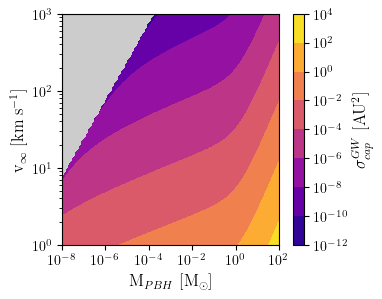

In [6]:
plt.figure(figsize=(3.5, 3))
v_inf_values_kms = [v.to(u.km/u.s).value for v in (v_inf_values * u.m/u.s)]
v_inf_values_auyr = [v.to(u.au/u.yr).value for v in (v_inf_values * u.m/u.s)]
m_pbh_values_in_Msun = m_pbh_values / const.M_sun.value
m_pbh_values_in_Mstar = m_pbh_values / M_star

# Fill background in red between min PBH mass and 1 solar mass
plt.fill_betweenx(v_inf_values_kms, 
                  np.min(m_pbh_values_in_Msun), 
                  1.0,  # 1 solar mass
                  color='gray', alpha=0.4, zorder=0)
plt.fill_betweenx(v_inf_values_kms, 
                  1.0, 
                  np.max(m_pbh_values_in_Msun),  # 1 solar mass
                  color='cyan', alpha=0.4, zorder=0)
plt.contourf(m_pbh_values_in_Msun, v_inf_values_kms, cross_section_grid,
             cmap='plasma', norm=plt.cm.colors.LogNorm())

# ✅ Set log scale AFTER plotting with linear values
plt.yscale('log')
plt.xscale('log')

cbar = plt.colorbar()
cbar.set_label(r'$\sigma_{cap}^{GW}$ [AU$^2$]')


# Add labels to contour lines

plt.xlabel(r'M$_{PBH}$ [M$_{\odot}$]')  # ✅ Remove log10 from label
plt.ylabel(r'v$_{\infty}$ [km s$^{-1}$]')  # ✅ Add space in unit
# plt.text(0.2, 0.6, r'Prohibited', fontsize=10, ha='center', va='center', 
#          transform=plt.gca().transAxes)
plt.xticks((1e-8, 1e-6, 1e-4, 1e-2, 1, 1e2))
# ✅ Remove manual yticks - log scale handles this automatically
plt.savefig(directoryp + f'{star}_capture_cross_section_new.png', 
            bbox_inches='tight')

/tmp/ipykernel_2257284/553690478.py:21: UserWarning: Log scale: values of z <= 0 have been masked
  plt.contourf((cross_section_grid), origin='lower', extent=[np.log10(m_pbh_values[0]),
/tmp/ipykernel_2257284/553690478.py:21: UserWarning: The following kwargs were not used by contour: 'aspect'
  plt.contourf((cross_section_grid), origin='lower', extent=[np.log10(m_pbh_values[0]),


NameError: name 'M_bh' is not defined

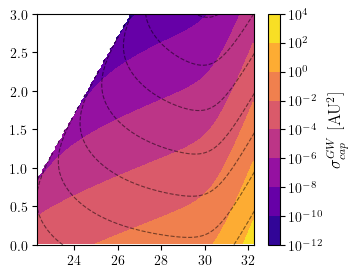

In [104]:

# import pandas as pd
# M, V = np.meshgrid(m_pbh_values / const.M_sun, v_inf_values)
# data = pd.DataFrame({
#     "M_pbh (M_sun)": M.flatten(),
#     "v_inf (km/s)": V.flatten(),
#     "Cross section (au^2)":cross_section_grid.flatten()
# })

# plt.figure(figsize=(3.5,3.5))
# sns.kdeplot(x=data["M_pbh (M_sun)"], y=data["v_inf (km/s)"], weights=data["Cross section (au^2)"], fill=True, cmap='plasma')

# plt.yscale('log')
# plt.xlabel("PBH mass [$M_\\odot$]")
# plt.ylabel("Velocity [km/s]")
# plt.title("Capture cross section contour plot")
# plt.show()
plt.figure(figsize=(3.5, 3))
v_inf_values_kms = [v.to(u.km/u.s).value for v in (v_inf_values * u.m/u.s)]
v_inf_values_auyr = [v.to(u.au/u.yr).value for v in (v_inf_values * u.m/u.s)]

plt.contourf((cross_section_grid), origin='lower', extent=[np.log10(m_pbh_values[0]),
                                                       np.log10(m_pbh_values[-1]),
                                                       np.log10(v_inf_values_kms[0]),
                                                       np.log10(v_inf_values_kms[-1])],
           aspect='auto', cmap='plasma', norm=plt.cm.colors.LogNorm())
# plt.hlines(np.log10(2/(3*10**4)), np.log10(m_pbh_values[0]), np.log10(m_pbh_values[-1]), color='blue', linestyle='--')
cbar = plt.colorbar()
cbar.set_label(r'$\sigma_{cap}^{GW}$ [AU$^2$]')
contour = plt.contour(np.log10(m_pbh_values), np.log10(v_inf_values_kms),(semaj_grid),
                      colors='black', linewidths=0.8,  norm=plt.cm.colors.LogNorm(),
                      linestyles='--', alpha=0.5)
a = compute_semimajor_axis(M_bh, M_star, v_inf_values)
a = (a * u.m).to(u.au).value
# semaj_grid = np.zeros_like(M_grid)
# for i in range(gridsize):
#     for j in range(gridsize):
#         a = compute_semimajor_axis(M_bh, M_star, V_grid[i, j])
#         semaj_grid[i, j] = a
# semaj_grid = semaj_grid * (const.R_sun.value**2 * const.c.value**2) * 6.68459e-12


# contour2 = plt.contour(np.log10(m_pbh_values), np.log10(v_inf_values),(R_star_au),
#                       colors='blue', linewidths=0.8,  norm=plt.cm.colors.LogNorm(),
#                       linestyles='--', alpha=0.5)
plt.vlines(np.log10(M_bh), np.log10(v_inf_values_kms[0]), np.log10(v_inf_values_kms[-1]), color='red', linestyle='--', alpha=0.5)
# Add labels to the contour lines
plt.clabel(contour, inline=True, fontsize=8, fmt=lambda x: f"{x:.0f} AU")
# plt.contour(np.log10(m_pbh_values), np.log10(v_inf_values),(semaj_grid),
#                         colors='blue', linewidths=0.8,  norm=plt.cm.colors.LogNorm(),
#                         linestyles='--', alpha=0.5)
# Add labels to the contour lines
# plt.clabel(contour, inline=True, fontsize=8, fmt=lambda x: f"{x:.1E} AU")
# plt.clabel(contour2, inline=True, fontsize=8, fmt=lambda x: f"R_star {x:.1E} AU")
plt.xlabel(r'log10($M_{PBH}$) [$M_\odot$]')
plt.ylabel(r'$v_{\infty}$ [km/s]')
plt.text(0.2, 0.6, r'Prohibited', fontsize=10, ha='center', va='center', transform=plt.gca().transAxes)
# plt.text(0.5, 0.6, r'(Capture without collision is not possible)', fontsize=10, ha='center', va='center', transform=plt.gca().transAxes)
plt.yticks(np.log10(v_inf_values_kms)[::10], [f'{x:.1g}' for x in (v_inf_values_kms)[::10]])# plt.title('Capture cross-section as function of PBH mass and velocity')
plt.savefig(directoryp + f'{star}_capture_cross_section_plus_semaj_grid.png',bbox_inches='tight')
# plt.show()



In [ ]:

# import pandas as pd
# M, V = np.meshgrid(m_pbh_values / const.M_sun, v_inf_values)
# data = pd.DataFrame({
#     "M_pbh (M_sun)": M.flatten(),
#     "v_inf (km/s)": V.flatten(),
#     "Cross section (au^2)":cross_section_grid.flatten()
# })

# plt.figure(figsize=(3.5,3.5))
# sns.kdeplot(x=data["M_pbh (M_sun)"], y=data["v_inf (km/s)"], weights=data["Cross section (au^2)"], fill=True, cmap='plasma')

# plt.yscale('log')
# plt.xlabel("PBH mass [$M_\\odot$]")
# plt.ylabel("Velocity [km/s]")
# plt.title("Capture cross section contour plot")
# plt.show()
semaj_grid = np.zeros_like(M_grid)
for i in range(gridsize):
    for j in range(gridsize):
        Rb_ave = (b_min_values[i, j] + b_max_values[i, j]) / 2
        a = compute_semimajor_axis(Rb_ave, M_grid[i, j], M_star, V_grid[i, j])
        semaj_grid[i, j] = (a*u.m).to(u.au).value
        print(f'semaj: {semaj_grid[i, j]}')
semaj_grid = semaj_grid 
plt.figure(figsize=(3.5, 3))
v_inf_values_kms = [v.to(u.km/u.s).value for v in (v_inf_values * u.m/u.s)]
v_inf_values_auyr = [v.to(u.au/u.yr).value for v in (v_inf_values * u.m/u.s)]
m_pbh_values_in_Msun = m_pbh_values / const.M_sun.value
m_pbh_values_in_Mstar = m_pbh_values / M_star

# Fill background in red between min PBH mass and 1 solar mass
plt.fill_betweenx(v_inf_values_kms, 
                  np.min(m_pbh_values_in_Mstar), 
                  1.0,  # 1 solar mass
                  color='gray', alpha=0.4, zorder=0)
plt.fill_betweenx(v_inf_values_kms, 
                  1.0, 
                  np.max(m_pbh_values_in_Mstar),  # 1 solar mass
                  color='cyan', alpha=0.4, zorder=0)
plt.contourf(m_pbh_values_in_Mstar, v_inf_values_kms, cross_section_grid,
             cmap='plasma', norm=plt.cm.colors.LogNorm())

# ✅ Set log scale AFTER plotting with linear values
plt.yscale('log')
plt.xscale('log')

cbar = plt.colorbar()
cbar.set_label(r'$\sigma_{cap}^{GW}$ [AU$^2$]')

# # ✅ Contour also uses linear values
# contour = plt.contour(m_pbh_values_in_Mstar, v_inf_values_kms, semaj_grid,
#                       colors='black', linewidths=0.8, norm=plt.cm.colors.LogNorm(),
#                       linestyles='--', alpha=0.5)

# ✅ Vertical line uses LINEAR M_bh value
# plt.vlines(, v_inf_values_kms[0], v_inf_values_kms[-1], 
#            color='red', linestyle='--', alpha=0.5)

# Add labels to contour lines
plt.clabel(contour, inline=True, fontsize=8, fmt=lambda x: fr"{x:.1f} AU")

plt.xlabel(r'M$_{PBH}$ [M$_{\odot}$]')  # ✅ Remove log10 from label
plt.ylabel(r'v$_{\infty}$ [km s$^{-1}$]')  # ✅ Add space in unit
# plt.text(0.2, 0.6, r'Prohibited', fontsize=10, ha='center', va='center', 
#          transform=plt.gca().transAxes)

# ✅ Remove manual yticks - log scale handles this automatically
plt.savefig(directoryp + f'{star}_capture_cross_section_plus_semaj_grid.png', 
            bbox_inches='tight')


## V3 Maggiore


/tmp/ipykernel_2679585/4244360235.py:71: RuntimeWarning: divide by zero encountered in scalar divide
  r = R / (1 + e * np.cos(phi))


0.9999999994596214
0.9999999994304288
0.999999999400441
0.9999999993697641
0.9999999993385187
0.9999999993068402
0.999999999274917
0.9999999992429536
0.999999999211203
0.9999999991799619
0.9999999991495785
0.9999999991204682
0.9999999990931069
0.999999999068043
0.9999999990459546
0.9999999990275346
0.9999999990136621
0.9999999990053574
0.9999999990037093
0.9999999990100433
0.9999999990258336
0.9999999990528101
0.9999999990929053
0.9999999991483394
0.9999999992216767
0.9999999993157636
0.9999999994339379
0.999999999579939
0.9999999997580148
0.9999999999731
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
0.9999999993770802
0.9999999993420893
0.9999999993059582
0.9999999992687654
0.9999999992306299
0.9999999991916667
0.9999999991520292
0.999999999111926
0.99999

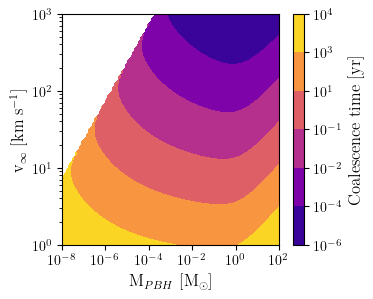

In [79]:


coal3 = np.full_like(M_grid, np.nan, dtype=float)

for j in range(gridsize):
    for i in range(gridsize):
        v = v_inf_values[i]
        b_ave = (b_min_values[i, j] + b_max_values[i, j]) / 2
        a0, e0 = compute_semimajor_axis(
            (b_ave), 
            M_grid[i, j],
            M_star,
            V_grid[i, j],
        )
        print(e0)

        # Coalescence formula requires a bound ellipse: 0 <= e0 < 1 and a0 > 0
        if (not np.isfinite(a0)) or (not np.isfinite(e0)) or (a0 <= 0) or (e0 < 0) or (e0 >= 1):
            continue

        t_sec = coalescence_time_v3(b_ave, M_grid[i, j], M_star,a0, e0)  # returns seconds (SI)
        t_yr = (t_sec * u.s).to(u.yr).value
        coal3[i, j] = t_yr

# Mask places with no capture and any non-positive/invalid times (LogNorm needs > 0)
coal3 = np.where(cross_section_grid == 0, np.nan, coal3)
coal_plotv3 = np.ma.masked_invalid(coal3)
coal_plotv3 = np.ma.masked_less_equal(coal_plotv3, 0.0)

if coal_plotv3.count() == 0:
    raise ValueError("No finite positive coalescence times to plot (coal is all NaN/<=0). Check e0 computation.")
vmin = float(coal_plotv3.min())
vmax = float(coal_plotv3.max())

plt.figure(figsize=(3.5, 3))
v_inf_values_kms = (v_inf_values * u.m / u.s).to(u.km / u.s).value
m_pbh_values_in_Msun = m_pbh_values / const.M_sun.value

from matplotlib.colors import LogNorm
plt.contourf(
    m_pbh_values_in_Msun,
    v_inf_values_kms,
    coal_plotv3,
    levels=np.logspace(np.log10(vmin), np.log10(vmax), 7),
    cmap="plasma",
    norm=LogNorm(vmin=vmin, vmax=vmax),
)

plt.yscale("log")
plt.xscale("log")
cbar = plt.colorbar()
cbar.set_label(r"Coalescence time [yr]")
cbar.set_ticks(np.logspace(np.log10(vmin), np.log10(vmax), 7))
cbar.set_ticklabels([f"{sci_notation_latex(x)}" for x in cbar.get_ticks()])

plt.xlabel(r"M$_{PBH}$/M$_{NS}$")
plt.ylabel(r"v$_{\infty}$ [km s$^{-1}$]")
plt.savefig(directoryp + f"{star}_coalescence_time_grid_v3.png", bbox_inches="tight")

# ...existing code...
plt.xlabel(r'M$_{PBH}$ [M$_{\odot}$]')  # ✅ Remove log10 from label
plt.ylabel(r'v$_{\infty}$ [km s$^{-1}$]')  # ✅ Add space in unit
# plt.text(0.2, 0.6, r'Prohibited', fontsize=10, ha='center', va='center', 
#          transform=plt.gca().transAxes)
# ✅ Remove manual yticks - log scale handles this automatically
plt.savefig(directoryp + f'{star}_coalescence_time_grid_v3.png',         
            bbox_inches='tight')

Capture rate for mPBH = 1.988409870698051e+22: 1.249741780528598e-07
Capture rate for mPBH = 2.5090886816967527e+22: 1.2378102569756835e-07
Capture rate for mPBH = 3.166110823222096e+22: 1.2275817925900278e-07
Capture rate for mPBH = 3.995178734832619e+22: 1.2133307183563483e-07
Capture rate for mPBH = 5.041343785627538e+22: 1.1933613136556542e-07
Capture rate for mPBH = 6.361454355796221e+22: 1.175462349664592e-07
Capture rate for mPBH = 8.027244965171783e+22: 1.1553705092547866e-07
Capture rate for mPBH = 1.0129234311359054e+23: 1.1320966770950863e-07
Capture rate for mPBH = 1.278164403597693e+23: 1.1109089731025522e-07
Capture rate for mPBH = 1.6128605503697247e+23: 1.0890738742211903e-07
Capture rate for mPBH = 2.035199186909688e+23: 1.0644398413835163e-07
Capture rate for mPBH = 2.568130102412354e+23: 1.0435889737030549e-07
Capture rate for mPBH = 3.240612646338075e+23: 1.0217565065806953e-07
Capture rate for mPBH = 4.0891893731324924e+23: 9.99831862680447e-08
Capture rate for mPB

/tmp/ipykernel_2679585/3530604210.py:51: UserWarning: Log scale: values of z <= 0 have been masked
  plt.contourf(m_pbh_values_in_Msun, v_inf_values_kms, n_eqs_grid,


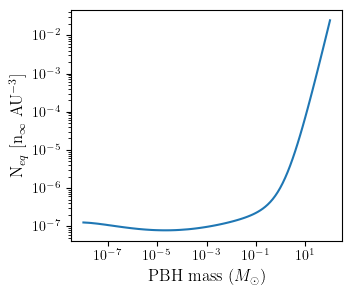

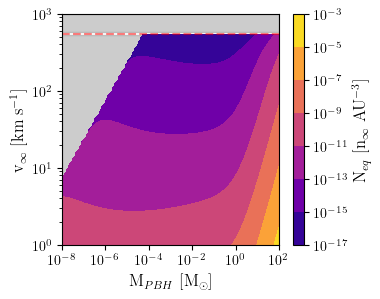

In [80]:
m_pbh_values_in_Msun = m_pbh_values / const.M_sun.value
n_eqs_perpbh = []
n_eqs_grid = np.zeros_like(M_grid)
for j in range(gridsize):
    x_vals = []
    y_vals = []
    for i in range(gridsize):
        # print(m, M_star, R_star, v)
        v = v_inf_values[i]
        lifetime = coal3[i, j]
        term_rate = 1 / lifetime
        f = galactic_dm_maxwell_dist(v=v)
        v_inf_auyr = (v * u.m / u.s).to(u.au / u.yr).value
        rate =  f * cross_section_grid[i, j] * v_inf_auyr / term_rate
        y_vals.append(rate)
        x_vals.append(v)
        n_eqs_grid[i, j] = rate
    n_eq = integrate_gauss_legendre(x_vals, y_vals, n=100)
    print(f'Capture rate for mPBH = {m_pbh_values[j]}:', n_eq)
    n_eqs_perpbh.append(n_eq)
plt.figure(figsize=(3.5,3))
plt.plot(m_pbh_values_in_Msun, n_eqs_perpbh)
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r"PBH mass ($M_{\odot}$)")
plt.ylabel(r'N$_{eq}$ [n$_\infty$ AU$^{-3}$]')
plt.savefig(directoryp + f'{star}_neq_per_mPBH.png')
    
plt.figure(figsize=(3.5,3))

# Filter velocities below 550 km/s
v_below_550 = np.array(v_inf_values_kms)[np.array(v_inf_values_kms) < 550]
v_above_550 = np.array(v_inf_values_kms)[np.array(v_inf_values_kms) >= 550]

# Fill for velocities < 550 km/s between min mass and 1 solar mass
plt.fill_betweenx(v_below_550, 
                  np.min(m_pbh_values_in_Msun), 
                  1.0,  # 1 solar mass
                  color='gray', alpha=0.4, zorder=0)

# Fill for velocities < 550 km/s between 1 solar mass and max mass
plt.fill_betweenx(v_below_550, 
                  1.0, 
                  np.max(m_pbh_values_in_Msun),
                  color='cyan', alpha=0.4, zorder=0)

# Fill prohibited region (all masses, v >= 550 km/s)
plt.fill_between(m_pbh_values_in_Msun, v_above_550[0], np.max(v_inf_values_kms), 
                 alpha=0.4, color='gray', label='Prohibited Region')

plt.contourf(m_pbh_values_in_Msun, v_inf_values_kms, n_eqs_grid,
             cmap='plasma', norm=plt.cm.colors.LogNorm())

# ✅ Set log scale AFTER plotting with linear values
plt.yscale('log')
plt.xscale('log')

cbar = plt.colorbar()
cbar.set_label(r'$\sigma_{cap}^{GW}$ [AU$^2$]')

plt.hlines(550, np.min(m_pbh_values_in_Msun), np.max(m_pbh_values_in_Msun), 
           color='red', linestyle='--', alpha=0.5, label=r'$v_{\infty} = 550$ km/s')
# ✅ Vertical line uses LINEAR M_bh value
# plt.vlines(, v_inf_values_kms[0], v_inf_values_kms[-1], 
#            color='red', linestyle='--', alpha=0.5)

# Add labels to contour lines

plt.xlabel(r'M$_{PBH}$ [M$_{\odot}$]')  # ✅ Remove log10 from label
plt.ylabel(r'v$_{\infty}$ [km s$^{-1}$]')  # ✅ Add space in unit
cbar.set_label(r'N$_{eq}$ [n$_\infty$ AU$^{-3}$]')
# plt.title('Capture cross-section as function of PBH mass and velocity')
plt.savefig(directoryp + f'{star}_neq_grid.png',bbox_inches='tight')
    


## V4 Peters 

/tmp/ipykernel_2679585/4244360235.py:71: RuntimeWarning: divide by zero encountered in scalar divide
  r = R / (1 + e * np.cos(phi))


0.9999999994596214
0.9999999994304288
0.999999999400441
0.9999999993697641
0.9999999993385187
0.9999999993068402
0.999999999274917
0.9999999992429536
0.999999999211203
0.9999999991799619
0.9999999991495785
0.9999999991204682
0.9999999990931069
0.999999999068043
0.9999999990459546
0.9999999990275346
0.9999999990136621
0.9999999990053574
0.9999999990037093
0.9999999990100433
0.9999999990258336
0.9999999990528101
0.9999999990929053
0.9999999991483394
0.9999999992216767
0.9999999993157636
0.9999999994339379
0.999999999579939
0.9999999997580148
0.9999999999731
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
0.9999999993770802
0.9999999993420893
0.9999999993059582
0.9999999992687654
0.9999999992306299
0.9999999991916667
0.9999999991520292
0.999999999111926
0.99999

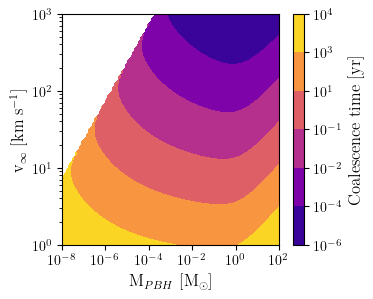

In [81]:


coal4 = np.full_like(M_grid, np.nan, dtype=float)

for j in range(gridsize):
    for i in range(gridsize):
        v = v_inf_values[i]
        b_ave = (b_min_values[i, j] + b_max_values[i, j]) / 2
        a0, e0 = compute_semimajor_axis(
            (b_ave), 
            M_grid[i, j],
            M_star,
            V_grid[i, j],
        )
        print(e0)

        # Coalescence formula requires a bound ellipse: 0 <= e0 < 1 and a0 > 0
        if (not np.isfinite(a0)) or (not np.isfinite(e0)) or (a0 <= 0) or (e0 < 0) or (e0 >= 1):
            continue

        t_sec = coalescence_time_v4(a0, e0, M_grid[i, j], M_star)  # returns seconds (SI)
        t_yr = (t_sec * u.s).to(u.yr).value
        coal4[i, j] = t_yr

# Mask places with no capture and any non-positive/invalid times (LogNorm needs > 0)
coal4 = np.where(cross_section_grid == 0, np.nan, coal4)
coal_plotv4 = np.ma.masked_invalid(coal4)
coal_plotv4 = np.ma.masked_less_equal(coal_plotv4, 0.0)

if coal_plotv4.count() == 0:
    raise ValueError("No finite positive coalescence times to plot (coal is all NaN/<=0). Check e0 computation.")
vmin = float(coal_plotv4.min())
vmax = float(coal_plotv4.max())

plt.figure(figsize=(3.5, 3))
v_inf_values_kms = (v_inf_values * u.m / u.s).to(u.km / u.s).value
# m_pbh_values_in_Mstar = m_pbh_values / M_star

from matplotlib.colors import LogNorm
plt.contourf(
    m_pbh_values_in_Msun,
    v_inf_values_kms,
    coal_plotv4,
    levels=np.logspace(np.log10(vmin), np.log10(vmax), 7),
    cmap="plasma",
    norm=LogNorm(vmin=vmin, vmax=vmax),
)

plt.yscale("log")
plt.xscale("log")
cbar = plt.colorbar()
cbar.set_label(r"Coalescence time [yr]")
cbar.set_ticks(np.logspace(np.log10(vmin), np.log10(vmax), 7))
cbar.set_ticklabels([f"{sci_notation_latex(x)}" for x in cbar.get_ticks()])

# IMPORTANT: remove this unless you define `contour` in THIS cell
# plt.clabel(contour, inline=True, fontsize=8, fmt=lambda x: fr"{x:.1e} yr")

plt.xlabel(r'M$_{PBH}$ [M$_{\odot}$]')  # ✅ Remove log10 from label
plt.ylabel(r'v$_{\infty}$ [km s$^{-1}$]')  # ✅ Add space in unit
# plt.text(0.2, 0.6, r'Prohibited', fontsize=10, ha='center', va='center', 
#          transform=plt.gca().transAxes)
# ✅ Remove manual yticks - log scale handles this automatically
plt.savefig(directoryp + f'{star}_coalescence_time_grid_v4.png',         
            bbox_inches='tight')

## V5 Caizzo

/tmp/ipykernel_2679585/4244360235.py:71: RuntimeWarning: divide by zero encountered in scalar divide
  r = R / (1 + e * np.cos(phi))


Formatting 2.57e-06 as 2.57 × 10^-6
Formatting 2.18e-03 as 2.18 × 10^-3
Formatting 1.84e+00 as 1.84 × 10^0
Formatting 1.56e+03 as 1.56 × 10^3
Formatting 1.32e+06 as 1.32 × 10^6
Formatting 1.12e+09 as 1.12 × 10^9
Formatting 9.50e+11 as 9.50 × 10^11


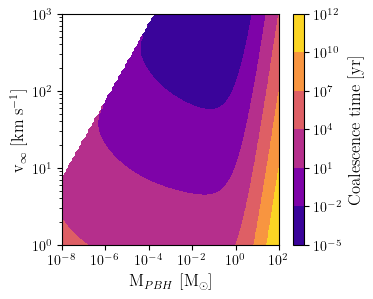

In [82]:

coal5 = np.full_like(M_grid, np.nan, dtype=float)

for j in range(gridsize):
    for i in range(gridsize):
        v = v_inf_values[i]
        b_ave = (b_min_values[i, j] + b_max_values[i, j]) / 2
        a0, e0 = compute_semimajor_axis(
            (b_ave),
            M_grid[i, j],
            M_star,
            V_grid[i, j],
        )
        # print(e0)

        # # Coalescence formula requires a bound ellipse: 0 <= e0 < 1 and a0 > 0
        if (not np.isfinite(a0)) or (not np.isfinite(e0)) or (a0 <= 0) or (e0 < 0) or (e0 >= 1):
            continue
        E = equation((b_min_values[i, j] + b_max_values[i, j]) / 2, M_grid[i, j], M_star, V_grid[i, j])
        
        t_sec = coalescence_time_v5(v_inf_values[i], b_ave, M_grid[i, j], M_star, R_star, E, a0, e0)  # returns seconds (SI)
        t_yr = (t_sec * u.s).to(u.yr).value
        coal5[i, j] = t_yr

# Mask places with no capture and any non-positive/invalid times (LogNorm needs > 0)
coal5 = np.where(cross_section_grid == 0, np.nan, coal5)
coal_plotv5 = np.ma.masked_invalid(coal5)  # Assuming similar masking for v5
coal_plotv5 = np.ma.masked_less_equal(coal_plotv5, 0.0)

if coal_plotv5.count() == 0:
    raise ValueError("No finite positive coalescence times to plot (coal is all NaN/<=0). Check e0 computation.")
vmin = float(coal_plotv5.min())
vmax = float(coal_plotv5.max())

plt.figure(figsize=(3.5, 3))
v_inf_values_kms = (v_inf_values * u.m / u.s).to(u.km / u.s).value
# m_pbh_values_in_Mstar = m_pbh_values / M_star

from matplotlib.colors import LogNorm
plt.contourf(
    m_pbh_values_in_Msun,
    v_inf_values_kms,
    coal_plotv5,
    levels=np.logspace(np.log10(vmin), np.log10(vmax), 7),
    cmap="plasma",
    norm=LogNorm(vmin=vmin, vmax=vmax),
)

plt.yscale("log")
plt.xscale("log")
cbar = plt.colorbar()
cbar.set_label(r"Coalescence time [yr]")
cbar.set_ticks(np.logspace(np.log10(vmin), np.log10(vmax), 7))
cbar.set_ticklabels([f"{sci_notation_latex(x)}" for x in cbar.get_ticks()])

plt.xlabel(r'M$_{PBH}$ [M$_{\odot}$]')  # ✅ Remove log10 from label
plt.ylabel(r'v$_{\infty}$ [km s$^{-1}$]')  # ✅ Add space in unit
# plt.text(0.2, 0.6, r'Prohibited', fontsize=10, ha='center', va='center', 
#          transform=plt.gca().transAxes)
# ✅ Remove manual yticks - log scale handles this automatically
plt.savefig(directoryp + f'{star}_coalescence_time_grid_v5.png',         
            bbox_inches='tight')

## V6 Raidal

/tmp/ipykernel_1973211/3832447262.py:80: RuntimeWarning: divide by zero encountered in scalar divide
  r = R / (1 + e * np.cos(phi))


0.9999999994596214
0.9999999994304288
0.999999999400441
0.9999999993697641
0.9999999993385187
0.9999999993068402
0.999999999274917
0.9999999992429536
0.999999999211203
0.9999999991799619
0.9999999991495785
0.9999999991204682
0.9999999990931069
0.999999999068043
0.9999999990459546
0.9999999990275346
0.9999999990136621
0.9999999990053574
0.9999999990037093
0.9999999990100433
0.9999999990258336
0.9999999990528101
0.9999999990929053
0.9999999991483394
0.9999999992216767
0.9999999993157636
0.9999999994339379
0.999999999579939
0.9999999997580148
0.9999999999731
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
0.9999999993770802
0.9999999993420893
0.9999999993059582
0.9999999992687654
0.9999999992306299
0.9999999991916667
0.9999999991520292
0.999999999111926
0.99999

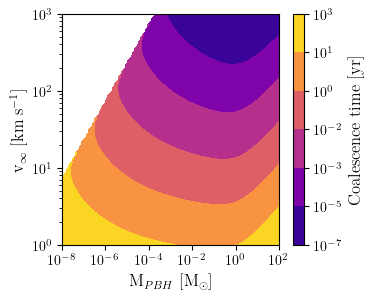

In [49]:


coal6 = np.full_like(M_grid, np.nan, dtype=float)

for j in range(gridsize):
    for i in range(gridsize):
        v = v_inf_values[i]
        b_ave = (b_min_values[i, j] + b_max_values[i, j]) / 2
        a0, e0 = compute_semimajor_axis(
            (b_ave), 
            M_grid[i, j],
            M_star,
            V_grid[i, j],
        )
        print(e0)

        # Coalescence formula requires a bound ellipse: 0 <= e0 < 1 and a0 > 0
        if (not np.isfinite(a0)) or (not np.isfinite(e0)) or (a0 <= 0) or (e0 < 0) or (e0 >= 1):
            continue

        t_sec = coalescence_time_v6(V_grid[i, j], b_ave, b_max_values[i, j], M_grid[i, j], M_star)  # returns seconds (SI)
        t_yr = (t_sec * u.s).to(u.yr).value
        coal6[i, j] = t_yr

# Mask places with no capture and any non-positive/invalid times (LogNorm needs > 0)
coal6 = np.where(cross_section_grid == 0, np.nan, coal6)
coal_plotv6 = np.ma.masked_invalid(coal6)
coal_plotv6 = np.ma.masked_less_equal(coal_plotv6, 0.0)
# coal_plotv6 = coal6

# if coal_plotv6.count() == 0:
#     raise ValueError("No finite positive coalescence times to plot (coal is all NaN/<=0). Check e0 computation.")
vmin = float(coal_plotv6.min())
vmax = float(coal_plotv6.max())

plt.figure(figsize=(3.5, 3))
v_inf_values_kms = (v_inf_values * u.m / u.s).to(u.km / u.s).value
m_pbh_values_in_Msun = m_pbh_values / const.M_sun.value

from matplotlib.colors import LogNorm
plt.contourf(
    m_pbh_values_in_Msun,
    v_inf_values_kms,
    coal_plotv6,
    levels=np.logspace(np.log10(vmin), np.log10(vmax), 7),
    cmap="plasma",
    norm=LogNorm(vmin=vmin, vmax=vmax),
)

plt.yscale("log")
plt.xscale("log")
cbar = plt.colorbar()
cbar.set_label(r"Coalescence time [yr]")
cbar.set_ticks(np.logspace(np.log10(vmin), np.log10(vmax), 7))
cbar.set_ticklabels([f"{sci_notation_latex(x)}" for x in cbar.get_ticks()])

plt.xlabel(r'M$_{PBH}$ [M$_{\odot}$]')  # ✅ Remove log10 from label
plt.ylabel(r'v$_{\infty}$ [km s$^{-1}$]')  # ✅ Add space in unit
# plt.text(0.2, 0.6, r'Prohibited', fontsize=10, ha='center', va='center', 
#          transform=plt.gca().transAxes)
# ✅ Remove manual yticks - log scale handles this automatically
plt.savefig(directoryp + f'{star}_coalescence_time_grid_v6.png',         
            bbox_inches='tight')

In [106]:
import numpy as np

threshold = 1  # solar masses

# x-axis is mass, so mask the columns
mass_mask = (m_pbh_values_in_Msun >= threshold) & (m_pbh_values_in_Msun <= 10) 

# coal_plotv7 is shape (len(v_inf), len(mass))
Z = np.ma.filled(coal_plotv6, np.nan)

sub = Z[:, mass_mask]   # keep only masses above threshold

iy, ix_rel = np.unravel_index(np.nanargmax(sub), sub.shape)
ix = np.where(mass_mask)[0][ix_rel]

print("mass [M_sun] =", m_pbh_values_in_Msun[ix])
print("v_inf [km/s]  =", v_inf_values_kms[iy])
print("max t_coal [yr] =", sub[iy, ix_rel])

mass [M_sun] = 10.0
v_inf [km/s]  = 1.0
max t_coal [yr] = 226.83228177006046


In [77]:
import numpy as np
filled = np.ma.filled(coal_plotv6, np.nan)
i, j = np.unravel_index(np.nanargmax(filled), filled.shape)
mass_solar = m_pbh_values_in_Msun[i]
print('mass (M_sun), indices (i,j), value:', mass_solar, (i,j), filled[i,j])

mass (M_sun), indices (i,j), value: 1e-08 (np.int64(0), np.int64(0)) 334.88094496517175


Capture rate for mPBH = 1.988409870698051e+22: 7.871941056474574e-05
Capture rate for mPBH = 2.451404625764512e+22: 7.810276040750476e-05
Capture rate for mPBH = 3.0222061999269763e+22: 7.75586418276348e-05
Capture rate for mPBH = 3.7259170595015695e+22: 7.661959542094331e-05
Capture rate for mPBH = 4.593484698238079e+22: 7.57684322549418e-05
Capture rate for mPBH = 5.66306263289985e+22: 7.461854040575927e-05
Capture rate for mPBH = 6.981688302226768e+22: 7.356495304913205e-05
Capture rate for mPBH = 8.607351659201099e+22: 7.229235547985484e-05
Capture rate for mPBH = 1.0611545428277331e+23: 7.112218069715119e-05
Capture rate for mPBH = 1.3082409181693069e+23: 6.979820085934267e-05
Capture rate for mPBH = 1.6128605503697247e+23: 6.858846894603691e-05
Capture rate for mPBH = 1.9884098706980508e+23: 6.720109939740201e-05
Capture rate for mPBH = 2.451404625764512e+23: 6.602260734517426e-05
Capture rate for mPBH = 3.0222061999269763e+23: 6.469834454534043e-05
Capture rate for mPBH = 3.7259

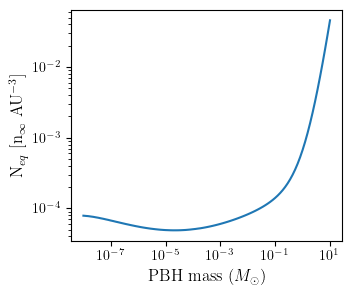

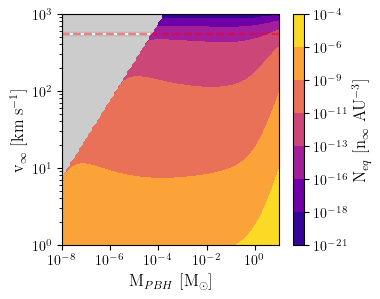

In [36]:
m_pbh_values_in_Msun = m_pbh_values / const.M_sun.value
n_eqs_perpbh = []
n_eqs_grid = np.zeros_like(M_grid)
for j in range(gridsize):
    x_vals = []
    y_vals = []
    for i in range(gridsize):
        # print(m, M_star, R_star, v)
        v = v_inf_values[i]
        lifetime = coal6[i, j]
        term_rate = 1 / lifetime
        v_km_s = (v * u.m / u.s).to(u.km / u.s).value
        f = galactic_dm_maxwell_dist(v=v_km_s)
        v_inf_auyr = (v * u.m / u.s).to(u.au / u.yr).value
        rate =  f * cross_section_grid[i, j] * v_inf_auyr / term_rate
        y_vals.append(rate)
        x_vals.append(v)
        n_eqs_grid[i, j] = rate
    n_eq = integrate_gauss_legendre(x_vals, y_vals, n=100)
    print(f'Capture rate for mPBH = {m_pbh_values[j]}:', n_eq)
    n_eqs_perpbh.append(n_eq)
plt.figure(figsize=(3.5,3))
plt.plot(m_pbh_values_in_Msun, n_eqs_perpbh)
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r"PBH mass ($M_{\odot}$)")
plt.ylabel(r'N$_{eq}$ [n$_\infty$ AU$^{-3}$]')
plt.savefig(directoryp + f'{star}_neq_per_mPBH.png')
    
plt.figure(figsize=(3.5,3))
n_eqs_grid = np.ma.masked_invalid(n_eqs_grid)

n_eqs_grid= np.ma.masked_less_equal(n_eqs_grid, 0.0)
vmin = float(n_eqs_grid.min())
vmax = float(n_eqs_grid.max())
# Filter velocities below 550 km/s
v_below_550 = np.array(v_inf_values_kms)[np.array(v_inf_values_kms) < 550]
v_above_550 = np.array(v_inf_values_kms)[np.array(v_inf_values_kms) >= 550]

# Fill for velocities < 550 km/s between min mass and 1 solar mass
plt.fill_betweenx(v_below_550, 
                  np.min(m_pbh_values_in_Msun), 
                  1.0,  # 1 solar mass
                  color='gray', alpha=0.4, zorder=0)

# Fill for velocities < 550 km/s between 1 solar mass and max mass
plt.fill_betweenx(v_below_550, 
                  1.0, 
                  np.max(m_pbh_values_in_Msun),
                  color='cyan', alpha=0.4, zorder=0)

# Fill prohibited region (all masses, v >= 550 km/s)
plt.fill_between(m_pbh_values_in_Msun, v_above_550[0], np.max(v_inf_values_kms), 
                 alpha=0.4, color='gray', label='Prohibited Region')

plt.contourf(m_pbh_values_in_Msun, v_inf_values_kms, n_eqs_grid, 
             cmap='plasma', norm=LogNorm(vmin=vmin, vmax=vmax), levels=np.logspace(np.log10(vmin), np.log10(vmax), 8))

# ✅ Set log scale AFTER plotting with linear values
plt.yscale('log')
plt.xscale('log')

cbar = plt.colorbar()
cbar.set_label(r'$\sigma_{cap}^{GW}$ [AU$^2$]')
cbar.set_ticks(np.logspace(np.log10(vmin), np.log10(vmax), 8))
cbar.set_ticklabels([f"{sci_notation_latex(x)}" for x in cbar.get_ticks()])
plt.hlines(550, np.min(m_pbh_values_in_Msun), np.max(m_pbh_values_in_Msun), 
           color='red', linestyle='--', alpha=0.5, label=r'$v_{\infty} = 550$ km/s')
# ✅ Vertical line uses LINEAR M_bh value
# plt.vlines(, v_inf_values_kms[0], v_inf_values_kms[-1], 
#            color='red', linestyle='--', alpha=0.5)

# Add labels to contour lines

plt.xlabel(r'M$_{PBH}$ [M$_{\odot}$]')  # ✅ Remove log10 from label
plt.ylabel(r'v$_{\infty}$ [km s$^{-1}$]')  # ✅ Add space in unit
cbar.set_label(r'N$_{eq}$ [n$_\infty$ AU$^{-3}$]')
# plt.title('Capture cross-section as function of PBH mass and velocity')
plt.savefig(directoryp + f'{star}_neq_grid.png',bbox_inches='tight')
    


## V7 Genolini 

/tmp/ipykernel_2679585/2428202523.py:70: RuntimeWarning: divide by zero encountered in scalar divide
  r = R / (1 + e * np.cos(phi))


0.9999999994596214
0.9999999994304288
0.999999999400441
0.9999999993697641
0.9999999993385187
0.9999999993068402
0.999999999274917
0.9999999992429536
0.999999999211203
0.9999999991799619
0.9999999991495785
0.9999999991204682
0.9999999990931069
0.999999999068043
0.9999999990459546
0.9999999990275346
0.9999999990136621
0.9999999990053574
0.9999999990037093
0.9999999990100433
0.9999999990258336
0.9999999990528101
0.9999999990929053
0.9999999991483394
0.9999999992216767
0.9999999993157636
0.9999999994339379
0.999999999579939
0.9999999997580148
0.9999999999731
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
0.9999999993770802
0.9999999993420893
0.9999999993059582
0.9999999992687654
0.9999999992306299
0.9999999991916667
0.9999999991520292
0.999999999111926
0.99999

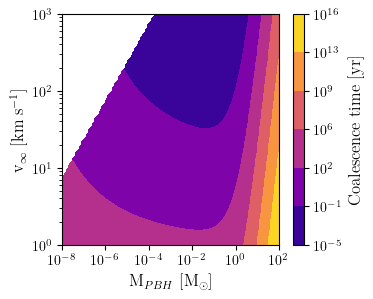

In [38]:


coal7 = np.full_like(M_grid, np.nan, dtype=float)

for j in range(gridsize):
    for i in range(gridsize):
        v = v_inf_values[i]
        b_ave = (b_min_values[i, j] + b_max_values[i, j]) / 2
        a0, e0 = compute_semimajor_axis(
            (b_ave), 
            M_grid[i, j],
            M_star,
            V_grid[i, j],
        )
        print(e0)

        # Coalescence formula requires a bound ellipse: 0 <= e0 < 1 and a0 > 0
        if (not np.isfinite(a0)) or (not np.isfinite(e0)) or (a0 <= 0) or (e0 < 0) or (e0 >= 1):
            continue

        t_sec = coalescence_time_v7(V_grid[i, j], b_ave, b_max_values[i, j], M_grid[i, j], M_star, R_star)  # returns seconds (SI)
        t_yr = (t_sec * u.s).to(u.yr).value
        coal7[i, j] = t_yr

# Mask places with no capture and any non-positive/invalid times (LogNorm needs > 0)
coal7 = np.where(cross_section_grid == 0, np.nan, coal7)
coal_plotv7 = np.ma.masked_invalid(coal7)
coal_plotv7 = np.ma.masked_less_equal(coal_plotv7, 0.0)

if coal_plotv7.count() == 0:
    raise ValueError("No finite positive coalescence times to plot (coal is all NaN/<=0). Check e0 computation.")
vmin = float(coal_plotv7.min())
vmax = float(coal_plotv7.max())

plt.figure(figsize=(3.5, 3))
v_inf_values_kms = (v_inf_values * u.m / u.s).to(u.km / u.s).value
# m_pbh_values_in_Mstar = m_pbh_values / M_star

from matplotlib.colors import LogNorm
plt.contourf(
    m_pbh_values_in_Msun,
    v_inf_values_kms,
    coal_plotv7,
    levels=np.logspace(np.log10(vmin), np.log10(vmax), 7),
    cmap="plasma",
    norm=LogNorm(vmin=vmin, vmax=vmax),
)

plt.yscale("log")
plt.xscale("log")
cbar = plt.colorbar()
cbar.set_label(r"Coalescence time [yr]")
cbar.set_ticks(np.logspace(np.log10(vmin), np.log10(vmax), 7))
cbar.set_ticklabels([f"{sci_notation_latex(x)}" for x in cbar.get_ticks()])

plt.xlabel(r'M$_{PBH}$ [M$_{\odot}$]')  # ✅ Remove log10 from label
plt.ylabel(r'v$_{\infty}$ [km s$^{-1}$]')  # ✅ Add space in unit
# plt.text(0.2, 0.6, r'Prohibited', fontsize=10, ha='center', va='center', 
#          transform=plt.gca().transAxes)
# ✅ Remove manual yticks - log scale handles this automatically
plt.savefig(directoryp + f'{star}_coalescence_time_grid_v7.png',         
            bbox_inches='tight')

Formatting 5.48e-08 as 5.48 × 10^-8
Formatting 3.37e-07 as 3.37 × 10^-7
Formatting 2.07e-06 as 2.07 × 10^-6
Formatting 1.27e-05 as 1.27 × 10^-5
Formatting 7.81e-05 as 7.81 × 10^-5
Formatting 4.80e-04 as 4.80 × 10^-4
Formatting 2.95e-03 as 2.95 × 10^-3
Formatting 1.81e-02 as 1.81 × 10^-2
Formatting 1.11e-01 as 1.11 × 10^-1
Formatting 6.84e-01 as 6.84 × 10^-1
Formatting 4.20e+00 as 4.20 × 10^0
Formatting 2.58e+01 as 2.58 × 10^1
Formatting 1.59e+02 as 1.59 × 10^2
Formatting 9.74e+02 as 9.74 × 10^2
Formatting 5.99e+03 as 5.99 × 10^3


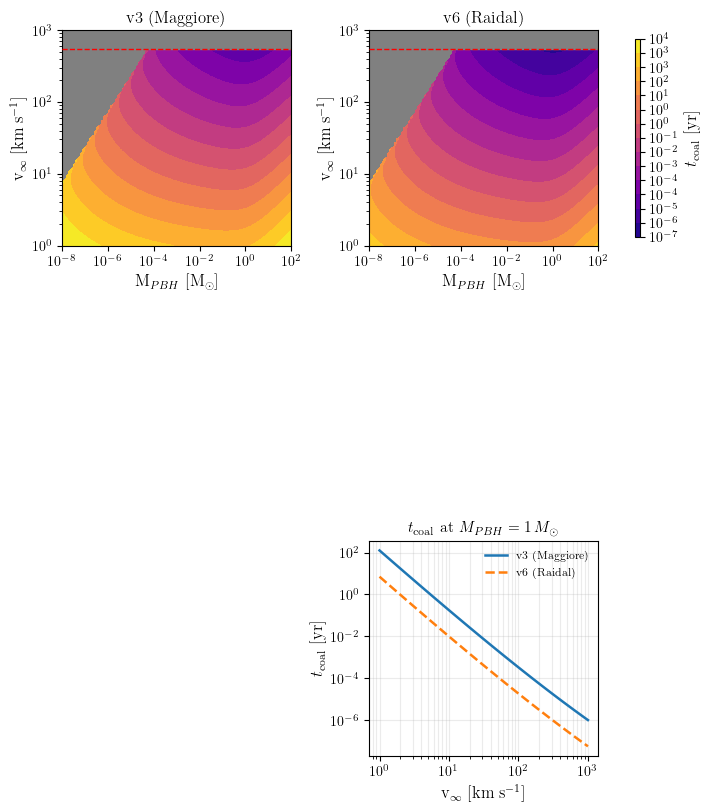

In [86]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

def plot_all_methods_one_figure(
    coal_by_ver,
    x, y,
    order=None,
    titles=None,
    levels=8,
    cmap="plasma",
    color_scale="log",
    robust_pct=None,            # None = use global min/max
    vmin=None,
    vmax=None,
    mask_nonpositive=True,
    figsize=(7, 8),
    xlabel=r"M$_{PBH}$ [M$_{\odot}$]",
    ylabel=r"v$_{\infty}$ [km s$^{-1}$]",
    suptitle=None,
    cbar_label=r"$t_{\mathrm{coal}}$ [yr]",
    cbar_ticks="levels",
    vline_kms=550,
):
    keys = list(coal_by_ver.keys())
    if order is None:
        order = keys

    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    Zs = []
    for k in order:
        Z = np.asanyarray(coal_by_ver[k])
        if isinstance(Z, np.ma.MaskedArray):
            Z = Z.filled(np.nan)
        Z = Z.astype(float, copy=False)

        if color_scale == "log" and mask_nonpositive:
            Z = np.where(Z > 0, Z, np.nan)

        Zs.append(Z)

    all_vals = np.concatenate([Z[np.isfinite(Z)].ravel() for Z in Zs])
    if all_vals.size == 0:
        raise ValueError("No finite values to plot.")

    if vmin is None or vmax is None:
        if robust_pct is None:
            lo, hi = np.nanmin(all_vals), np.nanmax(all_vals)
        else:
            lo, hi = np.nanpercentile(all_vals, robust_pct)

        if vmin is None:
            vmin = float(lo)
        if vmax is None:
            vmax = float(hi)

    if color_scale == "log":
        pos = all_vals[all_vals > 0]
        if pos.size == 0:
            raise ValueError("Log color scale requested but no positive values exist.")
        vmin = max(float(vmin), float(np.nanmin(pos)))
        vmax = float(vmax)
        norm = LogNorm(vmin=vmin, vmax=vmax)
        levels_shared = (
            np.logspace(np.log10(vmin), np.log10(vmax), int(levels))
            if np.isscalar(levels) else np.asarray(levels, dtype=float)
        )
    elif color_scale == "linear":
        norm = plt.Normalize(vmin=float(vmin), vmax=float(vmax))
        levels_shared = (
            np.linspace(float(vmin), float(vmax), int(levels))
            if np.isscalar(levels) else np.asarray(levels, dtype=float)
        )
    else:
        raise ValueError("color_scale must be 'log' or 'linear'")

    # 4x2 layout; slot 8 reserved for line plot
    fig = plt.figure(figsize=figsize, constrained_layout=True)
    n_rows, n_cols = 3, 2
    gs = fig.add_gridspec(n_rows, n_cols)

    line_slot = (2, 1)  # 8th place in 4x2 grid
    contour_slots = [
        (r, c)
        for r in range(n_rows)
        for c in range(n_cols)
        if (r, c) != line_slot
    ]

    if len(order) > len(contour_slots):
        raise ValueError(f"Too many methods ({len(order)}) for 4x2 layout with one line slot.")

    axes_cont = []
    used_slots = set()
    for idx, _k in enumerate(order):
        r, c = contour_slots[idx]
        ax = fig.add_subplot(gs[r, c])
        axes_cont.append(ax)
        used_slots.add((r, c))

    for r in range(n_rows):
        for c in range(n_cols):
            if (r, c) == line_slot or (r, c) in used_slots:
                continue
            empty_ax = fig.add_subplot(gs[r, c])
            empty_ax.axis("off")

    ax_line = fig.add_subplot(gs[line_slot[0], line_slot[1]])

    last_im = None
    for ax, k, Z in zip(axes_cont, order, Zs):
        last_im = ax.contourf(x, y, Z, levels=levels_shared, cmap=cmap, norm=norm, zorder=2)
        ax.set_xscale("log")
        ax.set_yscale("log")
        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)
        ax.set_title(titles.get(k, str(k)) if titles else str(k), fontsize=12)

        ax.axhline(vline_kms, color="red", ls="--", lw=1.0, alpha=1.0, zorder=3)
        ax.axhspan(vline_kms, np.nanmax(y), color="gray", alpha=1, zorder=2)
        ax.fill_betweenx(y, np.min(x), 1.0, color='gray', alpha=1, zorder=0)
        ax.fill_betweenx(y, 1.0, np.max(x), color='cyan', alpha=1, zorder=1)

    if suptitle:
        fig.suptitle(suptitle)

    cbar = fig.colorbar(last_im, ax=axes_cont, shrink=0.92, aspect=40)
    cbar.set_label(cbar_label)

    if cbar_ticks == "levels":
        cbar.set_ticks(levels_shared)
        if "sci_notation_latex" in globals():
            cbar.set_ticklabels([f"{sci_notation_latex(t)}" for t in levels_shared])
    elif cbar_ticks is not None:
        cbar.set_ticks(cbar_ticks)

    # Line plot: t_coal at M_PBH = 1 M_sun as a function of v_inf
    idx_msun = int(np.nanargmin(np.abs(x - 1.0)))
    line_styles = ["-", "--", "-.", ":", "-"]
    for i, (k, Z) in enumerate(zip(order, Zs)):
        t_line = Z[:, idx_msun]
        good = np.isfinite(t_line) & np.isfinite(y) & (t_line > 0) & (y > 0)
        if np.any(good):
            ax_line.plot(y[good], t_line[good], lw=1.8, linestyle=line_styles[i % len(line_styles)],
                         label=titles.get(k, str(k)) if titles else str(k))

    ax_line.set_xscale("log")
    ax_line.set_yscale("log")
    ax_line.set_xlabel(r"v$_{\infty}$ [km s$^{-1}$]")
    ax_line.set_ylabel(cbar_label)
    ax_line.set_title(r"$t_{\mathrm{coal}}$ at $M_{PBH}=1\,M_{\odot}$", fontsize=11)
    ax_line.grid(True, which="both", alpha=0.25)
    ax_line.legend(ncol=1, fontsize=8, frameon=False)

    return fig, (axes_cont, ax_line)

# ---- usage ----
# coal_by_ver = {"v3": coal_plotv3, "v4": coal_plotv4, "v5": coal_plotv5, "v6": coal_plotv6, "v7": coal_plotv7}
coal_by_ver = {"v3": coal_plotv3, "v6": coal_plotv6}
fig, axes = plot_all_methods_one_figure(
    coal_by_ver,
    x=m_pbh_values_in_Msun,
    y=v_inf_values_kms,
    # order=["v3", "v4", "v5", "v6", "v7"],
    order = ["v3", "v6"],
    # titles={"v3":"v3 (Maggiore)", "v4":"v4 (Peters)", "v5":"v5 (Caizzo)", "v6":"v6 (Raidal)", "v7":"v7 (Genolini)"},
    titles={"v3":"v3 (Maggiore)", "v6":"v6 (Raidal)"},

    color_scale="log",          # set to "linear" if you want linear color
    levels=15,
    cmap="plasma",
    suptitle=False,
    cbar_label=r"$t_{\mathrm{coal}}$ [yr]",
)
plt.show()
fig.savefig(directoryp + f'{star}_coalescence_time_comparison_all_methods.png', bbox_inches='tight')

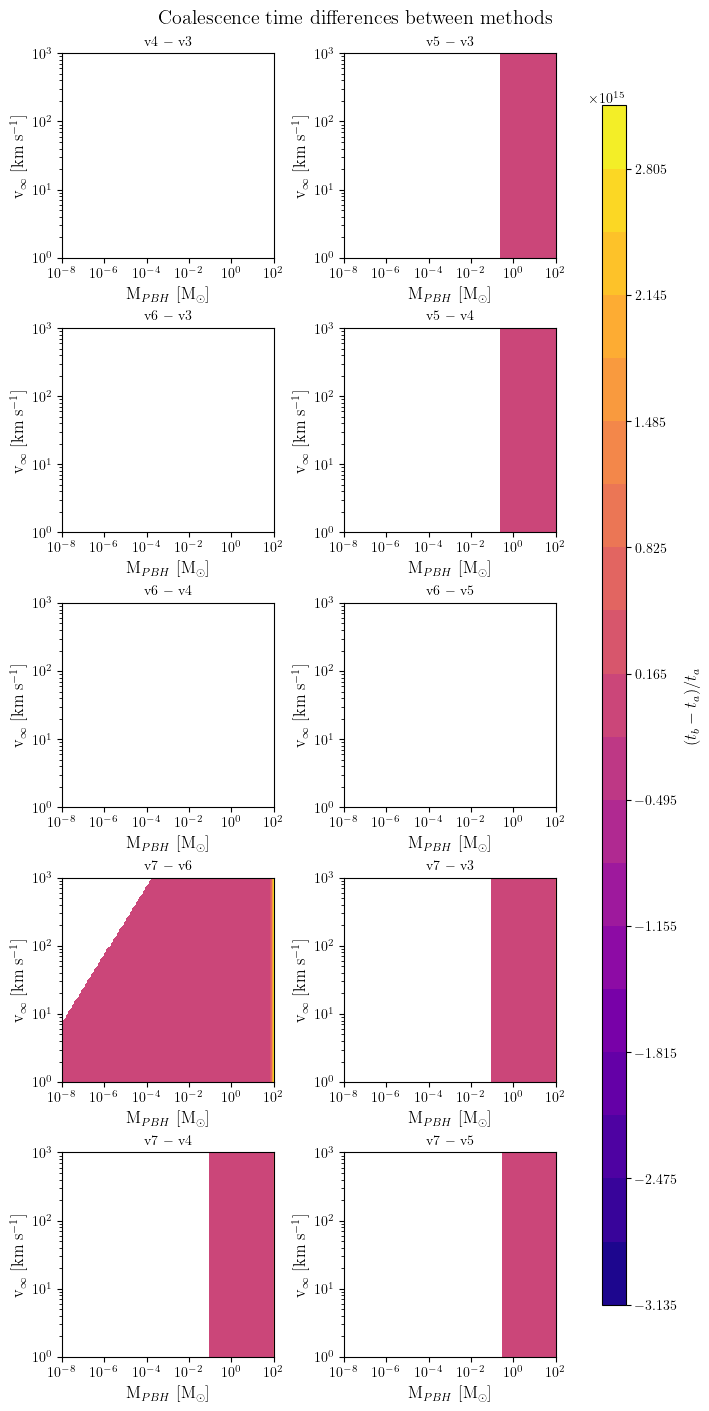

In [103]:
# ...existing code...
import numpy as np
import matplotlib.pyplot as plt
from itertools import combinations

def _as_float_nan(Z):
    """Convert arrays (incl. MaskedArray) to float ndarray with masked -> NaN."""
    if isinstance(Z, np.ma.MaskedArray):
        Z = Z.filled(np.nan)
    return np.asarray(Z, dtype=float)

def plot_pairwise_coal_diffs(
    coal_by_ver,
    x, y,
    pairs=None,
    mode="diff",          # "diff" | "log10_ratio" | "frac"
    abs_mask_lt=None,     # e.g. 1.0 to mimic: masked_where(abs(diff)<1)
    levels=7,
    cmap="plasma",
    robust_pct=None,      # None => use true max(|D|). e.g. 99 => percentile(|D|)
    vmax=None,            # optionally force symmetric range
    figsize=(7, 14),
    xlabel=r"M$_{PBH}$ [M$_{\odot}$]",
    ylabel=r"v$_{\infty}$ [km s$^{-1}$]",
    suptitle=None,
    vline_kms=550,        # velocity threshold to mark on plots
):
    versions = list(coal_by_ver.keys())
    if pairs is None:
        pairs = list(combinations(versions, 2))

    diffs = []
    titles = []

    # one shared label (shared colorbar can’t be pair-specific)
    if mode == "diff":
        cbar_label = r"$\Delta t$ [yr]"
    elif mode == "frac":
        cbar_label = r"$(t_b-t_a)/t_a$"
    elif mode == "log10_ratio":
        cbar_label = r"$\log_{10}(t_b/t_a)$"
    else:
        raise ValueError("mode must be one of: 'diff', 'frac', 'log10_ratio'")

    for a, b in pairs:
        A = _as_float_nan(coal_by_ver[a])
        B = _as_float_nan(coal_by_ver[b])

        D = np.full_like(A, np.nan, dtype=float)
        m = np.isfinite(A) & np.isfinite(B)

        if mode == "diff":
            D[m] = B[m] - A[m]
        elif mode == "frac":
            m2 = m & (A != 0)
            D[m2] = 100 * (B[m2] - A[m2]) / A[m2]
        elif mode == "log10_ratio":
            m2 = m & (A > 0) & (B > 0)
            D[m2] = np.log10(B[m2] / A[m2])

        if abs_mask_lt is not None:
            D = np.where(np.abs(D) < abs_mask_lt, np.nan, D)

        diffs.append(D)
        titles.append(f"{b} − {a}")

    all_vals = np.concatenate([d[np.isfinite(d)].ravel() for d in diffs]) if diffs else np.array([])
    if all_vals.size == 0:
        raise ValueError("No finite values to plot (all diffs are NaN).")

    if vmax is None:
        if robust_pct is None:
            vmax = float(np.nanmax(np.abs(all_vals)))   # <- NO clipping
        else:
            vmax = float(np.nanpercentile(np.abs(all_vals), robust_pct))
            if vmax == 0 or not np.isfinite(vmax):
                vmax = float(np.nanmax(np.abs(all_vals)))

    norm = plt.Normalize(vmin=-vmax, vmax=+vmax)

    # make symmetric levels if "levels" is an int
    if np.isscalar(levels):
        nlev = int(levels)
        levels_used = np.linspace(-vmax, +vmax, nlev)
    else:
        levels_used = levels

    fig, axes = plt.subplots(len(diffs)//2 + len(diffs)%2, 2, figsize=figsize, constrained_layout=True)
    axes = axes.ravel()

    last_im = None
    for ax, D, title in zip(axes, diffs, titles):
        last_im = ax.contourf(
            x, y, D,
            levels=levels_used,
            cmap=cmap,
            norm=norm,
        )
        ax.set_xscale("log")
        ax.set_yscale("log")
        ax.set_title(title, fontsize=10)
        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)
        # Fill background in red between min PBH mass and 1 solar mass
        # ax.axhline(vline_kms, color="red", ls="--", lw=1.0, alpha=1.0, zorder=3)
        # ax.axhspan(vline_kms, np.nanmax(v_inf_values_kms), color="gray", alpha=1, zorder=2)
        #     # Fill background in red between min PBH mass and 1 solar mass
        # ax.fill_betweenx(v_inf_values_kms, 
        #                 np.min(m_pbh_values_in_Msun), 
        #                 1.0,  # 1 solar mass
        #                 color='gray', alpha=1, zorder=0)
        # ax.fill_betweenx(v_inf_values_kms, 
        #                 1.0, 
        #                 np.max(m_pbh_values_in_Msun),  # 1 solar mass
        #                 color='cyan', alpha=1, zorder=1)


    for ax in axes[len(diffs):]:
        ax.axis("off")

    if suptitle:
        fig.suptitle(suptitle)

    cbar = fig.colorbar(last_im, ax=axes.tolist(), shrink=0.92, aspect=50)
    cbar.set_label(cbar_label)

    return fig, axes


# ---- usage (matches your "difference plots above" style) ----
coal_by_ver = {"v3": coal_plotv3, "v4": coal_plotv4, "v5": coal_plotv5, "v6": coal_plotv6, "v7": coal_plotv7}

pairs = [("v3", "v4"), ("v3", "v5"), ("v3", "v6"),
         ("v4", "v5"), ("v4", "v6"), ("v5", "v6"), ("v6", "v7"), ("v3", "v7"), ("v4", "v7"), ("v5", "v7")]

fig, axes = plot_pairwise_coal_diffs(
    coal_by_ver,
    x=m_pbh_values_in_Msun,
    y=v_inf_values_kms,
    pairs=pairs,
    mode="frac",
    abs_mask_lt=100,
    levels=20,
    cmap="plasma",
    robust_pct=None,   # <- ensures the colorbar reaches the true extrema
    suptitle=r"Coalescence time differences between methods ",
)
plt.show()
fig.savefig(directoryp + f'{star}_coalescence_time_pairwise_differences.png', bbox_inches='tight')
# ...existing code...

/tmp/ipykernel_2679585/392055379.py:77: UserWarning: The following kwargs were not used by contour: 'figsize'
  plt.contourf(


TypeError: cannot unpack non-iterable NoneType object

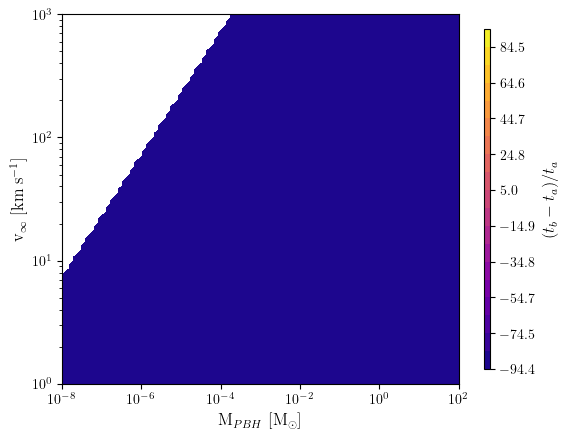

In [108]:
def plot_pairwise_coal_diffs(
    coal_by_ver,
    x, y,
    pairs=None,
    mode="diff",          # "diff" | "log10_ratio" | "frac"
    abs_mask_lt=None,     # e.g. 1.0 to mimic: masked_where(abs(diff)<1)
    levels=7,
    cmap="plasma",
    robust_pct=None,      # None => use true max(|D|). e.g. 99 => percentile(|D|)
    vmax=None,            # optionally force symmetric range
    figsize=(7, 14),
    xlabel=r"M$_{PBH}$ [M$_{\odot}$]",
    ylabel=r"v$_{\infty}$ [km s$^{-1}$]",
    suptitle=None,
    vline_kms=550,        # velocity threshold to mark on plots
):
    versions = list(coal_by_ver.keys())
    if pairs is None:
        pairs = list(combinations(versions, 2))

    diffs = []
    titles = []

    # one shared label (shared colorbar can’t be pair-specific)
    if mode == "diff":
        cbar_label = r"$\Delta t$ [yr]"
    elif mode == "frac":
        cbar_label = r"$(t_b-t_a)/t_a$"
    elif mode == "log10_ratio":
        cbar_label = r"$\log_{10}(t_b/t_a)$"
    else:
        raise ValueError("mode must be one of: 'diff', 'frac', 'log10_ratio'")

    for a, b in pairs:
        A = _as_float_nan(coal_by_ver[a])
        B = _as_float_nan(coal_by_ver[b])

        D = np.full_like(A, np.nan, dtype=float)
        m = np.isfinite(A) & np.isfinite(B)

        if mode == "diff":
            D[m] = B[m] - A[m]
        elif mode == "frac":
            m2 = m & (A != 0)
            D[m2] = 100 * (B[m2] - A[m2]) / A[m2]
        elif mode == "log10_ratio":
            m2 = m & (A > 0) & (B > 0)
            D[m2] = np.log10(B[m2] / A[m2])

        if abs_mask_lt is not None:
            D = np.where(np.abs(D) < abs_mask_lt, np.nan, D)

        diffs.append(D)
        titles.append(f"{b} − {a}")

    all_vals = np.concatenate([d[np.isfinite(d)].ravel() for d in diffs]) if diffs else np.array([])
    if all_vals.size == 0:
        raise ValueError("No finite values to plot (all diffs are NaN).")

    if vmax is None:
        if robust_pct is None:
            vmax = float(np.nanmax(np.abs(all_vals)))   # <- NO clipping
        else:
            vmax = float(np.nanpercentile(np.abs(all_vals), robust_pct))
            if vmax == 0 or not np.isfinite(vmax):
                vmax = float(np.nanmax(np.abs(all_vals)))

    norm = plt.Normalize(vmin=-vmax, vmax=+vmax)

    # make symmetric levels if "levels" is an int
    if np.isscalar(levels):
        nlev = int(levels)
        levels_used = np.linspace(-vmax, +vmax, nlev)
    else:
        levels_used = levels

    plt.contourf(
        x, y, D,
        levels=levels_used,
        cmap=cmap,
        norm=norm,
        figsize=figsize
    )
    plt.xscale('log')
    plt.yscale("log")
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    # Fill background in red between min PBH mass and 1 solar mass
    # ax.axhline(vline_kms, color="red", ls="--", lw=1.0, alpha=1.0, zorder=3)
    # ax.axhspan(vline_kms, np.nanmax(v_inf_values_kms), color="gray", alpha=1, zorder=2)
    #     # Fill background in red between min PBH mass and 1 solar mass
    # ax.fill_betweenx(v_inf_values_kms, 
    #                 np.min(m_pbh_values_in_Msun), 
    #                 1.0,  # 1 solar mass
    #                 color='gray', alpha=1, zorder=0)
    # ax.fill_betweenx(v_inf_values_kms, 
    #                 1.0, 
    #                 np.max(m_pbh_values_in_Msun),  # 1 solar mass
    #                 color='cyan', alpha=1, zorder=1)


    cbar = plt.colorbar(shrink=0.92, aspect=50)
    cbar.set_label(cbar_label)

    


fig, axes = plot_pairwise_coal_diffs(
    {"v3": coal_plotv3, "v6": coal_plotv6},
    x=m_pbh_values_in_Msun,
    y=v_inf_values_kms,
    pairs=[("v3", "v6")],
    mode="frac",
    abs_mask_lt=80,
    levels=20,
    cmap="plasma",
    robust_pct=None,   # <- ensures the colorbar reaches the true extrema
    # suptitle=r"Coalescence time differences between methods ",
    figsize=(3.5,3.5)
)
plt.show()
fig.savefig(directoryp + f'{star}_coalescence_time_pairwise_differences_v3v6.png', bbox_inches='tight')

In [8]:


def _as_float_nan(Z):
    """Convert arrays (incl. MaskedArray) to float ndarray with masked -> NaN."""
    if isinstance(Z, np.ma.MaskedArray):
        Z = Z.filled(np.nan)
    return np.asarray(Z, dtype=float)

def compute_neq_from_lifetime(
    lifetime_yr_grid,
    cross_section_grid,
    v_inf_values_mps,
    vesc_mps=550e3,
    n_int=100,
):
    """
    Returns:
      neq_grid: 2D array (v,M) with neq(v,M) = f(v)*sigma(v,M)*v*(1/tcoal) (masked to NaN where <=0/invalid)
      neq_per_mass: 1D array over M, integral over v (<vesc) of neq(v,M)
    """
    lifetime = _as_float_nan(lifetime_yr_grid)
    cs = _as_float_nan(cross_section_grid)

    v = np.asarray(v_inf_values_mps, dtype=float)
    f = galactic_dm_maxwell_dist(v=v, vesc=vesc_mps)  # your function: includes heaviside(vesc-v)
    v_auyr = (v * u.m / u.s).to(u.au / u.yr).value

    # term_rate = 1 / lifetime (yr^-1)
    term_rate = np.where(np.isfinite(lifetime) & (lifetime > 0), 1.0 / lifetime, np.nan)

    neq_grid = np.full_like(cs, np.nan, dtype=float)
    neq_per_mass = np.full(cs.shape[1], np.nan, dtype=float)

    for j in range(cs.shape[1]):
        rate_v = f * cs[:, j] * v_auyr / term_rate[:, j]

        # Keep only strictly positive finite values for LogNorm
        good = (
            np.isfinite(rate_v)
            & (rate_v > 0)
            & np.isfinite(cs[:, j])
            & (cs[:, j] > 0)
            & (v < vesc_mps)
        )

        # Store grid (mask everything else)
        neq_grid[:, j] = np.where(good, rate_v, np.nan)

        # Integrate over v for this mass
        if np.count_nonzero(good) >= 2:
            neq_per_mass[j] = integrate_gauss_legendre(v[good], rate_v[good], n=n_int)
        else:
            neq_per_mass[j] = np.nan

    return neq_grid, neq_per_mass

def plot_neq_methods_with_line(
    neq_by_ver,
    neq_per_mass_by_ver,
    m_pbh_values_in_Msun,
    v_inf_values_kms,
    order=("v3", "v4", "v5", "v6", "v7"),
    titles=None,
    levels=15,
    cmap="plasma",
    robust_pct=None,     # None => global min/max; else percentile on all finite values (e.g. (1,99))
    figsize=(7, 8),
    suptitle=r"$N_{eq}$ grids by method + $N_{eq}(M_{PBH})$",
    cbar_label=r"N$_{eq}$ [n$_\infty$ AU$^{-3}$]",
    vline_kms=550.0,
):
    if titles is None:
        titles = {k: k for k in order}

    # --- shared color scale over all methods ---
    Zs = [_as_float_nan(neq_by_ver[k]) for k in order]
    all_vals = np.concatenate([Z[np.isfinite(Z) & (Z > 0)].ravel() for Z in Zs])
    if all_vals.size == 0:
        raise ValueError("No positive finite N_eq values to plot.")

    if robust_pct is None:
        vmin, vmax = float(np.nanmin(all_vals)), float(np.nanmax(all_vals))
    else:
        lo, hi = robust_pct
        vmin, vmax = np.nanpercentile(all_vals, [lo, hi]).astype(float)

    if not np.isfinite(vmin) or not np.isfinite(vmax) or vmin <= 0 or vmax <= 0 or vmin >= vmax:
        vmin, vmax = float(np.nanmin(all_vals)), float(np.nanmax(all_vals))

    norm = LogNorm(vmin=vmin, vmax=vmax)
    levels_shared = np.logspace(np.log10(vmin), np.log10(vmax), int(levels))

    fig = plt.figure(figsize=figsize, constrained_layout=True)
    n_rows, n_cols = 3, 2
    gs = fig.add_gridspec(n_rows, n_cols)

    # Put line plot in the 8th slot of a 4x2 grid -> (row=3, col=1)
    line_slot = (2, 1)
    contour_slots = [
        (r, c)
        for r in range(n_rows)
        for c in range(n_cols)
        if (r, c) != line_slot
    ]

    if len(order) > len(contour_slots):
        raise ValueError(f"Too many methods ({len(order)}) for 4x2 layout with one line slot.")

    axes_cont = []
    used_slots = set()
    for idx, _k in enumerate(order):
        r, c = contour_slots[idx]
        axes_cont.append(fig.add_subplot(gs[r, c]))
        used_slots.add((r, c))

    # Hide unused slots (except the dedicated line slot)
    for r in range(n_rows):
        for c in range(n_cols):
            if (r, c) == line_slot or (r, c) in used_slots:
                continue
            empty_ax = fig.add_subplot(gs[r, c])
            empty_ax.axis("off")

    ax_line = fig.add_subplot(gs[line_slot[0], line_slot[1]])

    last_im = None
    for ax, k, Z in zip(axes_cont, order, Zs):
        last_im = ax.contourf(
            m_pbh_values_in_Msun,
            v_inf_values_kms,
            Z,
            levels=levels_shared,
            cmap=cmap,
            norm=norm,
            zorder=2,
        )
        ax.set_xscale("log")
        ax.set_yscale("log")
        ax.set_title(titles.get(k, k), fontsize=11)
        ax.set_xlabel(r"M$_{PBH}$ [M$_\odot$]")
        ax.set_ylabel(r"v$_{\infty}$ [km s$^{-1}$]")

        # Prohibited region + line at vesc
        ax.axhline(vline_kms, color="red", ls="--", lw=1.0, alpha=1.0, zorder=3)
        ax.axhspan(vline_kms, np.nanmax(v_inf_values_kms), color="gray", alpha=1, zorder=2)
            # Fill background in red between min PBH mass and 1 solar mass
        ax.fill_betweenx(v_inf_values_kms, 
                        np.min(m_pbh_values_in_Msun), 
                        1.0,  # 1 solar mass
                        color='gray', alpha=1, zorder=0)
        ax.fill_betweenx(v_inf_values_kms, 
                        1.0, 
                        np.max(m_pbh_values_in_Msun),  # 1 solar mass
                        color='cyan', alpha=1, zorder=1)

    # shared colorbar for the 4 contour plots
    cbar = fig.colorbar(last_im, ax=axes_cont, shrink=0.95, pad=0.02, aspect=50)
    cbar.set_label(cbar_label)
    cbar.set_ticks(np.logspace(np.log10(vmin), np.log10(vmax), levels))
    cbar.set_ticklabels([f"{sci_notation_latex(x)}" for x in cbar.get_ticks()])
    # --- line subplot: N_eq(M) overlay ---
    line_styles = ["-", "--", "-.", ":", '-']
    for idx, k in enumerate(order):
        y = np.asarray(neq_per_mass_by_ver[k], dtype=float)
        ax_line.plot(m_pbh_values_in_Msun, y, lw=1.8, label=titles.get(k, k), linestyle=line_styles[idx % len(line_styles)])

    ax_line.set_xscale("log")
    ax_line.set_yscale("log")
    ax_line.set_xlabel(r"M$_{PBH}$ [M$_\odot$]")
    ax_line.set_ylabel(cbar_label)
    ax_line.grid(True, which="both", alpha=0.25)
    ax_line.legend(ncol=1, fontsize=9, frameon=False)

    if suptitle:
        fig.suptitle(suptitle)

    return fig, (axes_cont, ax_line)

# -------------------------
# Compute N_eq for each method (v3/v4/v5/v6)
# -------------------------
# Make sure these exist already:
#   coal_plotv3, coal_plotv4, coal_plotv5, coal_plotv6
#   cross_section_grid
#   m_pbh_values_in_Msun
#   v_inf_values  (m/s)
v_inf_values_kms = (np.asarray(v_inf_values) * u.m / u.s).to(u.km / u.s).value

neq_v3_grid, neq_v3_perM = compute_neq_from_lifetime(coal_plotv3, cross_section_grid, v_inf_values, vesc_mps=550e3)
neq_v4_grid, neq_v4_perM = compute_neq_from_lifetime(coal_plotv4, cross_section_grid, v_inf_values, vesc_mps=550e3)
neq_v5_grid, neq_v5_perM = compute_neq_from_lifetime(coal_plotv5, cross_section_grid, v_inf_values, vesc_mps=550e3)
neq_v6_grid, neq_v6_perM = compute_neq_from_lifetime(coal_plotv6, cross_section_grid, v_inf_values, vesc_mps=550e3)
neq_v7_grid, neq_v7_perM = compute_neq_from_lifetime(coal_plotv7, cross_section_grid, v_inf_values, vesc_mps=550e3)

neq_by_ver = {"v3": neq_v3_grid, "v4": neq_v4_grid, "v5": neq_v5_grid, "v6": neq_v6_grid, "v7": neq_v7_grid}
neq_per_mass_by_ver = {"v3": neq_v3_perM, "v4": neq_v4_perM, "v5": neq_v5_perM, "v6": neq_v6_perM, "v7": neq_v7_perM}

fig, (axes_cont, ax_line) = plot_neq_methods_with_line(
    neq_by_ver=neq_by_ver,
    neq_per_mass_by_ver=neq_per_mass_by_ver,
    m_pbh_values_in_Msun=m_pbh_values_in_Msun,
    v_inf_values_kms=v_inf_values_kms,
    order=("v3", "v4", "v5", "v6", "v7"),
    titles={"v3": "v3 (Maggiore)", "v4": "v4 (Peters)", "v5": "v5 (Caiozzo)", "v6": "v6 (Raidal)", "v7": "v7 (Genolini)"},
    levels=15,
    cmap="plasma",
    robust_pct=None,  # set (1, 99) if you want percentile clipping
    suptitle=False,
)
plt.show()
fig.savefig(directoryp + f'{star}_neq_comparison_all_methods.png', bbox_inches='tight')

NameError: name 'coal_plotv3' is not defined

In [9]:


def _as_float_nan(Z):
    """Convert arrays (incl. MaskedArray) to float ndarray with masked -> NaN."""
    if isinstance(Z, np.ma.MaskedArray):
        Z = Z.filled(np.nan)
    return np.asarray(Z, dtype=float)

def compute_neq_from_lifetime(
    lifetime_yr_grid,
    cross_section_grid,
    v_inf_values_mps,
    vesc_mps=550e3,
    n_int=100,
):
    """
    Returns:
      neq_grid: 2D array (v,M) with neq(v,M) = f(v)*sigma(v,M)*v*(1/tcoal) (masked to NaN where <=0/invalid)
      neq_per_mass: 1D array over M, integral over v (<vesc) of neq(v,M)
    """
    lifetime = _as_float_nan(lifetime_yr_grid)
    cs = _as_float_nan(cross_section_grid)

    v = np.asarray(v_inf_values_mps, dtype=float)
    f = galactic_dm_maxwell_dist(v=v, vesc=vesc_mps)  # your function: includes heaviside(vesc-v)
    v_auyr = (v * u.m / u.s).to(u.au / u.yr).value

    # term_rate = 1 / lifetime (yr^-1)
    term_rate = np.where(np.isfinite(lifetime) & (lifetime > 0), 1.0 / lifetime, np.nan)

    neq_grid = np.full_like(cs, np.nan, dtype=float)
    neq_per_mass = np.full(cs.shape[1], np.nan, dtype=float)

    for j in range(cs.shape[1]):
        rate_v = f * cs[:, j] * v_auyr / term_rate[:, j]

        # Keep only strictly positive finite values for LogNorm
        good = (
            np.isfinite(rate_v)
            & (rate_v > 0)
            & np.isfinite(cs[:, j])
            & (cs[:, j] > 0)
            & (v < vesc_mps)
        )

        # Store grid (mask everything else)
        neq_grid[:, j] = np.where(good, rate_v, np.nan)

        # Integrate over v for this mass
        if np.count_nonzero(good) >= 2:
            neq_per_mass[j] = integrate_gauss_legendre(v[good], rate_v[good], n=n_int)
        else:
            neq_per_mass[j] = np.nan

    return neq_grid, neq_per_mass

def plot_neq_methods_with_line(
    neq_by_ver,
    neq_per_mass_by_ver,
    m_pbh_values_in_Msun,
    v_inf_values_kms,
    order=("v3", "v4", "v5", "v6", "v7"),
    titles=None,
    levels=15,
    cmap="plasma",
    robust_pct=None,     # None => global min/max; else percentile on all finite values (e.g. (1,99))
    figsize=(7, 8),
    suptitle=r"$N_{eq}$ grids by method + $N_{eq}(M_{PBH})$",
    cbar_label=r"N$_{eq}$ [n$_\infty$ AU$^{-3}$]",
    vline_kms=550.0,
):
    if titles is None:
        titles = {k: k for k in order}

    # --- shared color scale over all methods ---
    Zs = [_as_float_nan(neq_by_ver[k]) for k in order]
    all_vals = np.concatenate([Z[np.isfinite(Z) & (Z > 0)].ravel() for Z in Zs])
    if all_vals.size == 0:
        raise ValueError("No positive finite N_eq values to plot.")

    if robust_pct is None:
        vmin, vmax = float(np.nanmin(all_vals)), float(np.nanmax(all_vals))
    else:
        lo, hi = robust_pct
        vmin, vmax = np.nanpercentile(all_vals, [lo, hi]).astype(float)

    if not np.isfinite(vmin) or not np.isfinite(vmax) or vmin <= 0 or vmax <= 0 or vmin >= vmax:
        vmin, vmax = float(np.nanmin(all_vals)), float(np.nanmax(all_vals))

    norm = LogNorm(vmin=vmin, vmax=vmax)
    levels_shared = np.logspace(np.log10(vmin), np.log10(vmax), int(levels))

    fig = plt.figure(figsize=figsize, constrained_layout=True)
    n_rows, n_cols = 3, 2
    gs = fig.add_gridspec(n_rows, n_cols)

    # Put line plot in the 8th slot of a 4x2 grid -> (row=3, col=1)
    line_slot = (2, 1)
    contour_slots = [
        (r, c)
        for r in range(n_rows)
        for c in range(n_cols)
        if (r, c) != line_slot
    ]

    if len(order) > len(contour_slots):
        raise ValueError(f"Too many methods ({len(order)}) for 4x2 layout with one line slot.")

    axes_cont = []
    used_slots = set()
    for idx, _k in enumerate(order):
        r, c = contour_slots[idx]
        axes_cont.append(fig.add_subplot(gs[r, c]))
        used_slots.add((r, c))

    # Hide unused slots (except the dedicated line slot)
    for r in range(n_rows):
        for c in range(n_cols):
            if (r, c) == line_slot or (r, c) in used_slots:
                continue
            empty_ax = fig.add_subplot(gs[r, c])
            empty_ax.axis("off")

    ax_line = fig.add_subplot(gs[line_slot[0], line_slot[1]])

    last_im = None
    for ax, k, Z in zip(axes_cont, order, Zs):
        last_im = ax.contourf(
            m_pbh_values_in_Msun,
            v_inf_values_kms,
            Z,
            levels=levels_shared,
            cmap=cmap,
            norm=norm,
            zorder=2,
        )
        ax.set_xscale("log")
        ax.set_yscale("log")
        ax.set_title(titles.get(k, k), fontsize=11)
        ax.set_xlabel(r"M$_{PBH}$ [M$_\odot$]")
        ax.set_ylabel(r"v$_{\infty}$ [km s$^{-1}$]")

        # Prohibited region + line at vesc
        ax.axhline(vline_kms, color="red", ls="--", lw=1.0, alpha=1.0, zorder=3)
        ax.axhspan(vline_kms, np.nanmax(v_inf_values_kms), color="gray", alpha=1, zorder=2)
            # Fill background in red between min PBH mass and 1 solar mass
        ax.fill_betweenx(v_inf_values_kms, 
                        np.min(m_pbh_values_in_Msun), 
                        1.0,  # 1 solar mass
                        color='gray', alpha=1, zorder=0)
        ax.fill_betweenx(v_inf_values_kms, 
                        1.0, 
                        np.max(m_pbh_values_in_Msun),  # 1 solar mass
                        color='cyan', alpha=1, zorder=1)

    # shared colorbar for the 4 contour plots
    cbar = fig.colorbar(last_im, ax=axes_cont, shrink=0.95, pad=0.02, aspect=50)
    cbar.set_label(cbar_label)
    cbar.set_ticks(np.logspace(np.log10(vmin), np.log10(vmax), levels))
    cbar.set_ticklabels([f"{sci_notation_latex(x)}" for x in cbar.get_ticks()])
    # --- line subplot: N_eq(M) overlay ---
    line_styles = ["-", "--", "-.", ":", '-']
    for idx, k in enumerate(order):
        y = np.asarray(neq_per_mass_by_ver[k], dtype=float)
        ax_line.plot(m_pbh_values_in_Msun, y, lw=1.8, label=titles.get(k, k), linestyle=line_styles[idx % len(line_styles)])

    ax_line.set_xscale("log")
    ax_line.set_yscale("log")
    ax_line.set_xlabel(r"M$_{PBH}$ [M$_\odot$]")
    ax_line.set_ylabel(cbar_label)
    ax_line.grid(True, which="both", alpha=0.25)
    ax_line.legend(ncol=1, fontsize=9, frameon=False)

    if suptitle:
        fig.suptitle(suptitle)

    return fig, (axes_cont, ax_line)

# -------------------------
# Compute N_eq for each method (v3/v4/v5/v6)
# -------------------------
# Make sure these exist already:
#   coal_plotv3, coal_plotv4, coal_plotv5, coal_plotv6
#   cross_section_grid
#   m_pbh_values_in_Msun
#   v_inf_values  (m/s)
v_inf_values_kms = (np.asarray(v_inf_values) * u.m / u.s).to(u.km / u.s).value

neq_v3_grid, neq_v3_perM = compute_neq_from_lifetime(coal_plotv3, cross_section_grid, v_inf_values, vesc_mps=550e3)
neq_v4_grid, neq_v4_perM = compute_neq_from_lifetime(coal_plotv4, cross_section_grid, v_inf_values, vesc_mps=550e3)
neq_v5_grid, neq_v5_perM = compute_neq_from_lifetime(coal_plotv5, cross_section_grid, v_inf_values, vesc_mps=550e3)
neq_v6_grid, neq_v6_perM = compute_neq_from_lifetime(coal_plotv6, cross_section_grid, v_inf_values, vesc_mps=550e3)
neq_v7_grid, neq_v7_perM = compute_neq_from_lifetime(coal_plotv7, cross_section_grid, v_inf_values, vesc_mps=550e3)

neq_by_ver = {"v3": neq_v3_grid, "v4": neq_v4_grid, "v5": neq_v5_grid, "v6": neq_v6_grid, "v7": neq_v7_grid}
neq_per_mass_by_ver = {"v3": neq_v3_perM, "v4": neq_v4_perM, "v5": neq_v5_perM, "v6": neq_v6_perM, "v7": neq_v7_perM}

# Plot just v5 contour
Z = _as_float_nan(neq_v6_grid)
all_vals = Z[np.isfinite(Z) & (Z > 0)].ravel()
vmin, vmax = float(np.nanmin(all_vals)), float(np.nanmax(all_vals))
norm = LogNorm(vmin=vmin, vmax=vmax)
levels_shared = np.logspace(np.log10(vmin), np.log10(vmax), 8)

fig, ax = plt.subplots(figsize=(3.5, 3))
im = ax.contourf(
    m_pbh_values_in_Msun,
    v_inf_values_kms,
    Z,
    levels=levels_shared,
    cmap="plasma",
    norm=norm,
    zorder=2,
)
ax.set_xscale("log")
ax.set_yscale("log")
# ax.set_title("v5 (Caiozzo)", fontsize=12)
ax.set_xlabel(r"M$_{PBH}$ [M$_\odot$]")
ax.set_ylabel(r"v$_{\infty}$ [km s$^{-1}$]")

# Prohibited region + line at vesc
ax.axhline(550.0, color="red", ls="--", lw=1.0, alpha=1.0, zorder=3)
ax.axhspan(550.0, np.nanmax(v_inf_values_kms), color="gray", alpha=1, zorder=2)
ax.fill_betweenx(v_inf_values_kms, 
                np.min(m_pbh_values_in_Msun), 
                1.0,
                color='gray', alpha=1, zorder=0)
ax.fill_betweenx(v_inf_values_kms, 
                1.0, 
                np.max(m_pbh_values_in_Msun),
                color='cyan', alpha=1, zorder=1)

cbar = fig.colorbar(im, ax=ax, pad=0.02)
cbar.set_label(r"N$_{eq}$ [n$_\infty$ AU$^{-3}$]")
cbar.set_ticks(np.logspace(np.log10(vmin), np.log10(vmax), 8))
cbar.set_ticklabels([f"{sci_notation_latex(x)}" for x in cbar.get_ticks()])

plt.show()
fig.savefig(directoryp + f'{star}_neq_v6.png', bbox_inches='tight')

NameError: name 'coal_plotv3' is not defined

In [32]:
from unicodedata import normalize
pathToPlots = directoryp
def voxel_2dhistogram(metric_list, metric_ylabels, voxel_list, voxel_xlabel,metric_ticks=None,voxel_ticks=None, metric_scale=['linear', 'linear', 'log'],voxel_scale='linear', metric_ranges=None, voxel_range=None, masks=[None, None], v_lim=[None, None], voxel_bins=20, metric_bins=100, voxel_unit_change= 1, metric_unit_change=[1, 1, 1], normalize=False, annotate_bins=False, annotation_norm=None, fig_size=None, save=True, save_as=None):
    """
    Plot 2D histogram of metrics vs a voxel parameter (single column, multiple rows).
    
    Parameters:
    -----------
    metric_list : list of lists
        List of metric data arrays, one per row (e.g., [mass_data, period_data])
    metric_ylabels : list of str
        Y-axis labels for each metric row
    voxel_data : list
        Voxel parameter data (same for all rows, e.g., semimajor axis bins)
    voxel_xlabel : str
        X-axis label for voxel parameter
    scale : list of 3 str
        [voxel_scale, metric_scale, colorbar_scale] e.g., ['linear', 'linear', 'log']
    metric_ranges : list of tuples
        [(min1, max1), (min2, max2)] for each metric row
    voxel_range : tuple
        (min, max) for voxel parameter
    v_lim : list
        [vmin, vmax] for colorbar
    voxel_bins : int or array
        Number of bins or bin edges for voxel parameter
    metric_bins : int
        Number of bins for metrics
    voxel_unit_change : float
        Factor to multiply voxel data by
    metric_unit_change : list of floats
        Factors to multiply metric data by
    normalize : bool
        Whether to normalize histogram counts
    annotate_bins : bool
        Whether to annotate bins with counts
    """
    nrows = len(metric_list)
    ncols = 1
    
    print(f'Creating {nrows}x{ncols} figure for voxel 2D histograms...')
    fig, axs = plt.subplots(figsize=fig_size if fig_size is not None else (4.5, 3*nrows),
                            nrows=nrows, ncols=ncols, sharex=True)
    
    if nrows == 1:
        axs = [axs]
    
    cmap = plt.get_cmap('plasma')
    cmap = cmap.with_extremes(bad=cmap(0))
    
    histogram_data_all = []
    global_hmin = np.inf
    global_hmax = -np.inf
    
    # Process each metric row
    for row_idx, metric_data in enumerate(metric_list):
        print(f"\n📊 Processing metric {row_idx+1}/{nrows}: {metric_ylabels[row_idx]}")
        voxel_data = voxel_list[row_idx]
        # Apply mask if provided - ADD THIS SECTION
        if masks[row_idx] is not None:
            data_mask = np.asarray(masks[row_idx], dtype=bool)
            if len(data_mask) != len(voxel_data):
                raise ValueError(f"data_mask length ({len(data_mask)}) must match voxel_data length ({len(voxel_data)})")
            
            # Filter voxel data
            voxel_data = [vox for vox, m in zip(voxel_data, data_mask) if m]
            
            # Filter all metrics
            metric_list = [met for met, m in zip(metric_data, data_mask) if m]
            
            print(f"Applied mask: {np.sum(data_mask)}/{len(data_mask)} systems selected")
    
        all_voxel = []
        all_metrics = []
        
        # Pair up voxel and metric data
        for vox, met in zip(voxel_data, metric_data):
            if vox is None or met is None:
                continue
            
            # Handle scalar or array metrics
            if isinstance(met, (list, tuple, np.ndarray)):
                met_averages = np.mean(met) if len(met) > 0 else met
                met_array = np.asarray(met_averages)
                # Repeat voxel value for each metric value
                all_voxel.append(vox * voxel_unit_change)
                all_metrics.append(met_array * metric_unit_change[row_idx])
            else:
                all_voxel.append(vox * voxel_unit_change)
                all_metrics.append(met * metric_unit_change[row_idx])
        
        if len(all_voxel) == 0:
            print(f"  Warning: No data for row {row_idx}")
            histogram_data_all.append(None)
            continue
        
        # Convert to arrays
        voxel_array = np.array(all_voxel)
        metric_array = np.array(all_metrics)
        
        # Filter invalid values
        valid_mask = np.isfinite(voxel_array) & np.isfinite(metric_array)
        voxel_array = voxel_array[valid_mask]
        metric_array = metric_array[valid_mask]
        
        print(f"  Valid data points: {len(voxel_array)}")
        
        if len(voxel_array) == 0:
            histogram_data_all.append(None)
            continue
        
        # Determine ranges
        voxel_range_used = voxel_range if voxel_range else (voxel_array.min(), voxel_array.max())
        if metric_ranges and row_idx < len(metric_ranges):
            metric_range_used = metric_ranges[row_idx]
        else:
            metric_range_used = (metric_array.min(), metric_array.max())
        
        print(f"  Voxel range: {voxel_range_used}, Metric range: {metric_range_used}")
        
        # Create bins
        if voxel_scale == 'log':
            voxel_bins_array = np.logspace(
                np.log10(voxel_range_used[0]),
                np.log10(voxel_range_used[1]),
                voxel_bins + 1
            )
        else:
            voxel_bins_array = np.linspace(
                voxel_range_used[0],
                voxel_range_used[1],
                voxel_bins + 1
            )
        
        if metric_scale[row_idx] == 'log':
            metric_bins_array = np.logspace(
                np.log10(metric_range_used[0]),
                np.log10(metric_range_used[1]),
                metric_bins + 1
            )
        else:
            metric_bins_array = np.linspace(
                metric_range_used[0],
                metric_range_used[1],
                metric_bins + 1
            )
        
        # Create histogram
        h, xedges, yedges = np.histogram2d(
            voxel_array, metric_array,
            bins=[voxel_bins_array, metric_bins_array]
        )
        
        counts = h.copy()
        
        if normalize:
            total = np.sum(h)
            if total > 0:
                h = h / normalize
        
        histogram_data_all.append((h, xedges, yedges, counts))
        
        # Track global min/max
        h_nonzero = h[h > 0]
        if len(h_nonzero) > 0:
            global_hmin = min(global_hmin, h_nonzero.min())
            global_hmax = max(global_hmax, h.max())
    
    # Create normalization
    vmin = v_lim[0] if v_lim[0] is not None else (global_hmin if global_hmin != np.inf else 1)
    vmax = v_lim[1] if v_lim[1] is not None else (global_hmax if global_hmax != -np.inf else None)
    
    if metric_scale[2] == 'log':
        from matplotlib.colors import LogNorm
        norm_obj = LogNorm(vmin=vmin, vmax=vmax)
    else:
        from matplotlib.colors import Normalize
        norm_obj = Normalize(vmin=vmin, vmax=vmax)
    
    # Plot
    first_pcm = None
    for row_idx in range(nrows):
        ax = axs[row_idx]
        
        if histogram_data_all[row_idx] is None:
            ax.text(0.5, 0.5, 'No Data', transform=ax.transAxes,
                   ha='center', va='center', fontsize=12)
            continue
        
        h_plot, xedges, yedges, counts = histogram_data_all[row_idx]
        
        # Plot histogram
        pcm = ax.pcolormesh(
            xedges, yedges, h_plot.T,
            cmap=cmap,
            norm=norm_obj,
            rasterized=True,
            shading='auto'
        )
        
        if first_pcm is None:
            first_pcm = pcm
        
        # Annotations
        if annotate_bins:
            # Calculate bin centers differently for log vs linear scales
            if voxel_scale == 'log':
                # Geometric mean for log scale
                x_centers = np.sqrt(xedges[:-1] * xedges[1:])
            else:
                # Arithmetic mean for linear scale
                x_centers = (xedges[:-1] + xedges[1:]) / 2
                
            if metric_scale[row_idx] == 'log':
                # Geometric mean for log scale
                y_centers = np.sqrt(yedges[:-1] * yedges[1:])
            else:
                # Arithmetic mean for linear scale
                y_centers = (yedges[:-1] + yedges[1:]) / 2
            
            for i in range(len(x_centers)):
                for j in range(len(y_centers)):
                    count = counts[i, j]
                    if count > 0:
                        if annotation_norm is not None:
                            count_percentage = (count / annotation_norm) * 100 if annotation_norm > 0 else 0
                        else:
                            count_percentage = (count / np.sum(counts)) * 100 if np.sum(counts) > 0 else 0
                        text = f'{np.round(count_percentage, 0):.0f}' if count_percentage >= 1 else f'{np.round(count_percentage, 1):.1f}'
                        c = 'white' if h_plot[i, j] < (vmax * 0.5) else 'black'
                        ax.text(x_centers[i], y_centers[j], text,
                               ha='center', va='center',
                               fontsize=10, color=c)
        
        # Set scales
        if metric_scale[row_idx] == 'log':
            ax.set_yscale('log')
        if voxel_scale == 'log':
            ax.set_xscale('log')
        
        # Set ticks        
        if metric_ticks:
            ax.set_yticks(metric_ticks[row_idx] if metric_ticks and metric_ticks[row_idx] else None)
        if voxel_ticks and row_idx == nrows - 1:
            ax.set_xticks(voxel_ticks if voxel_ticks else None)
        # Labels
        ax.set_ylabel(metric_ylabels[row_idx])
        
        # Only show x-label on bottom subplot
        if row_idx < nrows - 1:
            ax.tick_params(labelbottom=False)
        else:
            ax.set_xlabel(voxel_xlabel)
    
    # Add colorbar
    if first_pcm is not None:
        clabel = 'Occurrence' if normalize else 'Counts'
        # Convert axs to list if it's a numpy array
        ax_list = list(axs) if isinstance(axs, np.ndarray) else axs
        cbar = fig.colorbar(
            first_pcm,
            ax=ax_list,  # ✓ Now this works correctly
            label=clabel,
            aspect=20,
            pad=0.02,
            location='top',
            orientation='horizontal',
            cax=fig.add_axes([0.15, 0.98, 0.84, 0.015])
        )
    
    fig.subplots_adjust(hspace=0.02, left=0.15, right=0.99, top=0.97, bottom=0.08)
    
    if save:
        figname = save_as if save_as else f'voxel_2dhistogram.png'
        out = os.path.join(pathToPlots, figname)
        fig.savefig(out, dpi=300, bbox_inches='tight')
        print(f"\n✓ Figure saved to: {out}")
    else:
        plt.show()


# Final Calculations



In [50]:
gridsize = 100
m_pbh_values = np.logspace(-8, 1, gridsize) * const.M_sun.value # in M_sun
v_inf_values = np.logspace(3, 6, gridsize) # in m/s

M_grid, V_grid = np.meshgrid(m_pbh_values, v_inf_values)
cross_section_grid = np.zeros_like(M_grid)

b_max_values = np.zeros_like(M_grid)
b_min_values = np.zeros_like(M_grid)
for i in range(gridsize):
    for j in range(gridsize):
        b_min = b_minimum(M_star, m_pbh_values[j], R_star, v_inf_values[i])
        b_min_values[i, j] = b_min
        # print(equation(b_min_values, M_grid[i, j], M_star, V_grid[i, j]))
        b_max = compute_b_max(m_pbh_values[j], M_star, v_inf_values[i], b_min)
        b_max_values[i, j] = b_max
        b_min_au = (b_min * u.m).to(u.au).value
        # print(f'bmin: {b_min_au}')
        # print(f'p(e) at bmin: {p_e(eccentricity_original(b_min, m_pbh_values[j], M_star, v_inf_values[i]))}')
        # print(f'eccentricity at bmin: {eccentricity_original(b_min, m_pbh_values[j], M_star, v_inf_values[i])}')
        # print(f'equation(b_min): {equation(b_min, m_pbh_values[j], M_star, v_inf_values[i])}')
        # print(f'equation at bmax guess: {equation(b_min*1000000, m_pbh_values[j], M_star, v_inf_values[i])}')
        b_max_au = (b_max * u.m).to(u.au).value
        cs = compute_capture_crossec(b_min_au, b_max_au)
        # cs_au = (cs * u.m**2).to(u.au**2).value
        cross_section_grid[i, j] = cs
cross_section_grid = cross_section_grid
semaj_grid = np.zeros_like(M_grid)
eccentricity_grid = np.zeros_like(M_grid)
orbital_period_grid = np.zeros_like(M_grid)
for i in range(gridsize):
    for j in range(gridsize):
        Rb_ave = (b_min_values[i, j] + b_max_values[i, j]) / 2
        a, e = compute_semimajor_axis(Rb_ave, M_grid[i, j], M_star, V_grid[i, j])
        semaj_grid[i, j] = (a*u.m).to(u.au).value
        eccentricity_grid[i, j] = e
        orbital_period_grid[i, j] = orbital_period(M_grid[i, j], M_star, semaj_grid[i, j])
semaj_grid = semaj_grid 

/tmp/ipykernel_1973211/3832447262.py:80: RuntimeWarning: divide by zero encountered in scalar divide
  r = R / (1 + e * np.cos(phi))


L: 2.123019896599181e+38 r: 2.94939244706087e+20
L: 2.3104313338866094e+40 r: 8.085671536167168e+20
L: 1.2834150844538536e+44 r: 1.6445586798503245e+22
L: 1.5003731042459823e+43 r: 1.3706455160519776e+21
L: 6.93009946623801e+40 r: 5.930731908633843e+20
L: 7.91980974575045e+40 r: 7.745667579179707e+20
L: 2.7080139594692875e+43 r: 3.36363844448791e+21
L: 1.3753930703537385e+42 r: 1.1130553796403962e+21
L: 5.809484208656128e+43 r: 6.991769442738359e+21
L: 4.705391263117156e+43 r: 2.2105817432374198e+21
L: 9.564900032975836e+38 r: 2.1023164084703288e+20
L: 4.550838414541496e+43 r: 5.545318913191635e+21
L: 4.4390051573168717e+43 r: 5.276124026738429e+21


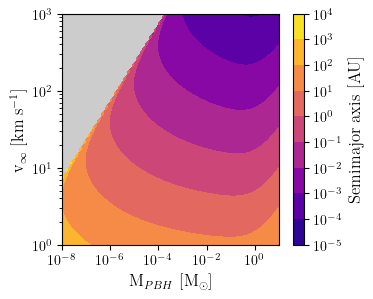

In [70]:
plt.figure(figsize=(3.5, 3))
v_inf_values_kms = [v.to(u.km/u.s).value for v in (v_inf_values * u.m/u.s)]
v_inf_values_auyr = [v.to(u.au/u.yr).value for v in (v_inf_values * u.m/u.s)]
m_pbh_values_in_Msun = m_pbh_values / const.M_sun.value
m_pbh_values_in_Mstar = m_pbh_values / M_star

# Fill background in red between min PBH mass and 1 solar mass
plt.fill_betweenx(v_inf_values_kms, 
                  np.min(m_pbh_values_in_Msun), 
                  1.0,  # 1 solar mass
                  color='gray', alpha=0.4, zorder=0)
plt.fill_betweenx(v_inf_values_kms, 
                  1.0, 
                  np.max(m_pbh_values_in_Msun),  # 1 solar mass
                  color='cyan', alpha=0.4, zorder=0)
plt.contourf(m_pbh_values_in_Msun, v_inf_values_kms, semaj_grid, levels=8,
             cmap='plasma', norm=plt.cm.colors.LogNorm())

# ✅ Set log scale AFTER plotting with linear values
plt.yscale('log')
plt.xscale('log')

cbar = plt.colorbar()
cbar.set_label(r'Semimajor axis [AU]')

# # ✅ Contour also uses linear values
# contour = plt.contour(m_pbh_values_in_Msun, v_inf_values_kms, semaj_grid,
#                       colors='black', linewidths=0.8, norm=plt.cm.colors.LogNorm(),
#                       linestyles='--', alpha=0.5)

# ✅ Vertical line uses LINEAR M_bh value
# plt.vlines(, v_inf_values_kms[0], v_inf_values_kms[-1], 
#            color='red', linestyle='--', alpha=0.5)

# Add labels to contour lines

plt.xlabel(r'M$_{PBH}$ [M$_{\odot}$]')  # ✅ Remove log10 from label
plt.ylabel(r'v$_{\infty}$ [km s$^{-1}$]')  # ✅ Add space in unit
# plt.text(0.2, 0.6, r'Prohibited', fontsize=10, ha='center', va='center', 
#          transform=plt.gca().transAxes)
plt.xticks((1e-8, 1e-6, 1e-4, 1e-2, 1))
# ✅ Remove manual yticks - log scale handles this automatically
plt.savefig(directoryp + f'{star}_semaj_averaged_b.png', 
            bbox_inches='tight')

Formatting 3.02e-12 as 3.02 × 10^-12
Formatting 3.88e-10 as 3.88 × 10^-10
Formatting 4.99e-08 as 4.99 × 10^-8
Formatting 6.42e-06 as 6.42 × 10^-6
Formatting 8.25e-04 as 8.25 × 10^-4
Formatting 1.06e-01 as 1.06 × 10^-1
Formatting 1.37e+01 as 1.37 × 10^1
Formatting 6.77e-17 as 6.77 × 10^-17
Formatting 9.60e-15 as 9.60 × 10^-15
Formatting 1.36e-12 as 1.36 × 10^-12
Formatting 1.93e-10 as 1.93 × 10^-10
Formatting 2.74e-08 as 2.74 × 10^-8
Formatting 3.89e-06 as 3.89 × 10^-6
Formatting 5.51e-04 as 5.51 × 10^-4


/tmp/ipykernel_1973211/3533454373.py:43: UserWarning: Log scale: values of z <= 0 have been masked
  im1 = ax1.contourf(m_pbh_values_in_Msun, v_inf_values_kms, cross_section_grid,


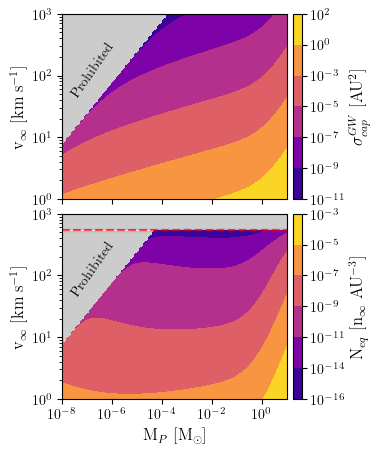

In [55]:
m_pbh_values_in_Msun = m_pbh_values / const.M_sun.value
n_eqs_perpbh = []
n_eqs_grid = np.zeros_like(M_grid)
neq_grid = np.zeros_like(M_grid)
r = 8  # kpc, for galactic DM distribution
for j in range(gridsize):
    x_vals = []
    y_vals = []
    for i in range(gridsize):
        # print(m, M_star, R_star, v)
        v = v_inf_values[i]
        lifetime = coal6[i, j]
        term_rate = 1 / lifetime
        v_km_s = (v * u.m / u.s).to(u.km / u.s).value
        f = galactic_dm_maxwell_dist(v=v_km_s, r=r)
        v_inf_auyr = (v * u.m / u.s).to(u.au / u.yr).value
        rate =  f * cross_section_grid[i, j] * v_inf_auyr / term_rate
        y_vals.append(rate)
        x_vals.append(v)
        n_eqs_grid[i, j] = rate
        neq_rf = neq_r_f(M_grid[i, j], rate, rf=r)
        neq_grid[i, j] = neq_rf['Neq_pbh_f_bound']
    n_eq = integrate_gauss_legendre(x_vals, y_vals, n=100)
    # print(f'Capture rate for mPBH = {m_pbh_values[j]}:', n_eq)
    n_eqs_perpbh.append(n_eq)

# Create 2x1 subplot with shared x-axis
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(3.5, 5), sharex=True)
vmin = float(cross_section_grid[cross_section_grid > 0].min())
vmax = float(cross_section_grid.max())
# ===== TOP PLOT: Cross-section grid =====
v_below_550 = np.array(v_inf_values_kms)[np.array(v_inf_values_kms) < 550]

ax1.fill_betweenx(np.array(v_inf_values_kms), 
                  np.min(m_pbh_values_in_Msun), 
                  1.0,
                  color='gray', alpha=0.4, zorder=0)
ax1.fill_betweenx(v_below_550, 
                  1.0, 
                  np.max(m_pbh_values_in_Msun),
                  color='cyan', alpha=0.4, zorder=0)

im1 = ax1.contourf(m_pbh_values_in_Msun, v_inf_values_kms, cross_section_grid,
                   cmap='plasma', norm=plt.cm.colors.LogNorm(), levels=np.logspace(np.log10(vmin), np.log10(vmax), 7), zorder=1)
ax1.set_yscale('log')
ax1.set_ylabel(r'v$_{\infty}$ [km s$^{-1}$]')
ax1.text(0.03, 0.7, r'Prohibited', fontsize=10, ha='left', va='center', rotation=55,
         transform=ax1.transAxes)
cbar1 = plt.colorbar(im1, ax=ax1, pad=0.02, shrink=1, aspect=20)
cbar1.set_label(r'$\sigma_{cap}^{GW}$ [AU$^2$]')
cbar1.set_ticks(np.logspace(np.log10(vmin), np.log10(vmax), 7))
cbar1.set_ticklabels([f"{sci_notation_latex(x)}" for x in cbar1.get_ticks()])

# ===== BOTTOM PLOT: N_eq grid =====
n_eqs_grid = np.ma.masked_invalid(n_eqs_grid)
n_eqs_grid = np.ma.masked_less_equal(n_eqs_grid, 0.0)
vmin = float(n_eqs_grid.min())
vmax = float(n_eqs_grid.max())

v_above_550 = np.array(v_inf_values_kms)[np.array(v_inf_values_kms) >= 550]

ax2.fill_betweenx(v_below_550, 
                  np.min(m_pbh_values_in_Msun), 
                  1.0,
                  color='gray', alpha=0.4, zorder=0)
ax2.fill_betweenx(v_below_550, 
                  1.0, 
                  np.max(m_pbh_values_in_Msun),
                  color='cyan', alpha=0.4, zorder=0)
ax2.fill_between(m_pbh_values_in_Msun, v_above_550[0], np.max(v_inf_values_kms), 
                 alpha=0.4, color='gray', label='Prohibited Region', zorder=0)

im2 = ax2.contourf(m_pbh_values_in_Msun, v_inf_values_kms, n_eqs_grid, 
                   cmap='plasma', norm=LogNorm(vmin=vmin, vmax=vmax), 
                   levels=np.logspace(np.log10(vmin), np.log10(vmax), 7), zorder=1)
ax2.set_yscale('log')
ax2.set_xscale('log')
ax2.set_xlabel(r'M$_{P}$ [M$_{\odot}$]')
ax2.set_ylabel(r'v$_{\infty}$ [km s$^{-1}$]')

ax2.hlines(550, np.min(m_pbh_values_in_Msun), np.max(m_pbh_values_in_Msun), 
           color='red', linestyle='--', alpha=0.7, linewidth=1.5)
ax2.text(0.03, 0.7, r'Prohibited', fontsize=10, ha='left', va='center', rotation=55,
         transform=ax2.transAxes)

cbar2 = plt.colorbar(im2, ax=ax2, pad=0.02, shrink=1, aspect=20)
cbar2.set_label(r'N$_{eq}$ [n$_\infty$ AU$^{-3}$]')
cbar2.set_ticks(np.logspace(np.log10(vmin), np.log10(vmax), 7))
cbar2.set_ticklabels([f"{sci_notation_latex(x)}" for x in cbar2.get_ticks()])

# Set log scale on top plot as well
ax1.set_xscale('log')

fig.subplots_adjust(hspace=0.08)
plt.savefig(directoryp + f'{star}_cross_section_neq_{r}kpc.png', bbox_inches='tight')

In [58]:
print(n_eqs_perpbh)

[np.float64(7.871941056474574e-05), np.float64(7.671854188169038e-05), np.float64(7.488684541727654e-05), np.float64(7.298664611318317e-05), np.float64(7.095659644100523e-05), np.float64(6.902818687903181e-05), np.float64(6.705666577327381e-05), np.float64(6.515291401665258e-05), np.float64(6.32631492447991e-05), np.float64(6.145964633992796e-05), np.float64(5.962682267164278e-05), np.float64(5.797298678543696e-05), np.float64(5.6316465916021104e-05), np.float64(5.477182044031029e-05), np.float64(5.325453452887459e-05), np.float64(5.182251667187736e-05), np.float64(5.048785127077326e-05), np.float64(4.9222535276125735e-05), np.float64(4.802026924940233e-05), np.float64(4.689124015440224e-05), np.float64(4.583937689431825e-05), np.float64(4.487280199139527e-05), np.float64(4.392643129319335e-05), np.float64(4.3124703561105353e-05), np.float64(4.2327779689418006e-05), np.float64(4.163545414323207e-05), np.float64(4.100467393903182e-05), np.float64(4.0424897204689874e-05), np.float64(3.98

# Final Plots


/tmp/ipykernel_1973211/4038001401.py:39: UserWarning: Log scale: values of z <= 0 have been masked
  im1 = ax1.contourf(m_pbh_values_in_Msun, v_inf_values_kms, cross_section_grid,


Formatting 3.02e-12 as 3.02 × 10^-12
Formatting 3.88e-10 as 3.88 × 10^-10
Formatting 4.99e-08 as 4.99 × 10^-8
Formatting 6.42e-06 as 6.42 × 10^-6
Formatting 8.25e-04 as 8.25 × 10^-4
Formatting 1.06e-01 as 1.06 × 10^-1
Formatting 1.37e+01 as 1.37 × 10^1
Formatting 2.79e-39 as 2.79 × 10^-39
Formatting 5.09e-36 as 5.09 × 10^-36
Formatting 9.27e-33 as 9.27 × 10^-33
Formatting 1.69e-29 as 1.69 × 10^-29
Formatting 3.08e-26 as 3.08 × 10^-26
Formatting 5.61e-23 as 5.61 × 10^-23
Formatting 1.02e-19 as 1.02 × 10^-19
Formatting 5.48e-08 as 5.48 × 10^-8
Formatting 2.34e-06 as 2.34 × 10^-6
Formatting 1.00e-04 as 1.00 × 10^-4
Formatting 4.28e-03 as 4.28 × 10^-3
Formatting 1.83e-01 as 1.83 × 10^-1
Formatting 7.83e+00 as 7.83 × 10^0
Formatting 3.35e+02 as 3.35 × 10^2
max n_eq: 1.0216826379712665e-19


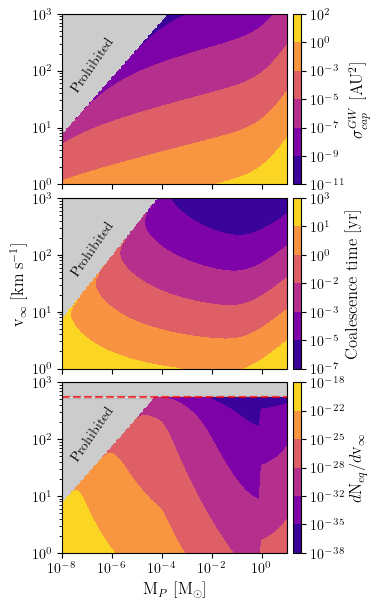

In [57]:
# m_pbh_values_in_Msun = m_pbh_values / const.M_sun.value
# n_eqs_perpbh = []
# n_eqs_grid = np.zeros_like(M_grid)
# for j in range(gridsize):
#     x_vals = []
#     y_vals = []
#     for i in range(gridsize):
#         # print(m, M_star, R_star, v)
#         v = v_inf_values[i]
#         lifetime = coal6[i, j]
#         term_rate = 1 / lifetime
#         v_km_s = (v * u.m / u.s).to(u.km / u.s).value
#         f = galactic_dm_maxwell_dist(v=v_km_s)
#         v_inf_auyr = (v * u.m / u.s).to(u.au / u.yr).value
#         rate =  f * cross_section_grid[i, j] * v_inf_auyr / term_rate
#         y_vals.append(rate)
#         x_vals.append(v)
#         n_eqs_grid[i, j] = rate
#     n_eq = integrate_gauss_legendre(x_vals, y_vals, n=100)
#     # print(f'Capture rate for mPBH = {m_pbh_values[j]}:', n_eq)
#     n_eqs_perpbh.append(n_eq)
n_eqs_grid = neq_grid
# Create 2x1 subplot with shared x-axis
fig, (ax1, ax3, ax2) = plt.subplots(3, 1, figsize=(3.5, 7), sharex=True)
vmin = float(cross_section_grid[cross_section_grid > 0].min())
vmax = float(cross_section_grid.max())
# ===== TOP PLOT: Cross-section grid =====
v_below_550 = np.array(v_inf_values_kms)[np.array(v_inf_values_kms) < 550]

ax1.fill_betweenx(np.array(v_inf_values_kms), 
                  np.min(m_pbh_values_in_Msun), 
                  1.0,
                  color='gray', alpha=0.4, zorder=0)
ax1.fill_betweenx(v_below_550, 
                  1.0, 
                  np.max(m_pbh_values_in_Msun),
                  color='cyan', alpha=0.4, zorder=0)

im1 = ax1.contourf(m_pbh_values_in_Msun, v_inf_values_kms, cross_section_grid,
                   cmap='plasma', norm=plt.cm.colors.LogNorm(), levels=np.logspace(np.log10(vmin), np.log10(vmax), 7), zorder=1)
ax1.set_yscale('log')
# ax1.set_ylabel(r'v$_{\infty}$ [km s$^{-1}$]')
ax1.text(0.03, 0.7, r'Prohibited', fontsize=10, ha='left', va='center', rotation=55,
         transform=ax1.transAxes)
cbar1 = plt.colorbar(im1, ax=ax1, pad=0.02, shrink=1, aspect=20)
cbar1.set_label(r'$\sigma_{cap}^{GW}$ [AU$^2$]')
cbar1.set_ticks(np.logspace(np.log10(vmin), np.log10(vmax), 7))
cbar1.set_ticklabels([f"{sci_notation_latex(x)}" for x in cbar1.get_ticks()])

# ===== BOTTOM PLOT: N_eq grid =====
n_eqs_grid = np.ma.masked_invalid(n_eqs_grid)
n_eqs_grid = np.ma.masked_less_equal(n_eqs_grid, 0.0)
vmin = float(n_eqs_grid.min())
vmax = float(n_eqs_grid.max())

v_above_550 = np.array(v_inf_values_kms)[np.array(v_inf_values_kms) >= 550]

ax2.fill_betweenx(v_below_550, 
                  np.min(m_pbh_values_in_Msun), 
                  1.0,
                  color='gray', alpha=0.4, zorder=0)
ax2.fill_betweenx(v_below_550, 
                  1.0, 
                  np.max(m_pbh_values_in_Msun),
                  color='cyan', alpha=0.4, zorder=0)
ax2.fill_between(m_pbh_values_in_Msun, v_above_550[0], np.max(v_inf_values_kms), 
                 alpha=0.4, color='gray', label='Prohibited Region', zorder=0)

im2 = ax2.contourf(m_pbh_values_in_Msun, v_inf_values_kms, n_eqs_grid, 
                   cmap='plasma', norm=LogNorm(vmin=vmin, vmax=vmax), 
                   levels=np.logspace(np.log10(vmin), np.log10(vmax), 7), zorder=1)
ax2.set_yscale('log')
ax2.set_xscale('log')
ax2.set_xlabel(r'M$_{P}$ [M$_{\odot}$]')
# ax2.set_ylabel(r'v$_{\infty}$ [km s$^{-1}$]')

ax2.hlines(550, np.min(m_pbh_values_in_Msun), np.max(m_pbh_values_in_Msun), 
           color='red', linestyle='--', alpha=0.7, linewidth=1.5)
ax2.text(0.03, 0.7, r'Prohibited', fontsize=10, ha='left', va='center', rotation=55,
         transform=ax2.transAxes)

cbar2 = plt.colorbar(im2, ax=ax2, pad=0.02, shrink=1, aspect=20)
cbar2.set_label(r'$d$N$_{eq}/d$v$_{\infty}$ ')
cbar2.set_ticks(np.logspace(np.log10(vmin), np.log10(vmax), 7))
cbar2.set_ticklabels([f"{sci_notation_latex(x)}" for x in cbar2.get_ticks()])

# Set log scale on top plot as well
ax1.set_xscale('log')

vmin = float(coal_plotv6[coal_plotv6 > 0].min())
vmax = float(coal_plotv6.max())
ax3.fill_betweenx(np.array(v_inf_values_kms), 
                  np.min(m_pbh_values_in_Msun), 
                  1.0,
                  color='gray', alpha=0.4, zorder=0)
im3 = ax3.contourf(
    m_pbh_values_in_Msun,
    v_inf_values_kms,
    coal_plotv6,
    levels=np.logspace(np.log10(vmin), np.log10(vmax), 7),
    cmap="plasma",
    norm=LogNorm(vmin=vmin, vmax=vmax),
)
ax3.text(0.03, 0.7, r'Prohibited', fontsize=10, ha='left', va='center', rotation=55,
         transform=ax3.transAxes)
ax3.set_ylabel(r'v$_{\infty}$ [km s$^{-1}$]')

cbar3 = plt.colorbar(im3, ax=ax3, pad=0.02, shrink=1, aspect=20)
cbar3.set_label(r'Coalescence time [yr]')
cbar3.set_ticks(np.logspace(np.log10(vmin), np.log10(vmax), 7))
cbar3.set_ticklabels([f"{sci_notation_latex(x)}" for x in cbar3.get_ticks()])

ax3.set_yscale('log')
ax3.set_xscale('log')


fig.subplots_adjust(hspace=0.08)
plt.savefig(directoryp + f'{star}_cross_section_neq_{r}kpc.png', bbox_inches='tight')
print(f"max n_eq: {n_eqs_grid.max()}")

/tmp/ipykernel_1973211/521947786.py:39: UserWarning: Log scale: values of z <= 0 have been masked
  im1 = ax1.contourf(m_pbh_values_in_Msun, v_inf_values_kms, cross_section_grid,


Formatting 3.02e-12 as 3.02 × 10^-12
Formatting 3.88e-10 as 3.88 × 10^-10
Formatting 4.99e-08 as 4.99 × 10^-8
Formatting 6.42e-06 as 6.42 × 10^-6
Formatting 8.25e-04 as 8.25 × 10^-4
Formatting 1.06e-01 as 1.06 × 10^-1
Formatting 1.37e+01 as 1.37 × 10^1
Formatting 5.48e-08 as 5.48 × 10^-8
Formatting 2.34e-06 as 2.34 × 10^-6
Formatting 1.00e-04 as 1.00 × 10^-4
Formatting 4.28e-03 as 4.28 × 10^-3
Formatting 1.83e-01 as 1.83 × 10^-1
Formatting 7.83e+00 as 7.83 × 10^0
Formatting 3.35e+02 as 3.35 × 10^2
max n_eq: 1.0216826379712665e-19


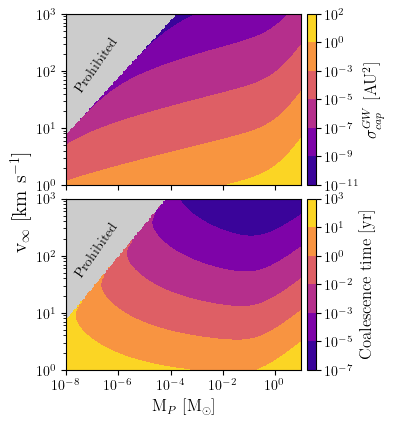

In [115]:
# m_pbh_values_in_Msun = m_pbh_values / const.M_sun.value
# n_eqs_perpbh = []
# n_eqs_grid = np.zeros_like(M_grid)
# for j in range(gridsize):
#     x_vals = []
#     y_vals = []
#     for i in range(gridsize):
#         # print(m, M_star, R_star, v)
#         v = v_inf_values[i]
#         lifetime = coal6[i, j]
#         term_rate = 1 / lifetime
#         v_km_s = (v * u.m / u.s).to(u.km / u.s).value
#         f = galactic_dm_maxwell_dist(v=v_km_s)
#         v_inf_auyr = (v * u.m / u.s).to(u.au / u.yr).value
#         rate =  f * cross_section_grid[i, j] * v_inf_auyr / term_rate
#         y_vals.append(rate)
#         x_vals.append(v)
#         n_eqs_grid[i, j] = rate
#     n_eq = integrate_gauss_legendre(x_vals, y_vals, n=100)
#     # print(f'Capture rate for mPBH = {m_pbh_values[j]}:', n_eq)
#     n_eqs_perpbh.append(n_eq)
n_eqs_grid = neq_grid
# Create 2x1 subplot with shared x-axis
fig, (ax1, ax3) = plt.subplots(2, 1, figsize=(3.5, 4), sharex=True)
vmin = float(cross_section_grid[cross_section_grid > 0].min())
vmax = float(cross_section_grid.max())
# ===== TOP PLOT: Cross-section grid =====
v_below_550 = np.array(v_inf_values_kms)[np.array(v_inf_values_kms) < 550]

ax1.fill_betweenx(np.array(v_inf_values_kms), 
                  np.min(m_pbh_values_in_Msun), 
                  1.0,
                  color='gray', alpha=0.4, zorder=0)
ax1.fill_betweenx(v_below_550, 
                  1.0, 
                  np.max(m_pbh_values_in_Msun),
                  color='cyan', alpha=0.4, zorder=0)

im1 = ax1.contourf(m_pbh_values_in_Msun, v_inf_values_kms, cross_section_grid,
                   cmap='plasma', norm=plt.cm.colors.LogNorm(), levels=np.logspace(np.log10(vmin), np.log10(vmax), 7), zorder=1)
ax1.set_yscale('log')
# ax1.set_ylabel(r'v$_{\infty}$ [km s$^{-1}$]')
ax1.text(0.03, 0.7, r'Prohibited', fontsize=10, ha='left', va='center', rotation=55,
         transform=ax1.transAxes)
cbar1 = plt.colorbar(im1, ax=ax1, pad=0.02, shrink=1, aspect=20)
cbar1.set_label(r'$\sigma_{cap}^{GW}$ [AU$^2$]')
cbar1.set_ticks(np.logspace(np.log10(vmin), np.log10(vmax), 7))
cbar1.set_ticklabels([f"{sci_notation_latex(x)}" for x in cbar1.get_ticks()])

# ===== BOTTOM PLOT: N_eq grid =====
n_eqs_grid = np.ma.masked_invalid(n_eqs_grid)
n_eqs_grid = np.ma.masked_less_equal(n_eqs_grid, 0.0)
vmin = float(n_eqs_grid.min())
vmax = float(n_eqs_grid.max())

v_above_550 = np.array(v_inf_values_kms)[np.array(v_inf_values_kms) >= 550]

# ax2.fill_betweenx(v_below_550, 
#                   np.min(m_pbh_values_in_Msun), 
#                   1.0,
#                   color='gray', alpha=0.4, zorder=0)
# ax2.fill_betweenx(v_below_550, 
#                   1.0, 
#                   np.max(m_pbh_values_in_Msun),
#                   color='cyan', alpha=0.4, zorder=0)
# ax2.fill_between(m_pbh_values_in_Msun, v_above_550[0], np.max(v_inf_values_kms), 
#                  alpha=0.4, color='gray', label='Prohibited Region', zorder=0)

# im2 = ax2.contourf(m_pbh_values_in_Msun, v_inf_values_kms, n_eqs_grid, 
#                    cmap='plasma', norm=LogNorm(vmin=vmin, vmax=vmax), 
#                    levels=np.logspace(np.log10(vmin), np.log10(vmax), 7), zorder=1)
# ax2.set_yscale('log')
# ax2.set_xscale('log')
# ax2.set_xlabel(r'M$_{P}$ [M$_{\odot}$]')
# # ax2.set_ylabel(r'v$_{\infty}$ [km s$^{-1}$]')

# ax2.hlines(550, np.min(m_pbh_values_in_Msun), np.max(m_pbh_values_in_Msun), 
#            color='red', linestyle='--', alpha=0.7, linewidth=1.5)
# ax2.text(0.03, 0.7, r'Prohibited', fontsize=10, ha='left', va='center', rotation=55,
#          transform=ax2.transAxes)

# cbar2 = plt.colorbar(im2, ax=ax2, pad=0.02, shrink=1, aspect=20)
# cbar2.set_label(r'$d$N$_{eq}/d$v$_{\infty}$ ')
# cbar2.set_ticks(np.logspace(np.log10(vmin), np.log10(vmax), 7))
# cbar2.set_ticklabels([f"{sci_notation_latex(x)}" for x in cbar2.get_ticks()])

# Set log scale on top plot as well
ax1.set_xscale('log')

vmin = float(coal_plotv6[coal_plotv6 > 0].min())
vmax = float(coal_plotv6.max())
ax3.fill_betweenx(np.array(v_inf_values_kms), 
                  np.min(m_pbh_values_in_Msun), 
                  1.0,
                  color='gray', alpha=0.4, zorder=0)
im3 = ax3.contourf(
    m_pbh_values_in_Msun,
    v_inf_values_kms,
    coal_plotv6,
    levels=np.logspace(np.log10(vmin), np.log10(vmax), 7),
    cmap="plasma",
    norm=LogNorm(vmin=vmin, vmax=vmax),
)
ax3.text(0.03, 0.7, r'Prohibited', fontsize=10, ha='left', va='center', rotation=55,
         transform=ax3.transAxes)
fig.supylabel(r'v$_{\infty}$ [km s$^{-1}$]')

cbar3 = plt.colorbar(im3, ax=ax3, pad=0.02, shrink=1, aspect=20)
cbar3.set_label(r'Coalescence time [yr]')
cbar3.set_ticks(np.logspace(np.log10(vmin), np.log10(vmax), 7))
cbar3.set_ticklabels([f"{sci_notation_latex(x)}" for x in cbar3.get_ticks()])
ax3.set_xlabel(r'M$_{P}$ [M$_{\odot}$]')

ax3.set_yscale('log')
ax3.set_xscale('log')


fig.subplots_adjust(hspace=0.08, left=0.18, right=0.99, top=0.97, bottom=0.08)
plt.savefig(directoryp + f'{star}_cross_section_coal_{r}kpc.png', bbox_inches='tight')
print(f"max n_eq: {n_eqs_grid.max()}")

Formatting 2.79e-39 as 2.79 × 10^-39
Formatting 5.09e-36 as 5.09 × 10^-36
Formatting 9.27e-33 as 9.27 × 10^-33
Formatting 1.69e-29 as 1.69 × 10^-29
Formatting 3.08e-26 as 3.08 × 10^-26
Formatting 5.61e-23 as 5.61 × 10^-23
Formatting 1.02e-19 as 1.02 × 10^-19
max n_eq: 1.0216826379712665e-19


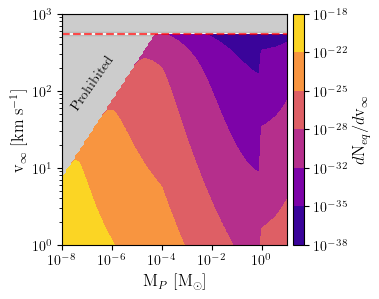

In [109]:
# m_pbh_values_in_Msun = m_pbh_values / const.M_sun.value
# n_eqs_perpbh = []
# n_eqs_grid = np.zeros_like(M_grid)
# for j in range(gridsize):
#     x_vals = []
#     y_vals = []
#     for i in range(gridsize):
#         # print(m, M_star, R_star, v)
#         v = v_inf_values[i]
#         lifetime = coal6[i, j]
#         term_rate = 1 / lifetime
#         v_km_s = (v * u.m / u.s).to(u.km / u.s).value
#         f = galactic_dm_maxwell_dist(v=v_km_s)
#         v_inf_auyr = (v * u.m / u.s).to(u.au / u.yr).value
#         rate =  f * cross_section_grid[i, j] * v_inf_auyr / term_rate
#         y_vals.append(rate)
#         x_vals.append(v)
#         n_eqs_grid[i, j] = rate
#     n_eq = integrate_gauss_legendre(x_vals, y_vals, n=100)
#     # print(f'Capture rate for mPBH = {m_pbh_values[j]}:', n_eq)
#     n_eqs_perpbh.append(n_eq)
n_eqs_grid = neq_grid
# Create 2x1 subplot with shared x-axis
fig, ax2 = plt.subplots(1, 1, figsize=(3.5, 3), sharex=True)
vmin = float(cross_section_grid[cross_section_grid > 0].min())
vmax = float(cross_section_grid.max())


# ===== BOTTOM PLOT: N_eq grid =====
n_eqs_grid = np.ma.masked_invalid(n_eqs_grid)
n_eqs_grid = np.ma.masked_less_equal(n_eqs_grid, 0.0)
vmin = float(n_eqs_grid.min())
vmax = float(n_eqs_grid.max())

v_above_550 = np.array(v_inf_values_kms)[np.array(v_inf_values_kms) >= 550]

ax2.fill_betweenx(v_below_550, 
                  np.min(m_pbh_values_in_Msun), 
                  1.0,
                  color='gray', alpha=0.4, zorder=0)
ax2.fill_betweenx(v_below_550, 
                  1.0, 
                  np.max(m_pbh_values_in_Msun),
                  color='cyan', alpha=0.4, zorder=0)
ax2.fill_between(m_pbh_values_in_Msun, v_above_550[0], np.max(v_inf_values_kms), 
                 alpha=0.4, color='gray', label='Prohibited Region', zorder=0)

im2 = ax2.contourf(m_pbh_values_in_Msun, v_inf_values_kms, n_eqs_grid, 
                   cmap='plasma', norm=LogNorm(vmin=vmin, vmax=vmax), 
                   levels=np.logspace(np.log10(vmin), np.log10(vmax), 7), zorder=1)
ax2.set_yscale('log')
ax2.set_xscale('log')
ax2.set_xlabel(r'M$_{P}$ [M$_{\odot}$]')
# ax2.set_ylabel(r'v$_{\infty}$ [km s$^{-1}$]')

ax2.hlines(550, np.min(m_pbh_values_in_Msun), np.max(m_pbh_values_in_Msun), 
           color='red', linestyle='--', alpha=0.7, linewidth=1.5)
ax2.text(0.03, 0.7, r'Prohibited', fontsize=10, ha='left', va='center', rotation=55,
         transform=ax2.transAxes)

cbar2 = plt.colorbar(im2, ax=ax2, pad=0.02, shrink=1, aspect=20)
cbar2.set_label(r'$d$N$_{eq}/d$v$_{\infty}$ ')
cbar2.set_ticks(np.logspace(np.log10(vmin), np.log10(vmax), 7))
cbar2.set_ticklabels([f"{sci_notation_latex(x)}" for x in cbar2.get_ticks()])
ax2.set_ylabel(r'v$_{\infty}$ [km s$^{-1}$]')



fig.subplots_adjust(hspace=0.08)
plt.savefig(directoryp + f'{star}_neq_{r}kpc.png', bbox_inches='tight')
print(f"max n_eq: {n_eqs_grid.max()}")

In [16]:
print(M_star/const.M_sun.value)

1.4


7.924955427940242e-18 max neq for 0.1 kpc
1.0216826379712665e-19 for 8 kpc

In [40]:
from src.utils import calculations_v3 as calc
r_edges_inner = np.linspace(0.001, 0.5, 80)
r_edges_outer = np.linspace(0.5, 8.0, 80)
r_edges = np.unique(np.concatenate([r_edges_inner, r_edges_outer]))
r_edges = np.asarray(r_edges)

r_centers = 0.5 * (r_edges[:-1] + r_edges[1:])
dr_array = np.diff(r_edges)
M_star = 1.4
fraction = 0.0026
all_results = {}
integrated_results = {}
for i, r_mid in enumerate(r_centers):
    r_dict = {}
    r_in = r_edges[i]
    r_out = r_edges[i + 1]
    dr_i = dr_array[i]

    

    N_eq_full = []
    Neq_pbh_bound = []
    n_pbh_density = []
    r = r_mid  # kpc, for galactic DM distribution
    for j in range(gridsize):
        x_vals = []
        y_vals = []
        for i in range(gridsize):
            # print(m, M_star, R_star, v)
            v = v_inf_values[i]
            lifetime = coal6[i, j]
            term_rate = 1 / lifetime
            v_km_s = (v * u.m / u.s).to(u.km / u.s).value
            f = galactic_dm_maxwell_dist(v=v_km_s, r=r)
            v_inf_auyr = (v * u.m / u.s).to(u.au / u.yr).value
            rate =  f * cross_section_grid[i, j] * v_inf_auyr / term_rate
            y_vals.append(rate)
            x_vals.append(v)
            
        n_eq = integrate_gauss_legendre(x_vals, y_vals, n=100)
        neq_rf = neq_r_f(m_pbh_values[j], n_eq, rf=r)
        # print(f'Capture rate for mPBH = {m_pbh_values[j]}:', n_eq)
        N_eq_full.append(neq_rf['Neq_pbh_f_full'])
        Neq_pbh_bound.append(neq_rf['Neq_pbh_f_bound'])
        n_pbh_density.append(neq_rf['number_density_in_range_kpc3'])


    # torus_volume_at_r = 2 * np.pi * r * np.pi * dr**2  # Volume of the cylindrical shell at radius r
    N_stars_at_r = calc.star_number_at_r(r_mid, dr_i, M_star=M_star)
    N_alike_systems_at_r = calc.star_number_at_r(r_mid, dr_i, M_star=M_star, fraction=fraction)

    N_eq_full_stars = np.asarray(N_eq_full) * (N_stars_at_r)  # Convert to number density by dividing by dr
    Neq_pbh_bound_stars = np.asarray(Neq_pbh_bound) * (N_stars_at_r)

    N_eq_full_alike = np.asarray(N_eq_full) * (N_alike_systems_at_r)
    Neq_pbh_bound_alike = np.asarray(Neq_pbh_bound) * (N_alike_systems_at_r)

    r_dict['n_pbh_density'] = n_pbh_density
    r_dict['N_eq_full'] = N_eq_full
    r_dict['N_eq_pbh_bound'] = Neq_pbh_bound
    r_dict['N_stars_at_r'] = N_stars_at_r
    r_dict['N_alike_systems_at_r'] = N_alike_systems_at_r
    r_dict['N_eq_full_stars'] = N_eq_full_stars
    r_dict['N_eq_pbh_bound_stars'] = Neq_pbh_bound_stars
    r_dict['N_eq_full_alike'] = N_eq_full_alike
    r_dict['N_eq_pbh_bound_alike'] = Neq_pbh_bound_alike

    all_results[r_mid] = r_dict
    
integrated_results = {}
# Now integrate N_eq over radius
# Instead of looping through all_results multiple times:
# Pre-extract the arrays you need
for i in range(len(m_pbh_values_in_Msun)):
    integrated_results[i] = {}
    N_stars_total_array = np.array([all_results[r]['N_stars_at_r'] for r in r_centers])
    N_eq_full_stars_array = np.array([all_results[r]['N_eq_full_stars'][i] for r in r_centers])
    Neq_pbh_bound_stars_array = np.array([all_results[r]['N_eq_pbh_bound_stars'][i] for r in r_centers])
    N_eq_full_alike_array = np.array([all_results[r]['N_eq_full_alike'][i] for r in r_centers])
    Neq_pbh_bound_alike_array = np.array([all_results[r]['N_eq_pbh_bound_alike'][i] for r in r_centers])

    # Then integrate once
    # N_eq_full_stars_integrated = calc.integrate_gauss_legendre(r_array, N_eq_full_stars_array)
    # Neq_pbh_bound_stars_integrated = calc.integrate_gauss_legendre(r_array, Neq_pbh_bound_stars_array)
    # N_eq_full_alike_integrated = calc.integrate_gauss_legendre(r_array, N_eq_full_alike_array)
    # Neq_pbh_bound_alike_integrated = calc.integrate_gauss_legendre(r_array, Neq_pbh_bound_alike_array)
    N_eq_full_stars_integrated = np.sum(N_eq_full_stars_array)
    Neq_pbh_bound_stars_integrated = np.sum(Neq_pbh_bound_stars_array)
    N_eq_full_alike_integrated = np.sum(N_eq_full_alike_array)
    Neq_pbh_bound_alike_integrated = np.sum(Neq_pbh_bound_alike_array)
    N_stars_total_integrated = np.sum(N_stars_total_array)

    integrated_results[i]['N_eq_full_stars_integrated'] = N_eq_full_stars_integrated
    integrated_results[i]['Neq_pbh_bound_stars_integrated'] = Neq_pbh_bound_stars_integrated
    integrated_results[i]['N_eq_full_alike_integrated'] = N_eq_full_alike_integrated
    integrated_results[i]['Neq_pbh_bound_alike_integrated'] = Neq_pbh_bound_alike_integrated
    integrated_results[i]['N_stars_total_integrated'] =  N_stars_total_integrated

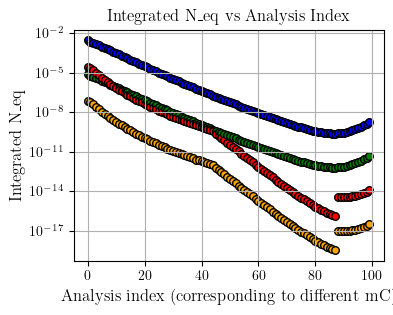

0.003013400154273408
7.834840401110862e-06
31617075794.898815


In [41]:
plt.figure(figsize=(4, 3))
msize = 30
for res in range(len(integrated_results)):
    plt.scatter(res, integrated_results[res]['N_eq_full_stars_integrated'], label=f"N_eq full stars", c='blue', marker='o', edgecolor='black', s=msize)
    plt.scatter(res, integrated_results[res]['N_eq_full_alike_integrated'], label=f"N_eq full alike", c='green', marker='o', edgecolor='black', s=msize)
    plt.scatter(res, integrated_results[res]['Neq_pbh_bound_stars_integrated'], label=f"N_eq pbh bound stars", c='red', marker='o', edgecolor='black', s=msize)
    plt.scatter(res, integrated_results[res]['Neq_pbh_bound_alike_integrated'], label=f"N_eq pbh bound alike", c='orange', marker='o', edgecolor='black', s=msize)


plt.xlabel('Analysis index (corresponding to different mC)')
plt.ylabel('Integrated N_eq')
plt.title('Integrated N_eq vs Analysis Index')
plt.yscale('log')
plt.grid()
plt.show()
print( integrated_results[0]["N_eq_full_stars_integrated"])
print( integrated_results[0]['N_eq_full_alike_integrated'])
print( integrated_results[0]['N_stars_total_integrated'])

In [67]:
print(np.max([integrated_results[i]['N_eq_full_stars_integrated'] for i in range(len(integrated_results))]))
print(np.max([r['N_eq_full'] for r in all_results.values()]))
print(np.max([r['N_eq_pbh_bound'] for r in all_results.values()]))
print([r['N_eq_full'] for r in all_results.values()])
print([r['N_eq_pbh_bound'] for r in all_results.values()])
print([integrated_results[i]['N_eq_full_stars_integrated'] for i in range(len(integrated_results))])
print( integrated_results[0]["N_eq_full_stars_integrated"]/integrated_results[0]['N_stars_total_integrated'])

0.003013400154273408
7.930555848633954e-11
7.700611554324e-13
[[np.float64(7.930555848633954e-11), np.float64(6.371719630071954e-11), np.float64(5.1207894007027975e-11), np.float64(4.094679201980343e-11), np.float64(3.275156819727255e-11), np.float64(2.6093438935995367e-11), np.float64(2.079335220947327e-11), np.float64(1.6520489550974168e-11), np.float64(1.3127527612453527e-11), np.float64(1.0409369571588411e-11), np.float64(8.255973546617385e-12), np.float64(6.531717194072866e-12), np.float64(5.17658309631561e-12), np.float64(4.0946691799450605e-12), np.float64(3.2433729316576906e-12), np.float64(2.5670937566072754e-12), np.float64(2.0319636687117385e-12), np.float64(1.6099960384111943e-12), np.float64(1.277377980731941e-12), np.float64(1.0137042357221536e-12), np.float64(8.05366914807978e-13), np.float64(6.404882489341931e-13), np.float64(5.100703848524231e-13), np.float64(4.064699451276263e-13), np.float64(3.2451327882528535e-13), np.float64(2.5952802814892167e-13), np.float64(2.07

First dr: 0.0263 kpc, Second dr: 0.3947 kpc
dN/dr first interval: [0.0080198  0.00473456 0.00366864 0.00309166 0.00271627], dN/dr second interval: [0.00101272 0.00074214 0.000567   0.00044035 0.00034516]
Integrated dN/dr for mC=1.00e-08 Msun: 2.87e-03
First dr: 0.0263 kpc, Second dr: 0.3947 kpc
dN/dr first interval: [0.00645107 0.00380963 0.00295214 0.00248791 0.00218587], dN/dr second interval: [0.000815   0.00059725 0.00045631 0.00035438 0.00027777]
Integrated dN/dr for mC=1.23e-08 Msun: 2.31e-03
First dr: 0.0263 kpc, Second dr: 0.3947 kpc
dN/dr first interval: [0.00519285 0.00306787 0.00237755 0.00200376 0.00176053], dN/dr second interval: [0.00065646 0.00048107 0.00036754 0.00028544 0.00022374]
Integrated dN/dr for mC=1.52e-08 Msun: 1.86e-03
First dr: 0.0263 kpc, Second dr: 0.3947 kpc
dN/dr first interval: [0.00415852 0.00245778 0.0019049  0.00160548 0.00141062], dN/dr second interval: [0.00052601 0.00038548 0.00029451 0.00022873 0.00017928]
Integrated dN/dr for mC=1.87e-08 Msun: 1

/tmp/ipykernel_1973211/3337007347.py:23: UserWarning: The following kwargs were not used by contour: 'shading'
  im = ax.contourf(r_array, m_pbh_values_in_Msun, N_dr_grid, levels=10, cmap=cmap, shading='auto', norm=LogNorm())


(0.05, 8)

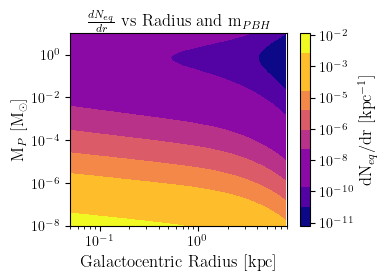

In [ ]:
import src.utils.plotting_utils as plu

fig, ax = plt.subplots(1, 1, figsize=(3.5, 2.5), sharex=True)
r_array = np.array(list(all_results.keys()))
R_grid, M_grid = np.meshgrid(r_array, m_pbh_values_in_Msun)
N_dr_grid = np.zeros_like(R_grid)
for j, mC in enumerate(m_pbh_values_in_Msun):
    neq_full_at_r_first = [all_results[r]['N_eq_full_stars'][j] for r in r_array if r <= 0.5]
    neq_full_at_r_second = [all_results[r]['N_eq_full_stars'][j] for r in r_array if r >= 0.5]
    first_dr = r_array[r_array < 0.5][2] - r_array[r_array < 0.5][1]
    second_dr = r_array[r_array >= 0.5][2] - r_array[r_array >= 0.5][1]
    print(f"First dr: {first_dr:.4f} kpc, Second dr: {second_dr:.4f} kpc")
    dndr_first = (neq_full_at_r_first) / first_dr
    dndr_second = (neq_full_at_r_second) / second_dr
    print(f"dN/dr first interval: {dndr_first[:5]}, dN/dr second interval: {dndr_second[:5]}")
    dndr_combined = np.concatenate([dndr_first, dndr_second])
    # N_dr_interpolated = np.interp(r_array, dndr_combined, len(r_array))
    N_dr_grid[j, :] = dndr_combined
    gl_result = calc.integrate_gauss_legendre(r_array, dndr_combined)
    print(f"Integrated dN/dr for mC={mC:.2e} Msun: {gl_result:.2e}")

im = ax.contourf(r_array, m_pbh_values_in_Msun, N_dr_grid, levels=10, cmap=cmap, shading='auto', norm=LogNorm())
ax.set_yscale('log')
ax.set_xscale('log')
ax.set_xlabel('Galactocentric Radius [kpc]')
ax.set_ylabel(r'M$_{P}$ [M$_{\odot}$]')
cbar = plt.colorbar(im, label=r'dN$_{eq}$/dr [kpc$^{-1}$]')
cbar.set_ticks(np.logspace(np.log10(N_dr_grid.min()), np.log10(N_dr_grid.max()), 7))
cbar.set_ticklabels([f"{sci_notation_latex(x)}" for x in cbar.get_ticks()])
plt.title(r'$\frac{dN_{eq}}{dr}$ vs Radius and m$_{PBH}$')
plt.savefig(directoryp + f'{star}_dNdr_grid.png', bbox_inches='tight')
# turn off the x axis labels for the top plot
# ax[0].set_ylabel(r'N$_{eq}$(r$_i$)/$\Delta$r [kpc$^{-1}$]')
ax.set_yscale('log')
ax.set_xscale('log')
ax.set_xlim(0.05, 8)


/tmp/ipykernel_2257284/268903293.py:12: UserWarning: Log scale: values of z <= 0 have been masked
  plt.contourf(m_pbh_values_in_Msun, v_inf_values_kms, cross_section_grid,


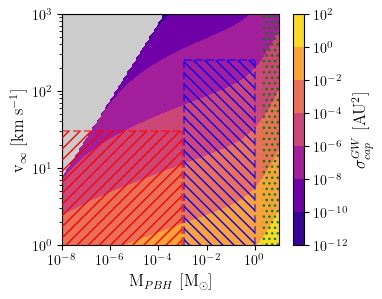

In [139]:
plt.figure(figsize=(3.5, 3))

# Fill background in red between min PBH mass and 1 solar mass
plt.fill_betweenx(v_inf_values_kms, 
                  np.min(m_pbh_values_in_Msun), 
                  1.0,  # 1 solar mass
                  color='gray', alpha=0.4, zorder=0)
plt.fill_betweenx(v_inf_values_kms, 
                  1.0, 
                  np.max(m_pbh_values_in_Msun),  # 1 solar mass
                  color='cyan', alpha=0.4, zorder=0)
plt.contourf(m_pbh_values_in_Msun, v_inf_values_kms, cross_section_grid,
             cmap='plasma', norm=plt.cm.colors.LogNorm())

# ✅ Set log scale AFTER plotting with linear values
plt.yscale('log')
plt.xscale('log')

cbar = plt.colorbar()
cbar.set_label(r'$\sigma_{cap}^{GW}$ [AU$^2$]')

plt.vlines(1e-3, 1, 30, color='red', linestyle='--', alpha=0.5)
plt.hlines(30, np.min(m_pbh_values_in_Msun), 1e-3, 
           color='red', linestyle='--', alpha=0.5)

plt.vlines(1.2e-3, 1, 255, color='blue', linestyle='--', alpha=0.5)
plt.vlines(1e0, 1, 255, color='blue', linestyle='--', alpha=0.5)
plt.hlines(255, 1.2e-3, 1e0, 
           color='blue', linestyle='--', alpha=0.5)
# plt.hlines(10, 2, 1e1  , 
#            color='green', linestyle=':', alpha=0.5)
#            # --- Hatched fills ---

# 1) Red boxed region: x in [xmin, 1e-3], y in [1, 30]
x_min = np.min(m_pbh_values_in_Msun)
x_red = np.logspace(np.log10(x_min), np.log10(1e-3), 200)   # good on log-x
plt.fill_between(
    x_red, 1, 30,
    facecolor='none', hatch='///', edgecolor='red',
    linewidth=0.0, zorder=3
)
x_green = np.logspace(np.log10(2), np.log10(1e1), 200)
plt.fill_between(
    x_green, 1, 1000,
    facecolor='none', hatch='...', edgecolor='green',
    linewidth=0.0, zorder=3
)

# 2) Blue boxed region: x in [1.2e-3, 1], y in [1, 255]
plt.fill_betweenx(
    [1, 255], 1.2e-3, 1.0,
    facecolor='none', hatch='\\\\\\', edgecolor='blue',
    linewidth=0.0, zorder=3
)
# Add labels to contour lines
plt.clabel(contour, inline=True, fontsize=8, fmt=lambda x: fr"{x:.1f} AU")

plt.xlabel(r'M$_{PBH}$ [M$_{\odot}$]')  # ✅ Remove log10 from label
plt.ylabel(r'v$_{\infty}$ [km s$^{-1}$]')  # ✅ Add space in unit
# plt.text(0.2, 0.6, r'Prohibited', fontsize=10, ha='center', va='center', 
#          transform=plt.gca().transAxes)
plt.xticks((1e-8, 1e-6, 1e-4, 1e-2, 1))
# ✅ Remove manual yticks - log scale handles this automatically
plt.savefig(directoryp + f'{star}_capture_cross_section_plus_semaj_grid.png', 
            bbox_inches='tight')

In [29]:
plt.figure(figsize=(3.5, 3))
semimajor_axis_values = 
# Fill background in red between min PBH mass and 1 solar mass
plt.fill_betweenx(v_inf_values_kms, 
                  np.min(m_pbh_values_in_Msun), 
                  1.0,  # 1 solar mass
                  color='gray', alpha=0.4, zorder=0)
plt.fill_betweenx(v_inf_values_kms, 
                  1.0, 
                  np.max(m_pbh_values_in_Msun),  # 1 solar mass
                  color='cyan', alpha=0.4, zorder=0)
plt.contourf(m_pbh_values_in_Msun, semaj_grid, cross_section_grid,
             cmap='plasma', norm=plt.cm.colors.LogNorm())

# ✅ Set log scale AFTER plotting with linear values
plt.yscale('log')
plt.xscale('log')

cbar = plt.colorbar()
cbar.set_label(r'$\sigma_{cap}^{GW}$ [AU$^2$]')

plt.vlines(1e-3, 1, 30, color='red', linestyle='--', alpha=0.5)
plt.hlines(30, np.min(m_pbh_values_in_Msun), 1e-3, 
           color='red', linestyle='--', alpha=0.5)

plt.vlines(1.2e-3, 1, 255, color='blue', linestyle='--', alpha=0.5)
plt.vlines(1e0, 1, 255, color='blue', linestyle='--', alpha=0.5)
plt.hlines(255, 1.2e-3, 1e0, 
           color='blue', linestyle='--', alpha=0.5)
# Add labels to contour lines
plt.clabel(contour, inline=True, fontsize=8, fmt=lambda x: fr"{x:.1f} AU")

plt.xlabel(r'M$_{PBH}$ [M$_{\odot}$]')  # ✅ Remove log10 from label
plt.ylabel(r'v$_{\infty}$ [km s$^{-1}$]')  # ✅ Add space in unit
# plt.text(0.2, 0.6, r'Prohibited', fontsize=10, ha='center', va='center', 
#          transform=plt.gca().transAxes)
plt.xticks((1e-8, 1e-6, 1e-4, 1e-2, 1))
# ✅ Remove manual yticks - log scale handles this automatically
plt.savefig(directoryp + f'{star}_capture_cross_section_plus_semaj_grid.png', 
            bbox_inches='tight')

SyntaxError: invalid syntax (653682803.py, line 2)

In [ ]:

mass_data = m_pbh_values_in_Msun.repeat(gridsize)  # Repeat each mass for all velocities
semaj_data = semaj_grid.flatten()  # Flatten semimajor axis grid
cross_sec_data = cross_section_grid.flatten()  # Flatten cross-section grid
eccentricity_data = eccentricity_grid.flatten()  # Flatten eccentricity grid
orbital_period_data = orbital_period_grid.flatten()  # Flatten orbital period grid
# Filter out zero cross-sections (no capture)
valid_mask = cross_sec_data > 0
mass_filtered = mass_data[valid_mask]
semaj_filtered = semaj_data[valid_mask]
eccentricity_filtered = eccentricity_data[valid_mask]
orbital_period_filtered = orbital_period_data[valid_mask]
mask_a200 = semaj_filtered < 200
# Structure data for the histogram function
# Single row plot: semimajor axis vs mass
voxel_2dhistogram(
    metric_list=[semaj_filtered, eccentricity_filtered],  # Y-axis: semimajor axis and eccentricity
    metric_ylabels=[r'a [AU]', r'e'],
    voxel_list=[mass_filtered, mass_filtered],  # X-axis: PBH mass
    voxel_xlabel=r'M$_{PBH}$ [M$_{\odot}$]',
    scale=['log', 'linear', 'log'],  # log-log scale with log colorbar
    voxel_bins=5,
    metric_bins=5,
    masks=[mask_a200, mask_a200],  # Apply mask to filter semimajor axes < 200 AU
    normalize=len(valid_mask),  # Normalize by total count for percentage
    annotate_bins=True,
    annotation_norm=np.sum(valid_mask),  # Normalize annotations to percentage
    metric_ranges=[(0, 200), (0.6, 1.6)],  # Set y-axis range for semimajor axis and eccentricity
    voxel_range=(1e-11, 10),  # Set x-axis range for mass
    save=True,
    metric_ticks=[(50, 100, 150, 200), (0.8, 1.0, 1.2, 1.4)],  # Set y-axis ticks for semimajor axis and eccentricity
    voxel_ticks=(1e-8, 1e-6, 1e-4, 1e-2, 1),  # Set x-axis ticks for mass
    save_as=f'{star}_mass_vs_semaj_e_histogram.png',
    fig_size=(3.5, 3)
)

print(f"Total systems with capture: {len(mass_filtered)}")
print(f"Mass range: {mass_filtered.min():.2e} to {mass_filtered.max():.2e}")
print(f"Semaj range: {semaj_filtered.min():.2e} to {semaj_filtered.max():.2e} AU")
print(f"Eccentricity range: {eccentricity_filtered.min():.2e} to {eccentricity_filtered.max():.2e}")
print(f"Orbital period range: {orbital_period_filtered.min():.2e} to {orbital_period_filtered.max():.2e} years")

In [ ]:
voxel_2dhistogram(
    metric_list=[semaj_filtered, orbital_period_filtered],  # Y-axis: semimajor axis and eccentricity
    metric_ylabels=[r'a [AU]', r'P [Myr]'],
    voxel_list=[mass_filtered, mass_filtered],  # X-axis: PBH mass
    voxel_xlabel=r'M$_{PBH}$ [M$_{\odot}$]',
    metric_scale=['linear', 'log', 'log'],  # log-log scale with log colorbar
    voxel_scale='log',
    voxel_bins=10,
    metric_bins=5,
    masks=[mask_a200, mask_a200],  # Apply mask to filter semimajor axes < 200 AU
    normalize=len(valid_mask),  # Normalize by total count for percentage
    annotate_bins=True,
    metric_unit_change=[1, 1e-6],  # No unit change for semimajor axis and orbital period
    annotation_norm=np.sum(valid_mask),  # Normalize annotations to percentage
    metric_ranges=[(0, 200), (1e-11,1e0)],  # Set y-axis range for semimajor axis and eccentricity
    voxel_range=(1e-8, 1),  # Set x-axis range for mass
    save=True,
    metric_ticks=[(50, 100, 150, 200), (1e-11, 1e-7, 1e-3, 1)],  # Set y-axis ticks for semimajor axis and eccentricity
    voxel_ticks=(1e-8, 1e-6, 1e-4, 1e-2, 1),  # Set x-axis ticks for mass
    save_as=f'{star}_mass_vs_semaj_e_histogram.png',
    fig_size=(3.5, 4)
)

In [ ]:
print(((np.min(orbital_period_filtered)*u.yr).to(u.s), np.max(orbital_period_filtered)))


In [ ]:
print(np.sum(valid_mask), "systems with non-zero capture cross-section")
print(len(valid_mask))
print(f"percentage with capture: {(np.sum(valid_mask) / len(valid_mask)) * 100:.2f}%")

In [30]:

def plot_kde(metrics_x, metrics_y, metric_xname, metric_yname, percentage_annotations=False, thresh=0.1, levels=10, bw_adjust=0.6, alpha=[1,1,1], cmaps=None, fig_size=(3.5, 3), fill=[True,True,True], unit_change=(1, 1), reverse_axes=None, scale=('linear', 'linear'), ticks=None, ranges=None,  cut=3.0, save=False, save_as=None):
        
    fig, axs = plt.subplots(1, 1, figsize=fig_size)
    if cmaps is None:
        ccs = ['Purples', 'Oranges', 'Blues', 'Reds']
    else:
        ccs = cmaps
    i=0
    for metric_x, metric_y, cc in zip(metrics_x, metrics_y, ccs):
        def process_metric(m, unit_factor):
            if isinstance(m, (list, tuple)):
                if len(m) > 2:
                    m = m[1:-1]
                if len(m) == 0:
                    return []
                return [float(mm * unit_factor) for mm in m if np.size(mm) > 0]
            elif isinstance(m, np.ndarray) and m.ndim > 0:
                return (m.flatten() * unit_factor).tolist()
            else:
                return [float(m * unit_factor)]
        
        data_x = process_metric(metric_x, unit_change[0])
        data_y = process_metric(metric_y, unit_change[1])
        print(f"Original data points in x: {len(data_x)}")
        print(f"Original data points in y: {len(data_y)}")
        x_array = np.array(data_x)
        y_array = np.array(data_y)

        # Filter invalid
        valid_mask = np.isfinite(x_array) & np.isfinite(y_array)
        x_array = x_array[valid_mask]
        y_array = y_array[valid_mask]
        
        print(f"{len(x_array)} valid points in x")
        print(f"{len(y_array)} valid points in y")
        
        if reverse_axes: 
            # Reverse x-axis if it is plotted on top x axis
            x_array = -x_array if reverse_axes[i][0] else x_array
            y_array = -y_array if reverse_axes[i][1] else y_array
            print(f"  Reversed axes: x reversed={reverse_axes[i][0]}, y reversed={reverse_axes[i][1]}")

        # Check variances, if zero, add a small jitter to avoid KDE failure
        if np.var(x_array) == 0:
            print("  Warning: Zero variance in x data. Adding jitter to avoid KDE failure.")
            x_array += np.random.normal(0,  np.ptp(x_array), size=x_array.shape)
            x_array = np.array(x_array)
        if np.var(y_array) == 0:
            print("  Warning: Zero variance in y data. Adding jitter to avoid KDE failure.")
            y_array = [y + np.random.normal(0,  1e-3) for y in y_array]
            print(f"  Added jitter to y data: new variance = {np.var(y_array):.2e}")
            y_array = np.array(y_array)

        if ranges is not None:
            x_mask = np.ones_like(x_array, dtype=bool)
            y_mask = np.ones_like(y_array, dtype=bool)  
            if ranges[0] is not None:
                x_rng = (ranges[0][0]*unit_change[0], ranges[0][1]*unit_change[0])
                axs.set_xlim(x_rng)
                x_mask = (x_array >= x_rng[0]) & (x_array <= x_rng[1])
            if ranges[1] is not None:
                y_rng = (ranges[1][0]*unit_change[1], ranges[1][1]*unit_change[1])
                axs.set_ylim(y_rng)
                y_mask = (y_array >= y_rng[0]) & (y_array <= y_rng[1])

            x_array = x_array[x_mask & y_mask]
            y_array = y_array[y_mask & x_mask]

        df = pd.DataFrame({metric_xname: x_array, metric_yname: y_array})
        within_percentage = np.sum([x_mask & y_mask]) / len(x_mask) * 100 if ranges is not None and ranges[0] is not None else 100
        # ============ GAUSSIAN KDE ============
        # KDE parameters
        kde_kw = dict(
            fill=fill[i],
            levels=levels,
            thresh=thresh,
            bw_adjust=bw_adjust,
            common_norm=False,
            cut=cut,
            label=None,
            alpha=alpha[i],
        )
        
        sns.kdeplot(x=metric_xname, y=metric_yname, data=df, ax=axs, cmap=cc, **kde_kw)
            
        axs.set_ylabel(f'', fontsize=9)
        axs.set_xlabel(f'', fontsize=9)
        kde = gaussian_kde(np.vstack([x_array, y_array]), bw_method='scott')
        kde.set_bandwidth(kde.factor * kde_kw['bw_adjust'])  # ← Match your bw_adjust=0.7
        density = kde(np.vstack([x_array, y_array]))
        threshold = kde_kw['thresh'] * density.max()
        print(f"  {np.sum(density < threshold)} outliers detected")
        mask_outliers = density < threshold

        if percentage_annotations:
            axs.annotate(f'{np.round(within_percentage, 0):.0f}\\%', xy=(0.8, 0.2+0.2*i), xycoords='axes fraction', ha='right', va='bottom', fontsize=9, color=plt.get_cmap(cc)(0.9))
    
        axs.scatter(x_array[mask_outliers], y_array[mask_outliers], color=plt.get_cmap(cc)(0.9), s=2, edgecolor=plt.get_cmap(cc)(0.9), linewidth=0.5, zorder=10, alpha=0.8)
        i += 1
    # ============ FORMATTING ============

    if scale[1] == 'log':
        axs.set_yscale('log')
    if scale[0] == 'log':
        axs.set_xscale('log')

    if ticks:
        axs.set_xticks(ticks[0] if ticks and ticks[0] else None)
        axs.set_yticks(ticks[1] if ticks and ticks[1] else None)

    axs.set_xlabel(f'{metric_xname}')
    axs.set_ylabel(f'{metric_yname}')

    if save:
        if save_as is not None:
            figname = save_as
        else:
            figname = f'compas_{metric_xname}_{metric_yname}_gaussian_kde.png'
        out = os.path.join(pathToPlots, figname)
        fig.savefig(out, dpi=500, bbox_inches='tight')
    

In [31]:
unvalid_mask = cross_sec_data == 0
mass_filtered_unbound = mass_data[unvalid_mask]
semaj_filtered_unbound = semaj_data[unvalid_mask]
plot_kde(
    metrics_y=[mass_filtered_unbound, mass_filtered],  # Mass data for all and valid points
    metrics_x=[semaj_filtered_unbound, semaj_filtered],  # Semimajor axis for all and valid points
    metric_yname=r'M$_{PBH}$ [M$_{\odot}$]',
    metric_xname=r'Semi-major axis [AU]',
    percentage_annotations=True,
    thresh=0.01,
    levels=10,
    bw_adjust=0.6,
    alpha=[0.7, 0.3],
    # cmaps=['Purples', 'Oranges'],
    fig_size=(3.5, 3),
    fill=[False, False],
    unit_change=(1, 1),
    reverse_axes=[[True, False], [False, False]],
    scale=['linear', 'log'],
    ticks=None,
    ranges=[(-1, 200), (1e-8, 10)],
    cut=3.0,
    save=True,
    save_as=f'{star}_mass_vs_semaj_kde.png'
)

NameError: name 'cross_sec_data' is not defined